# 📊 EV Advanced Statistical Analysis & Visualization

## Notebook Overview

This notebook performs a **deep statistical analysis** of the cleaned EV dataset.

### Statistical workflow

```text
Cleaned EV Dataset
        ↓
Statistical Profiling
        ↓
01. Descriptive Statistics
        ↓
02. Distribution Analysis
        ↓
03. Dispersion & Variability
        ↓
04. Relationship / Association Analysis
        ↓
05. Inferential Statistics
        ↓
06. Hypothesis Testing
        ↓
07. Non-Parametric Statistics
        ↓
08. Confidence Intervals
        ↓
09. Effect Size
        ↓
10. Bootstrap Analysis
        ↓
11. Statistical Visualization
        ↓
12. Business Interpretation
```

> **Important:** Statistical tests are selected according to the actual column types and available data. No test is performed blindly.


# 1. Statistical Concepts Used

## Descriptive Statistics
Describes what is already present in the dataset.

Examples:
- Mean
- Median
- Mode
- Minimum / Maximum
- Range
- Quartiles
- Percentiles
- Variance
- Standard deviation
- IQR
- Skewness
- Kurtosis
- Coefficient of variation

## Inferential Statistics
Uses a sample to make conclusions about a wider population.

Examples:
- Confidence intervals
- t-tests
- ANOVA
- Chi-square
- Correlation significance
- Mann–Whitney U
- Kruskal–Wallis

## Effect Size
A p-value tells us whether evidence of a difference/relationship exists. Effect size helps determine **how large or practically meaningful** it is.

## Statistical Visualization
Charts are used to inspect distributions, differences, relationships and assumptions before interpreting statistical tests.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    ttest_1samp, ttest_ind, f_oneway, chi2_contingency,
    pearsonr, spearmanr, mannwhitneyu, kruskal,
    levene, shapiro
)

from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

print("✅ Statistical analysis libraries imported.")


✅ Statistical analysis libraries imported.


# 2. Load Cleaned Dataset

The notebook starts from the **cleaned and renamed dataset** produced in the previous notebook.

Expected location:

`datas/cleaned/ev_cleaned.csv`


In [2]:
from pathlib import Path

file_path = Path("../datas/processed/EV_Analytical_Feature_Engineered.csv")

if not file_path.exists():
    file_path = Path("datas/processed/EV_Analytical_Feature_Engineered.csv")

if not file_path.exists():
    raise FileNotFoundError(
        "Cleaned dataset not found. Expected: datas/processed/EV_Analytical_Feature_Engineered.csv"
    )

df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())


Shape: (150482, 68)


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,CAFV_Status,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,25678,27268,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,4861,55637,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,552,1102,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,4622,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,3634,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388


In [3]:
# Convert numeric columns safely where available
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Postal_Code', 'Model_Year', 'Electric_Range', 'Base_MSRP', 'Vehicle_ID', 'Census_Tract', 'Legislative_District', 'Vehicle_Age', 'Has_Electric_Range', 'Range_Percentile', 'Range_ZScore', 'Has_MSRP', 'MSRP_Percentile', 'MSRP_ZScore', 'Range_per_MSRP', 'MSRP_per_Range', 'Make_Share_Pct', 'State_Share_Pct', 'EV_Type_Share_Pct', 'CAFV_Share_Pct', 'Make_Rank', 'State_Rank', 'Model_Rank', 'Long_Range_Flag', 'Premium_MSRP_Flag', 'Recent_Model_Flag', 'Older_Model_Flag', 'High_Range_Premium_Flag', 'Model_Year_Decade', 'Range_Score', 'Log_MSRP', 'Range_per_10K_MSRP', 'Is_BEV', 'Is_PHEV', 'Manufacturer_Frequency', 'Model_Frequency', 'State_EV_Count', 'City_EV_Count', 'Utility_EV_Count', 'CAFV_Eligible_Flag', 'Has_Location', 'Has_Census_Tract', 'Has_Legislative_District', 'Has_VIN', 'Missing_Features_Count', 'Data_Completeness_Pct']
Categorical columns: ['VIN', 'County', 'City', 'State', 'Make', 'Model', 'EV_Type', 'CAFV_Eligibility', 'Vehicle_Location', 'Electric_Utility', 'Vehi

# 3. Descriptive Statistics

Descriptive statistics are used to **summarize, describe, and understand the main characteristics of a dataset**.

## Core Formulas

### 1. Mean

The mean is the average value of the observations.

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

Where:

* \(\bar{x}\) = sample mean
* \(n\) = number of observations
* \(x_i\) = individual observation

### 2. Sample Variance

Sample variance measures how far observations are spread around the sample mean.

$$
s^2 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

**Important:** For a **sample**, the denominator is \(n-1\).


### 3. Sample Standard Deviation

Standard deviation is the square root of the variance.

$$
s = \sqrt{s^2}
$$

A larger standard deviation means **greater spread/variability** in the data.

### 4. Range

Range measures the difference between the largest and smallest values.

$$
Range = X_{max}-X_{min}
$$

### 5. Coefficient of Variation (CV)

CV measures relative variability compared with the mean.

$$
CV = \frac{s}{\bar{x}}\times100
$$

**Use CV when:**

* the mean is meaningful,
* the mean is non-zero,
* and you want to compare variability between datasets with different scales or units.

### Quick Revision

| Measure                | What it tells you                    |
| ---------------------- | ------------------------------------ |
| **Mean**               | Central/average value                |
| **Variance**           | Squared spread around the mean       |
| **Standard deviation** | Typical spread around the mean       |
| **Range**              | Maximum − minimum                    |
| **CV**                 | Relative variability as a percentage |

**Exam tip:**
`Mean → Average`
`Variance → Squared spread`
`Standard deviation → Spread in original units`
`Range → Max − Min`
`CV → Relative variability (%)`

In [4]:
# Standard descriptive statistics
desc = df[numeric_cols].describe().T
desc["variance"] = df[numeric_cols].var()
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurt()
desc["range"] = desc["max"] - desc["min"]
desc["iqr"] = desc["75%"] - desc["25%"]
desc["cv_percent"] = (df[numeric_cols].std() / df[numeric_cols].mean().replace(0, np.nan)) * 100

display(desc.round(3))


,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,range,iqr,cv_percent
Postal_Code,150479.0,9.816834e+04,2.473612e+03,1.730000e+03,9.805200e+04,9.812200e+04,9.837000e+04,9.957700e+04,6.118757e+06,-29.862,937.830,9.784700e+04,3.180000e+02,2.520000e+00
Model_Year,150482.0,2.020005e+03,3.015000e+00,1.997000e+03,2.018000e+03,2.021000e+03,2.023000e+03,2.024000e+03,9.091000e+00,-0.978,0.235,2.700000e+01,5.000000e+00,1.490000e-01
Electric_Range,150482.0,6.787800e+01,9.623000e+01,0.000000e+00,0.000000e+00,1.800000e+01,9.700000e+01,3.370000e+02,9.260215e+03,1.219,-0.032,3.370000e+02,9.700000e+01,1.417690e+02
Base_MSRP,150482.0,1.312645e+03,9.231310e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.450000e+05,8.521709e+07,11.931,518.692,8.450000e+05,0.000000e+00,7.032600e+02
Vehicle_ID,150482.0,2.111122e+08,8.196388e+07,4.385000e+03,1.693473e+08,2.150306e+08,2.399119e+08,4.792548e+08,6.718078e+15,0.897,3.290,4.792504e+08,7.056459e+07,3.882500e+01
Census_Tract,150479.0,5.297195e+10,1.638841e+09,1.081042e+09,5.303301e+10,5.303303e+10,5.305307e+10,5.603300e+10,2.685801e+18,-25.965,696.140,5.495196e+10,2.006301e+07,3.094000e+00
Legislative_District,150482.0,2.935200e+01,1.480900e+01,1.000000e+00,1.800000e+01,3.300000e+01,4.300000e+01,4.900000e+01,2.193080e+02,-0.486,-1.062,4.800000e+01,2.500000e+01,5.045300e+01
Vehicle_Age,150482.0,5.995000e+00,3.015000e+00,2.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00,2.900000e+01,9.091000e+00,0.978,0.235,2.700000e+01,5.000000e+00,5.029900e+01
Has_Electric_Range,150482.0,5.370000e-01,4.990000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.490000e-01,-0.148,-1.978,1.000000e+00,1.000000e+00,9.288600e+01
Range_Percentile,150482.0,5.000000e+01,2.739300e+01,2.315900e+01,2.315900e+01,4.965800e+01,7.506000e+01,9.997500e+01,7.503750e+02,0.324,-1.465,7.681600e+01,5.190200e+01,5.478600e+01


# 4. Mean, Median and Mode

- **Mean:** arithmetic average
- **Median:** middle value
- **Mode:** most frequent value

A large difference between mean and median can indicate skewness or extreme observations.


In [5]:
central_tendency = pd.DataFrame(index=numeric_cols)

central_tendency["mean"] = df[numeric_cols].mean()
central_tendency["median"] = df[numeric_cols].median()
central_tendency["mode"] = df[numeric_cols].mode().iloc[0]
central_tendency["mean_median_gap"] = (
    central_tendency["mean"] - central_tendency["median"]
)

display(central_tendency.round(3))


,mean,median,mode,mean_median_gap
Postal_Code,9.816834e+04,9.812200e+04,9.805200e+04,4.634400e+01
Model_Year,2.020005e+03,2.021000e+03,2.023000e+03,-9.950000e-01
Electric_Range,6.787800e+01,1.800000e+01,0.000000e+00,4.987800e+01
Base_MSRP,1.312645e+03,0.000000e+00,0.000000e+00,1.312645e+03
Vehicle_ID,2.111122e+08,2.150306e+08,4.385000e+03,-3.918397e+06
Census_Tract,5.297195e+10,5.303303e+10,5.303303e+10,-6.107465e+07
Legislative_District,2.935200e+01,3.300000e+01,4.100000e+01,-3.648000e+00
Vehicle_Age,5.995000e+00,5.000000e+00,3.000000e+00,9.950000e-01
Has_Electric_Range,5.370000e-01,1.000000e+00,1.000000e+00,-4.630000e-01
Range_Percentile,5.000000e+01,4.965800e+01,2.315900e+01,3.420000e-01


# 5. Percentiles & Quartiles

Percentiles divide observations into ordered portions.

Common values:

- P25 = Q1
- P50 = Median
- P75 = Q3
- P90
- P95
- P99


In [6]:
percentiles = pd.DataFrame({
    "P01": df[numeric_cols].quantile(0.01),
    "P05": df[numeric_cols].quantile(0.05),
    "P25": df[numeric_cols].quantile(0.25),
    "P50": df[numeric_cols].quantile(0.50),
    "P75": df[numeric_cols].quantile(0.75),
    "P90": df[numeric_cols].quantile(0.90),
    "P95": df[numeric_cols].quantile(0.95),
    "P99": df[numeric_cols].quantile(0.99)
})

display(percentiles.round(3))


,P01,P05,P25,P50,P75,P90,P95,P99
Postal_Code,9.800300e+04,9.800600e+04,9.805200e+04,9.812200e+04,9.837000e+04,9.866300e+04,9.892600e+04,9.933800e+04
Model_Year,2.012000e+03,2.014000e+03,2.018000e+03,2.021000e+03,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03
Electric_Range,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,9.700000e+01,2.200000e+02,2.660000e+02,3.220000e+02
Base_MSRP,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.990000e+04
Vehicle_ID,3.386126e+06,1.060540e+08,1.693473e+08,2.150306e+08,2.399119e+08,2.708404e+08,3.490706e+08,4.771290e+08
Census_Tract,5.300501e+10,5.301104e+10,5.303301e+10,5.303303e+10,5.305307e+10,5.306105e+10,5.306701e+10,5.307301e+10
Legislative_District,1.000000e+00,2.000000e+00,1.800000e+01,3.300000e+01,4.300000e+01,4.600000e+01,4.800000e+01,4.900000e+01
Vehicle_Age,3.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01,1.200000e+01,1.400000e+01
Has_Electric_Range,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Range_Percentile,2.315900e+01,2.315900e+01,2.315900e+01,4.965800e+01,7.506000e+01,8.867200e+01,9.531600e+01,9.915500e+01


# 6. Distribution Visualization

## Histogram + KDE

Histograms show the frequency distribution.

KDE provides a smoothed estimate of the distribution.

Use these plots to inspect:
- skewness
- concentration
- possible multiple peaks
- long tails
- unusual observations


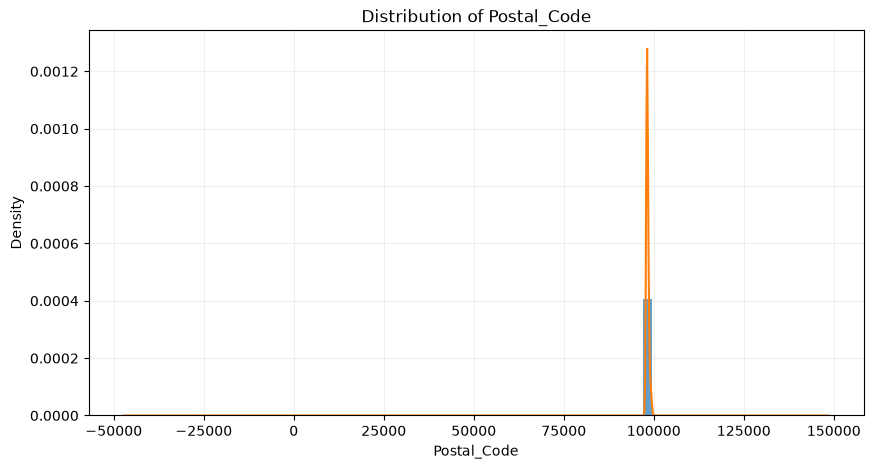

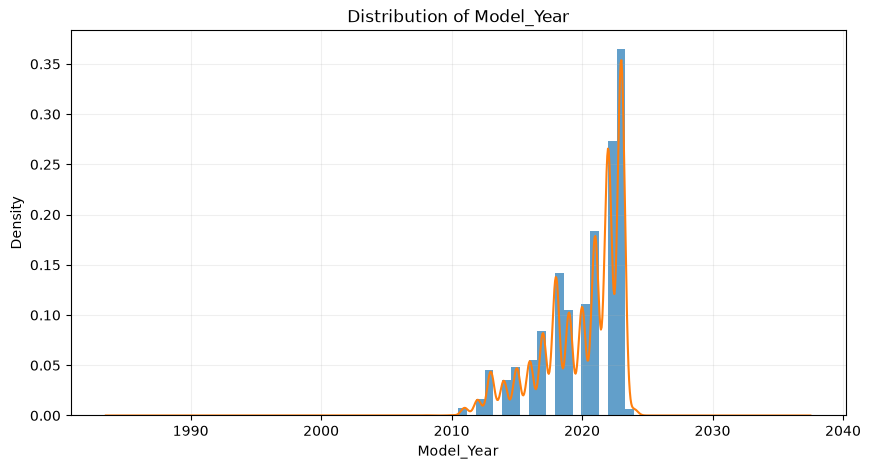

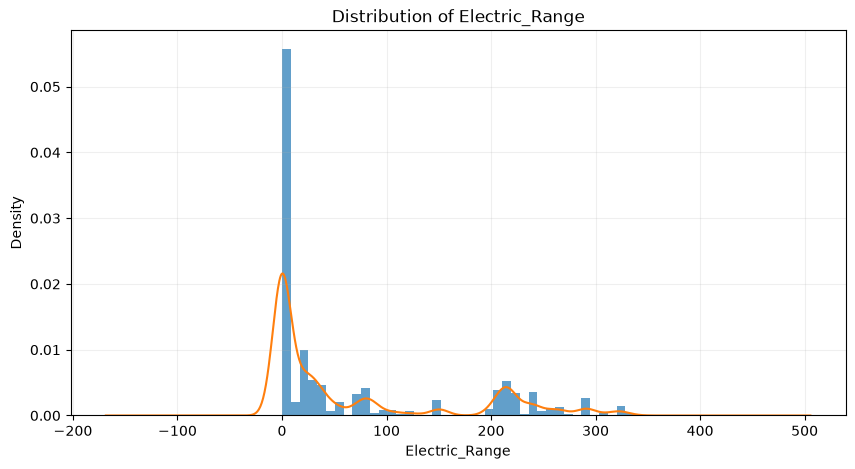

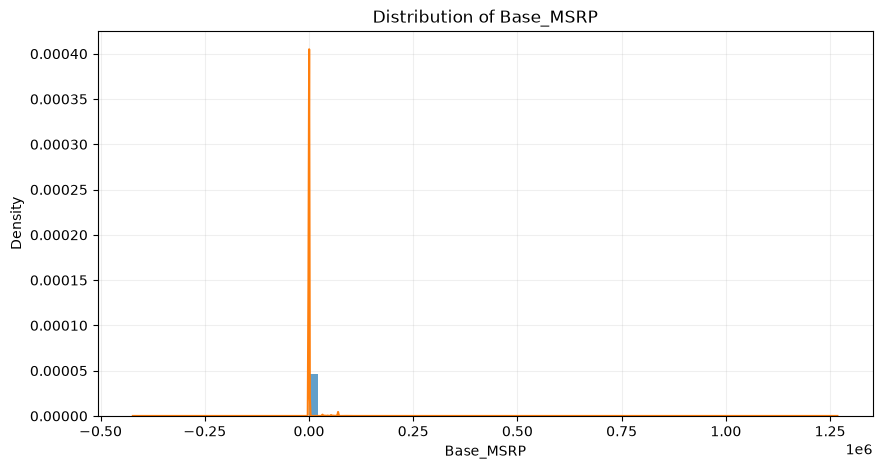

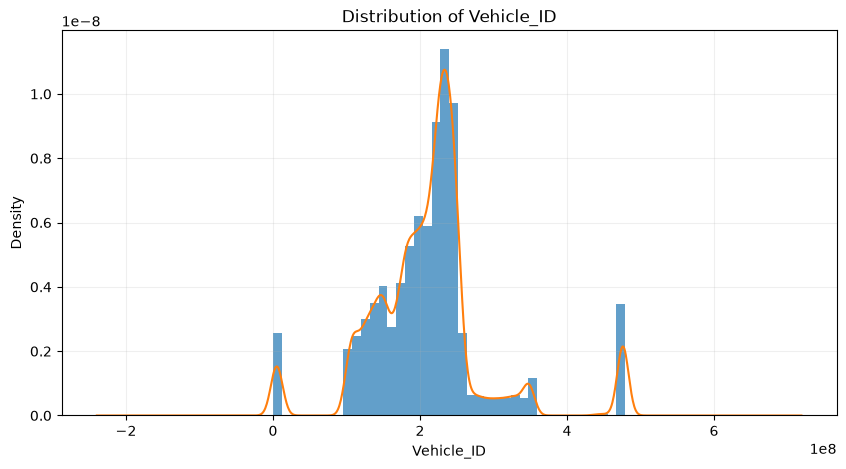

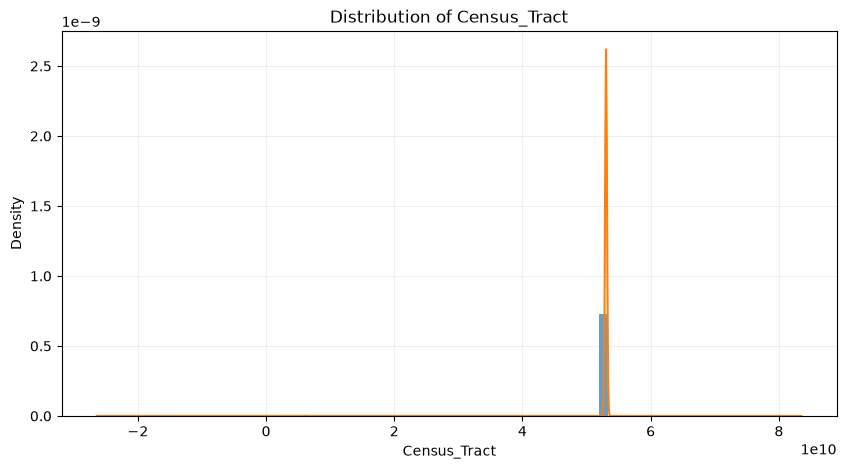

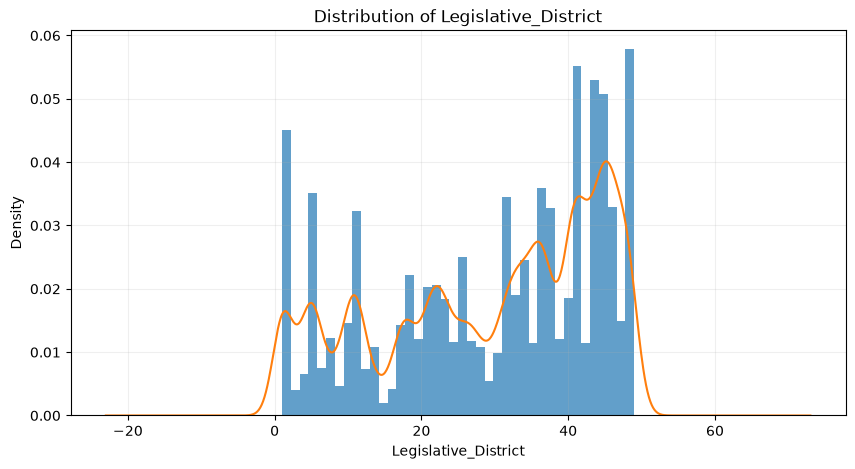

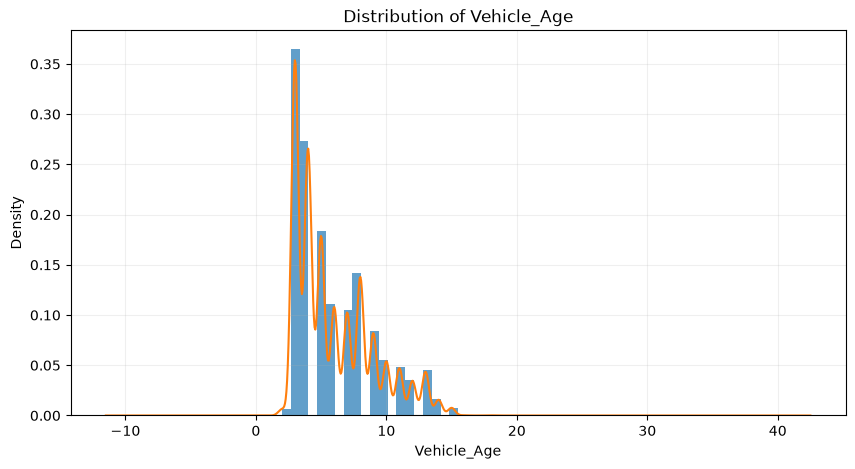

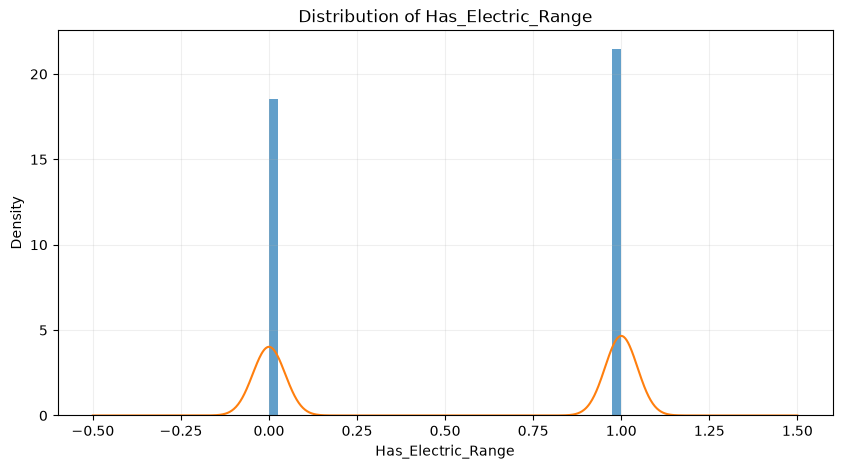

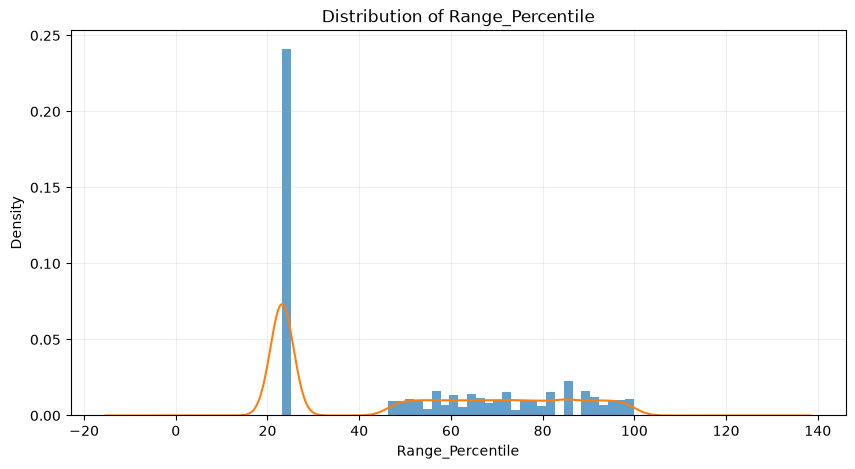

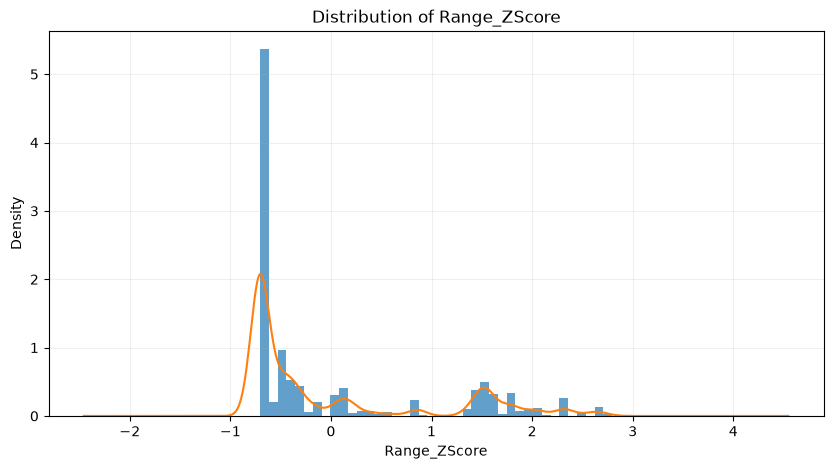

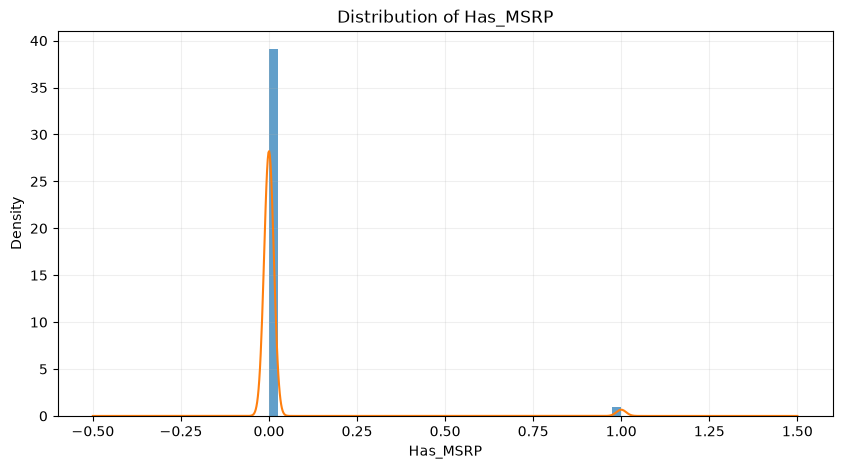

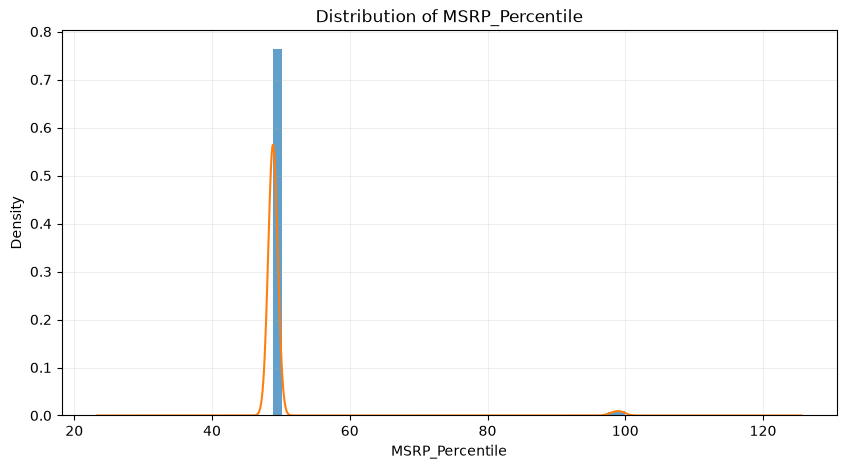

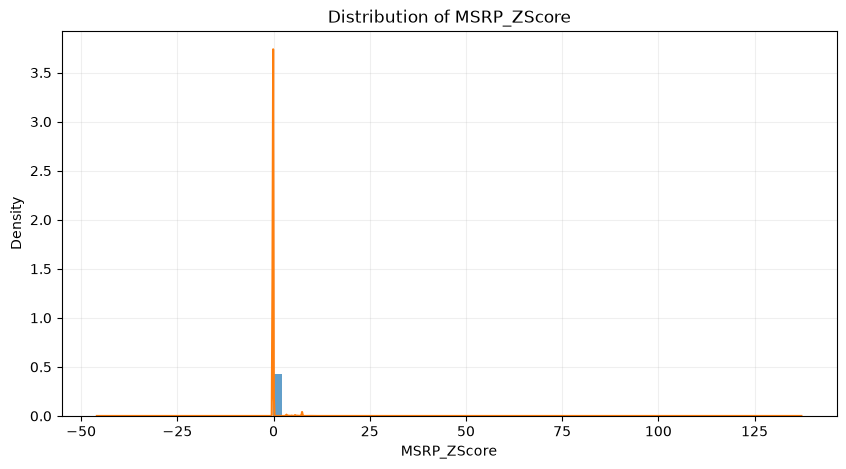

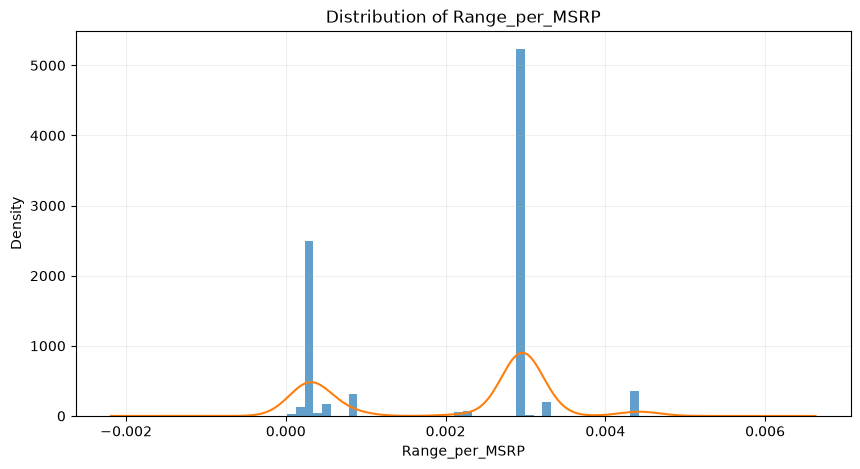

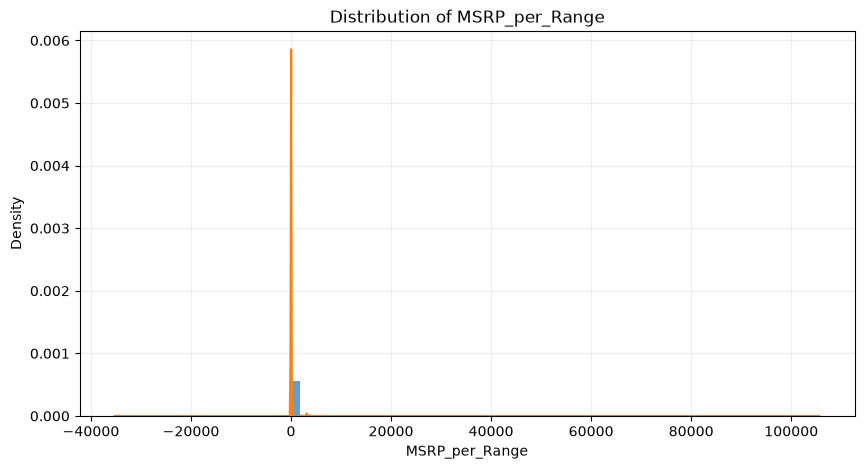

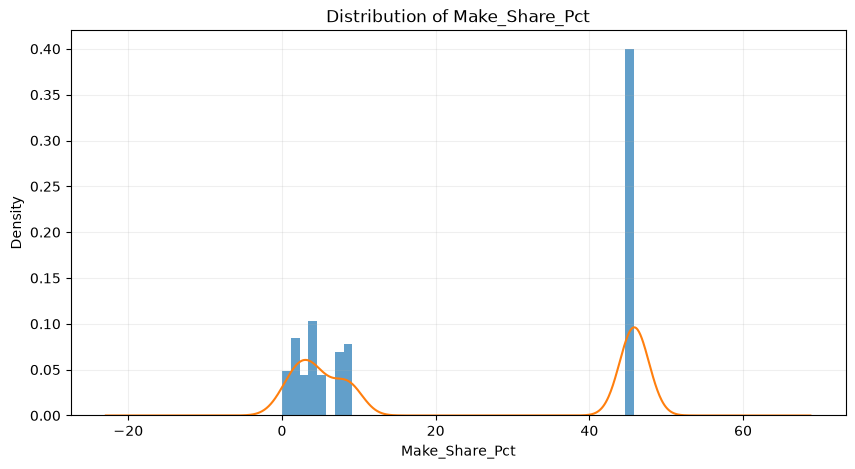

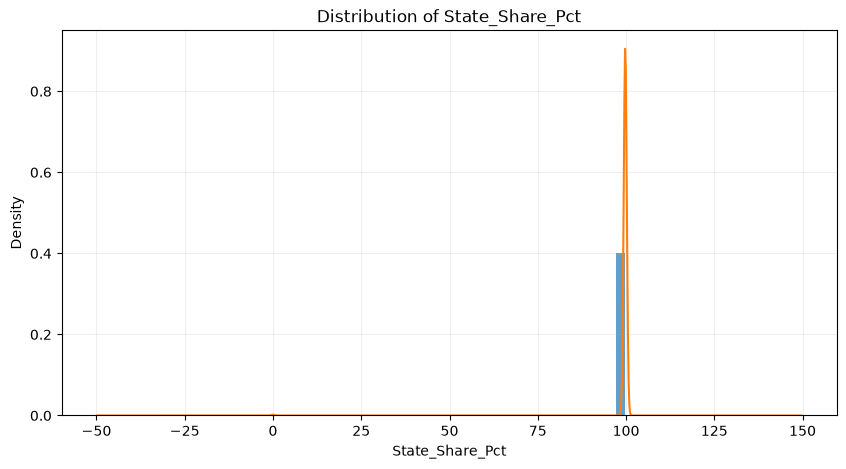

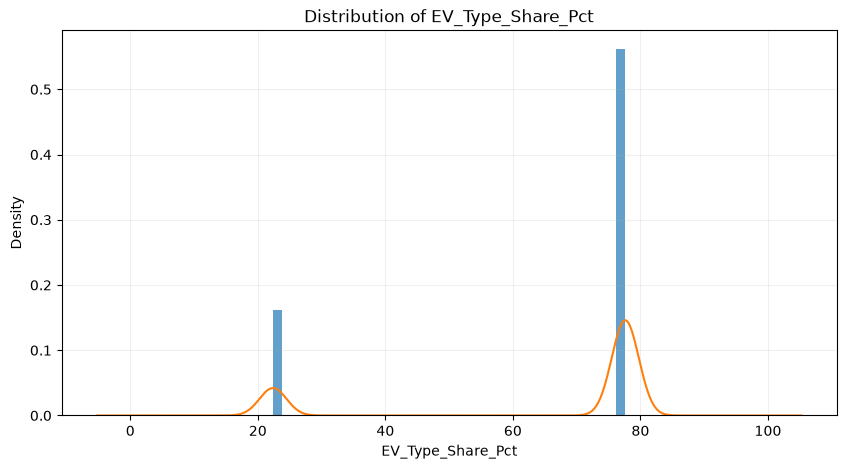

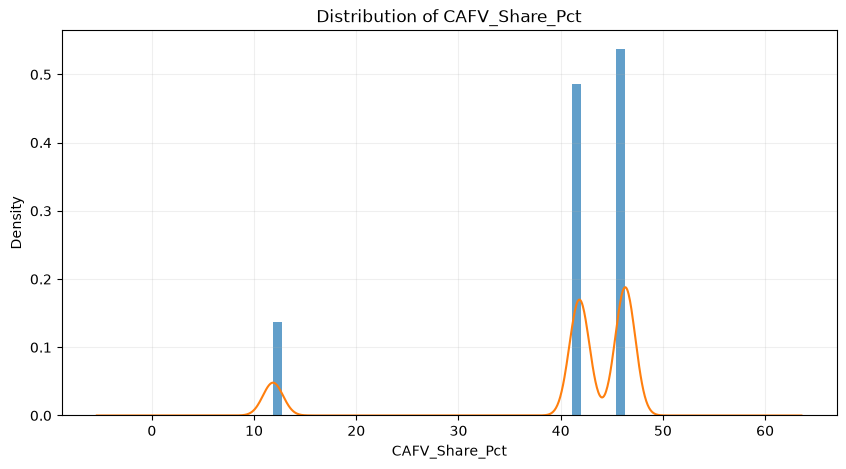

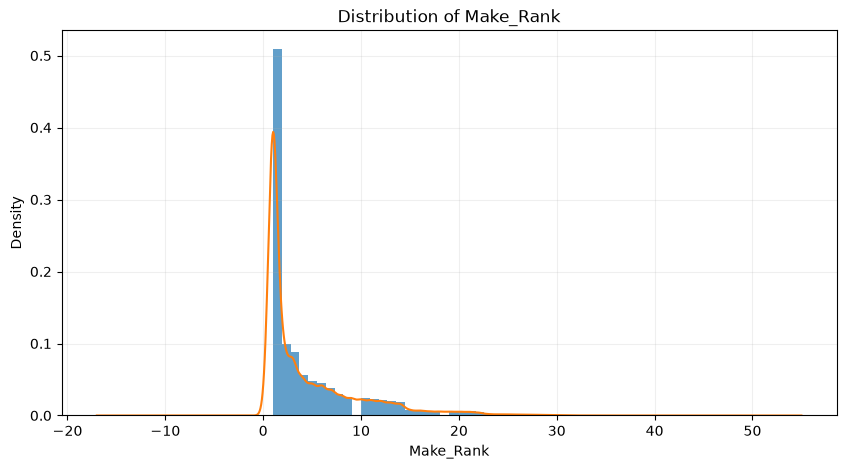

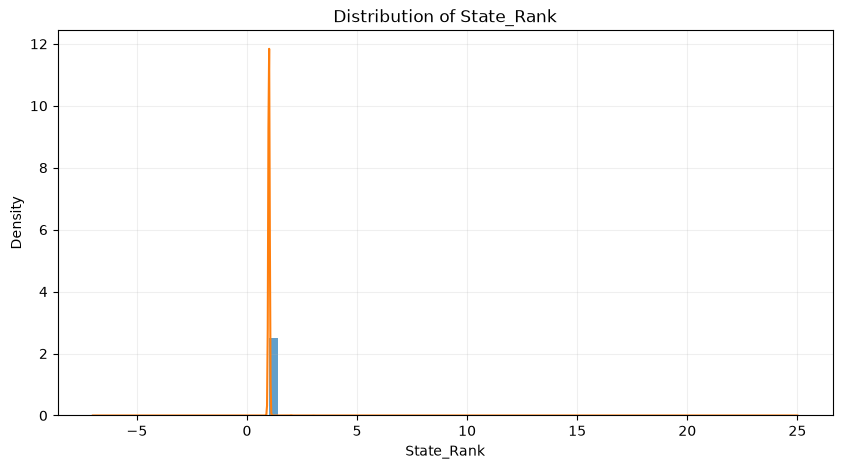

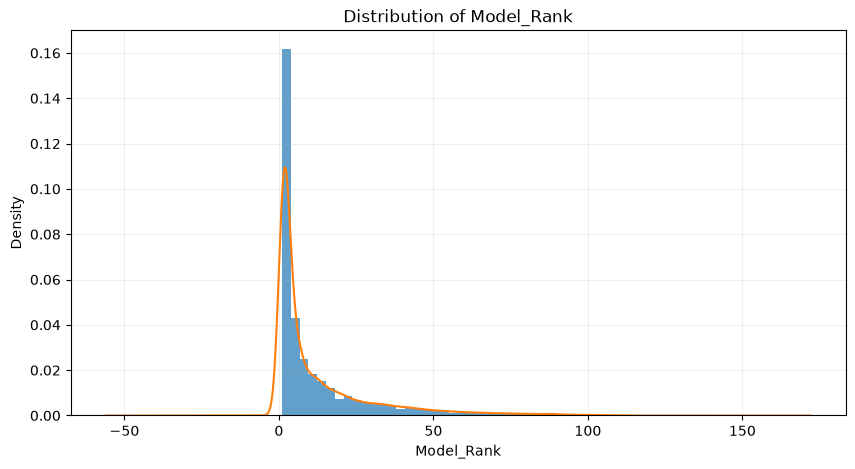

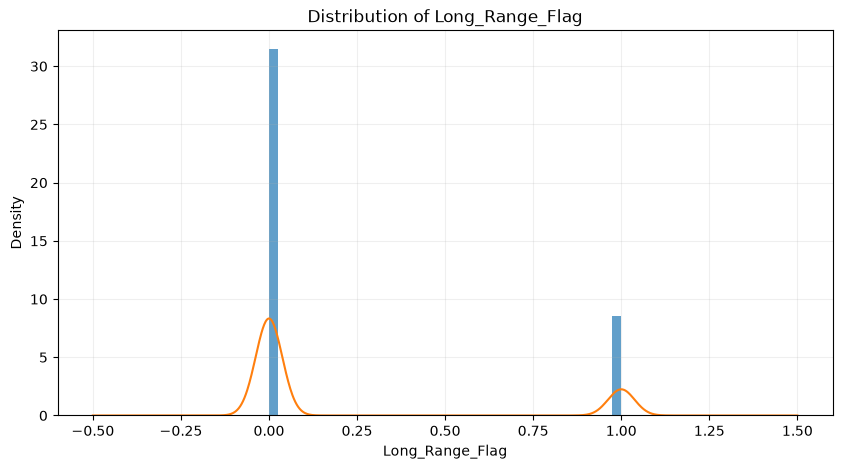

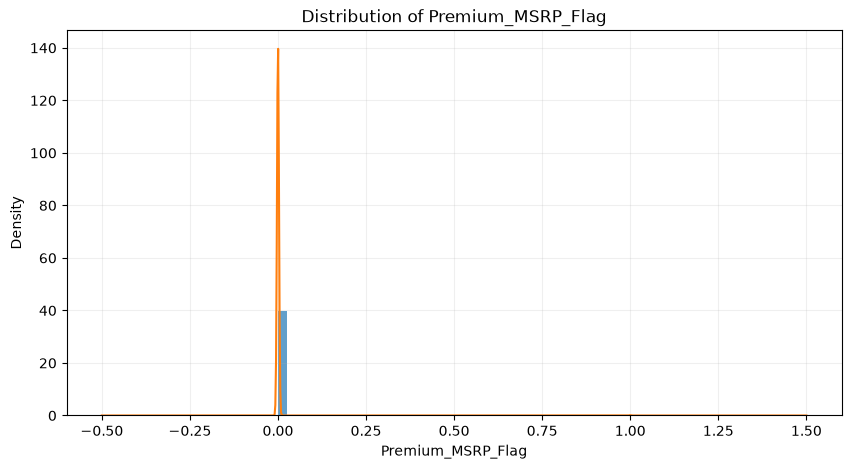

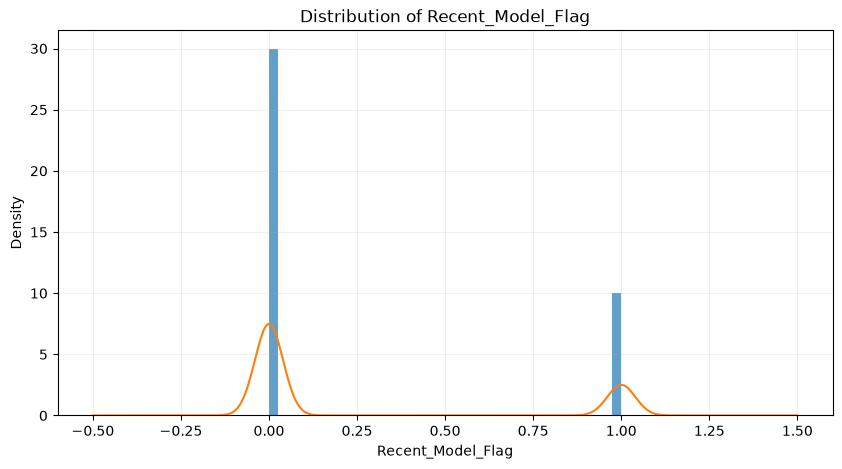

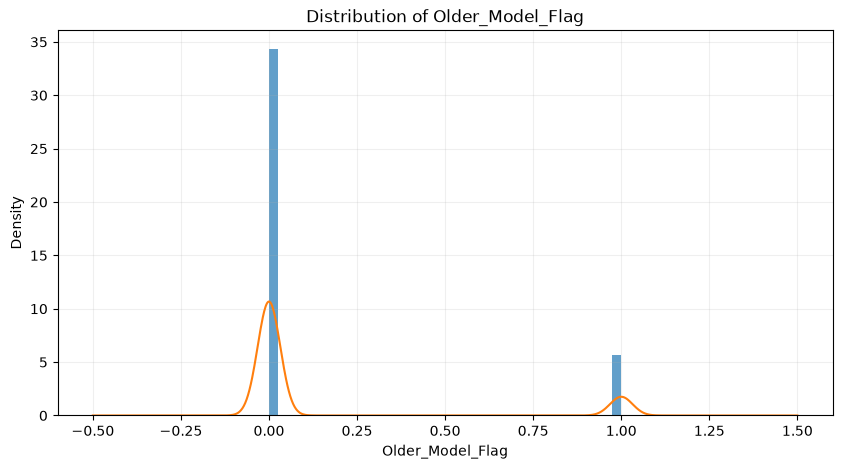

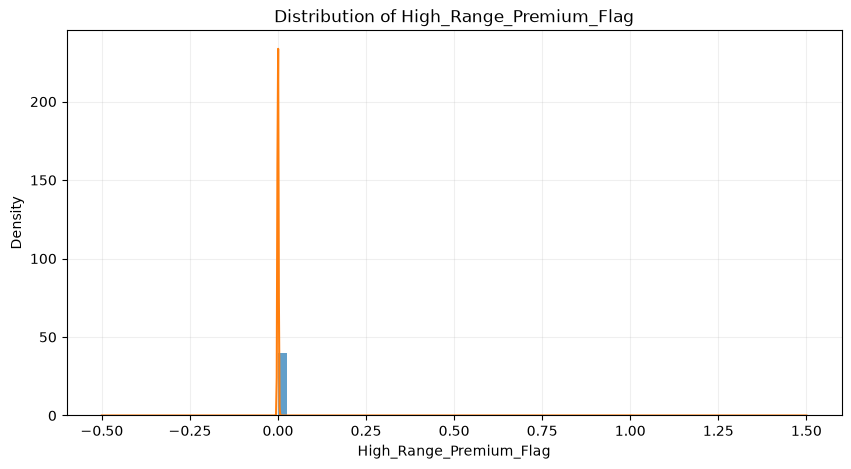

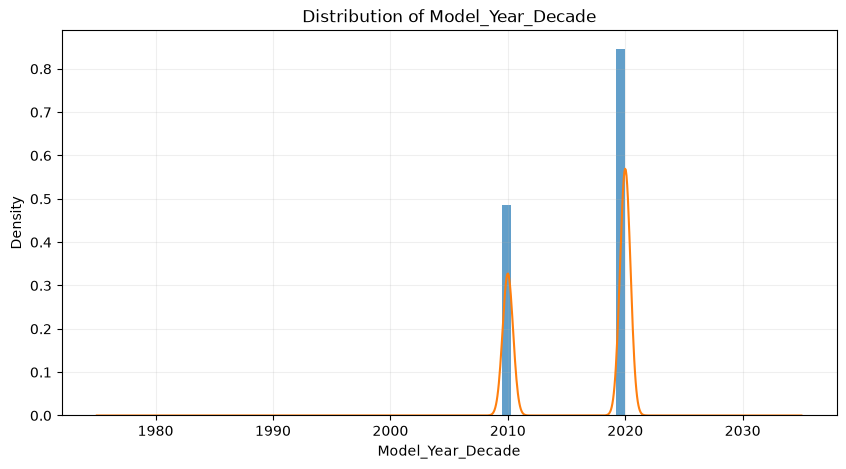

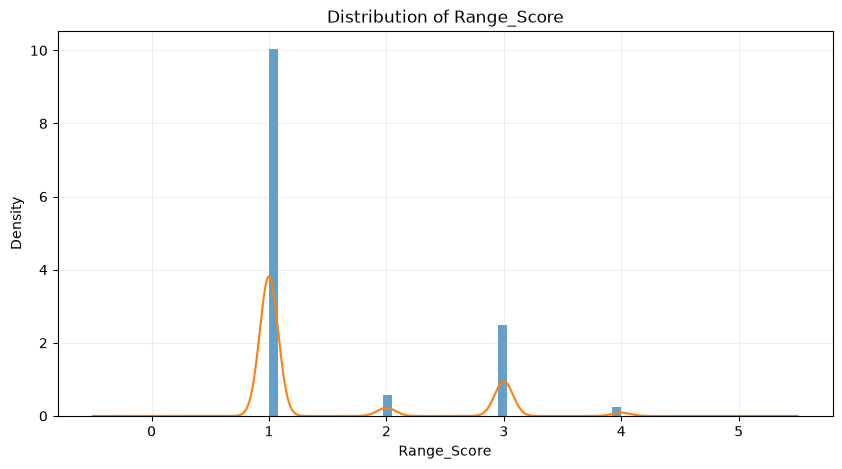

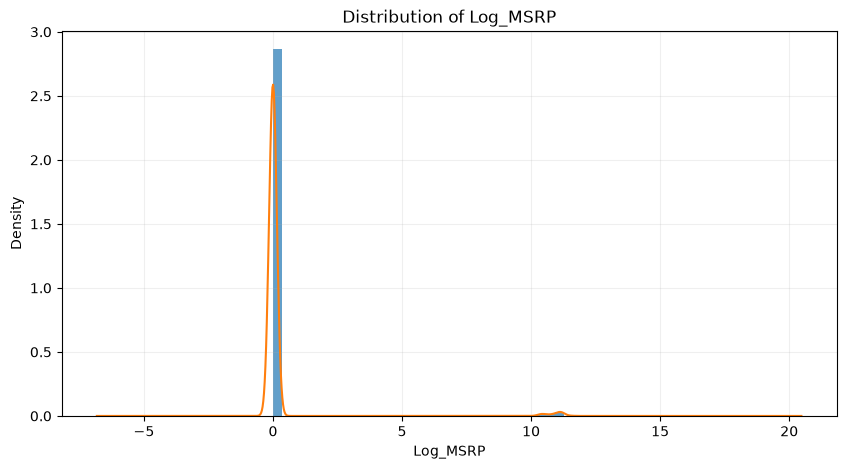

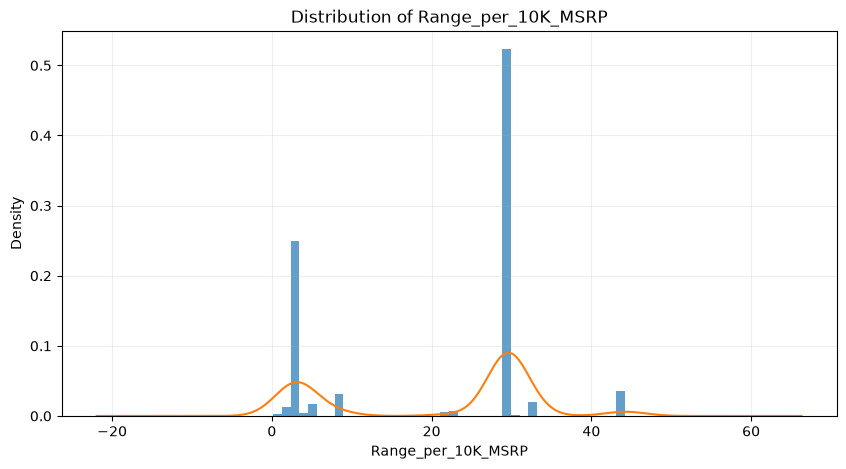

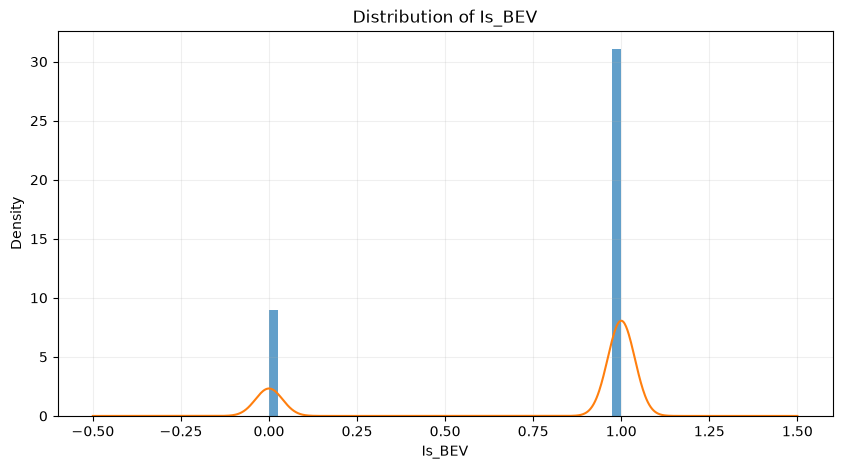

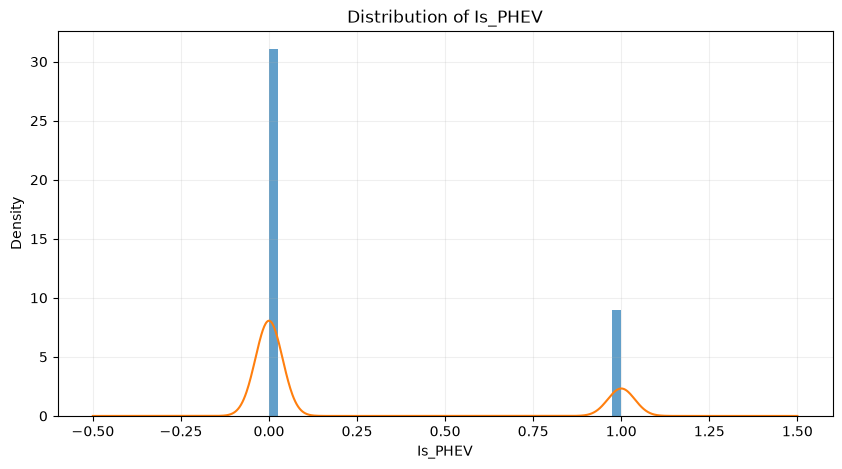

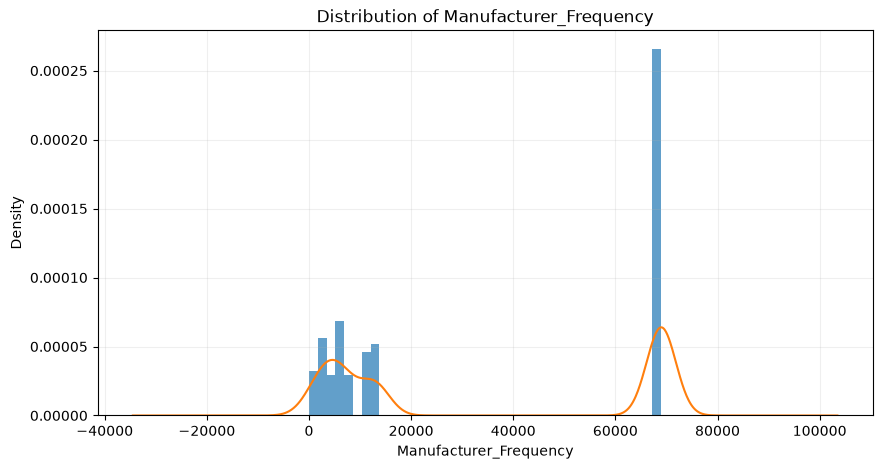

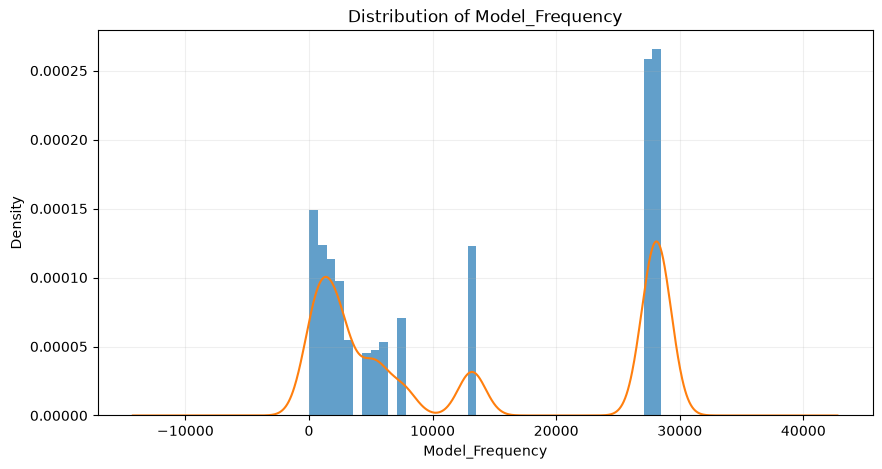

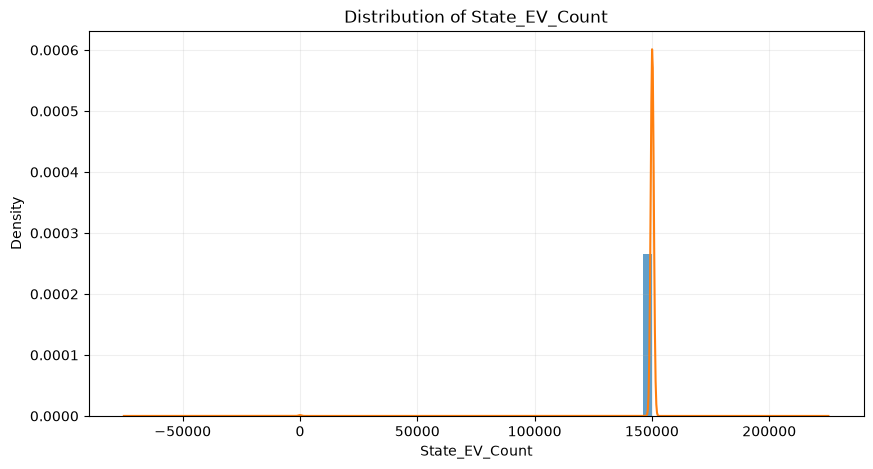

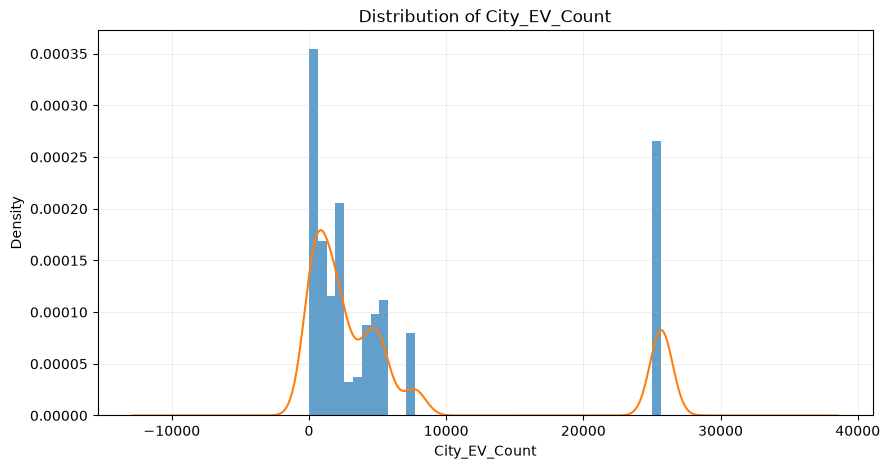

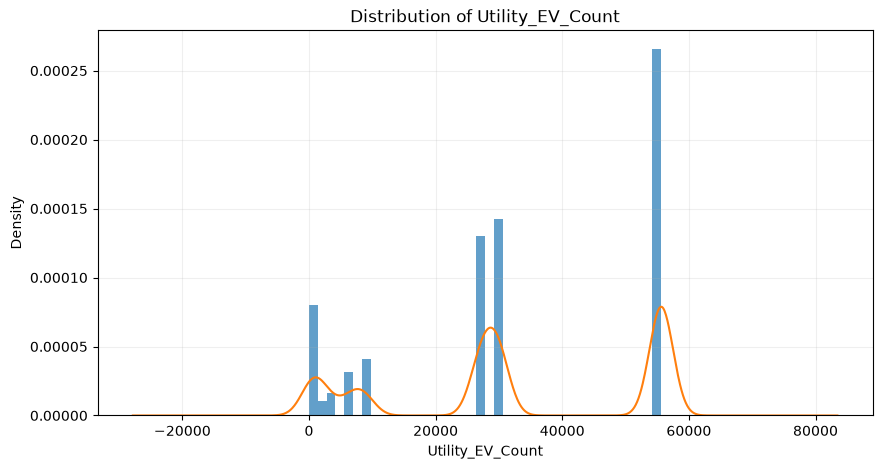

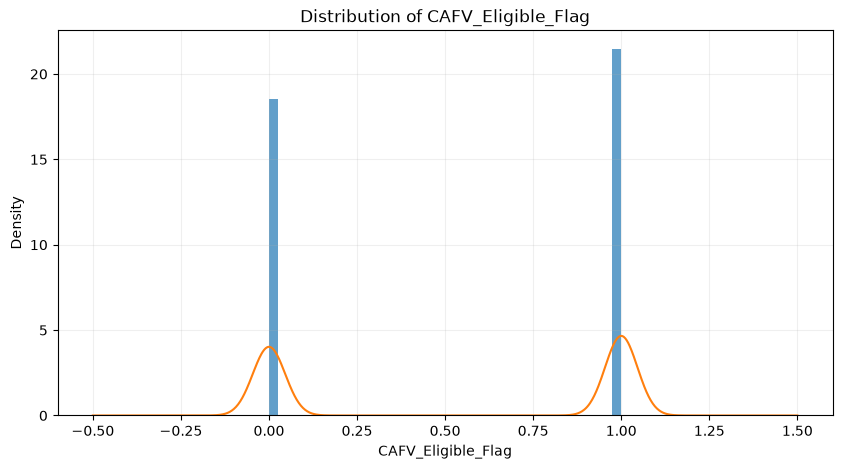

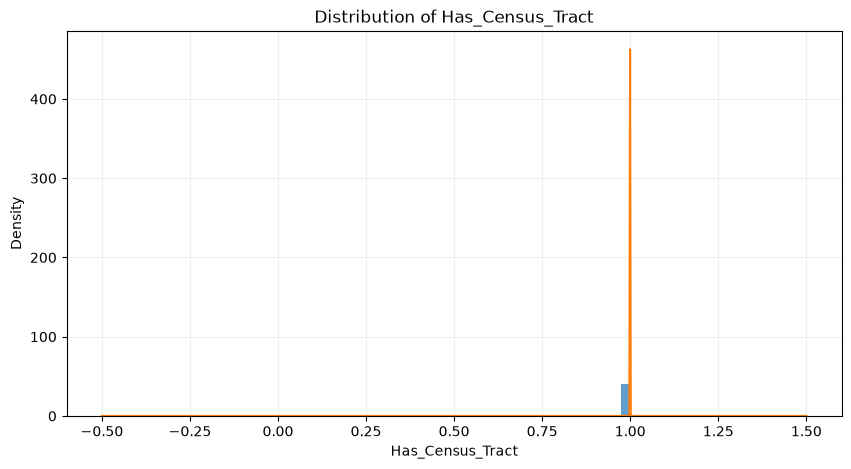

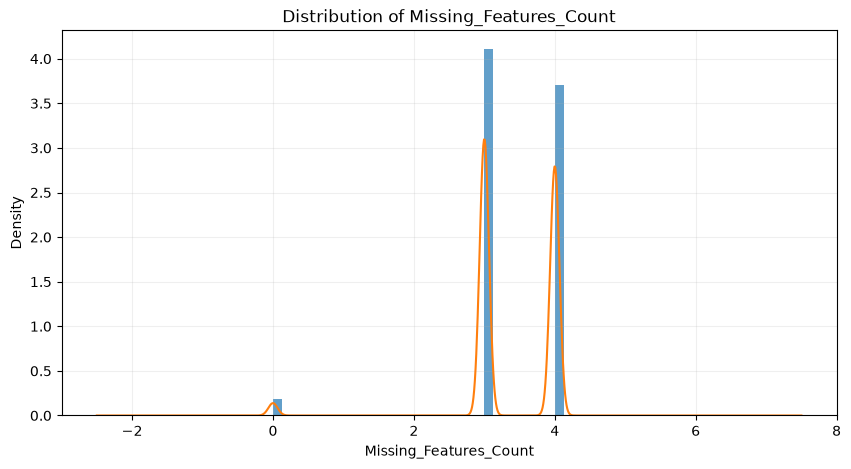

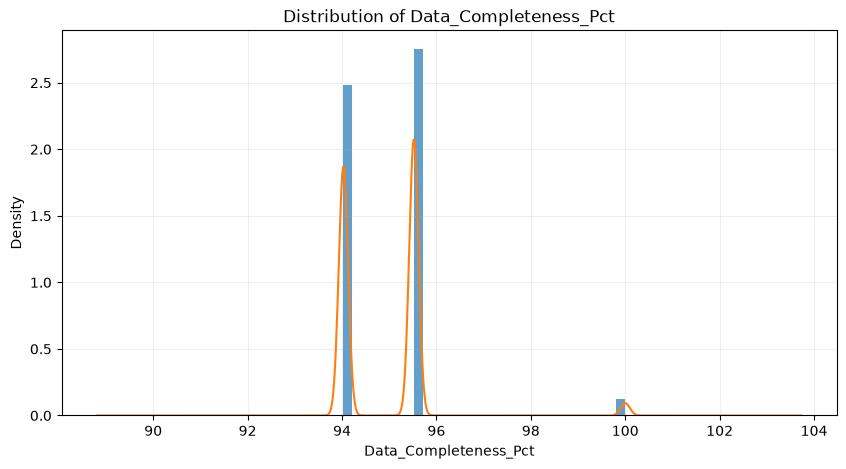

In [7]:
for col in numeric_cols:
    values = df[col].dropna()
    if values.nunique() < 2:
        continue

    plt.figure(figsize=(10, 5))
    plt.hist(values, bins=40, density=True, alpha=0.7)
    values.plot(kind="kde")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()


# 7. Box Plot & Outlier Inspection

For a box plot:

\[
IQR=Q_3-Q_1
\]

Lower fence:

\[
Q_1-1.5(IQR)
\]

Upper fence:

\[
Q_3+1.5(IQR)
\]

Values beyond these fences are potential outliers, **not automatically errors**.


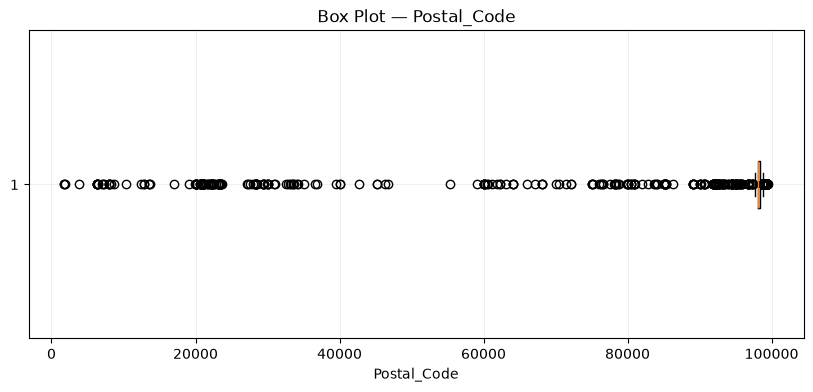

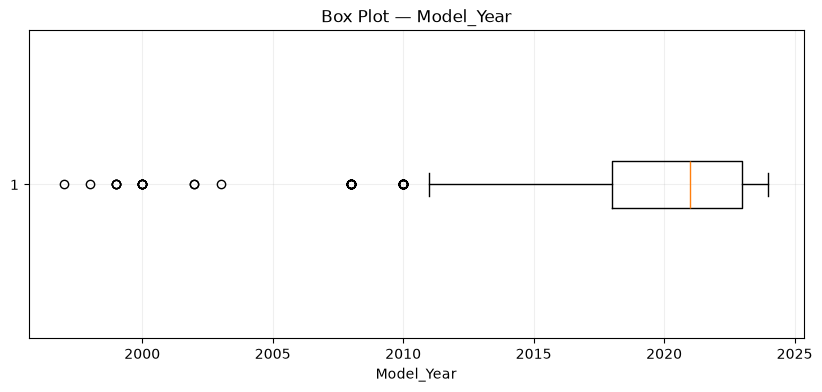

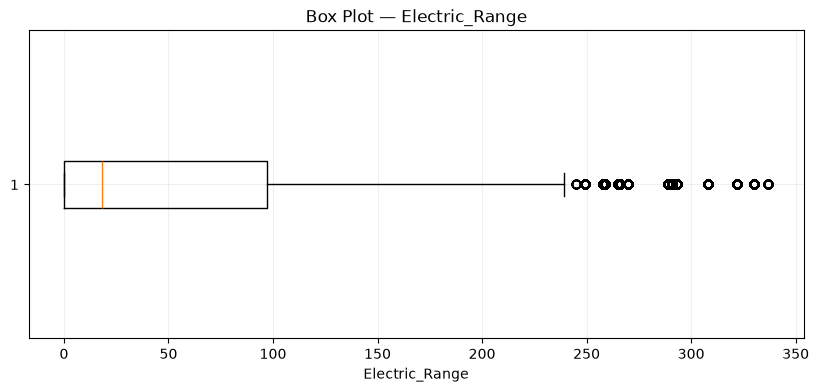

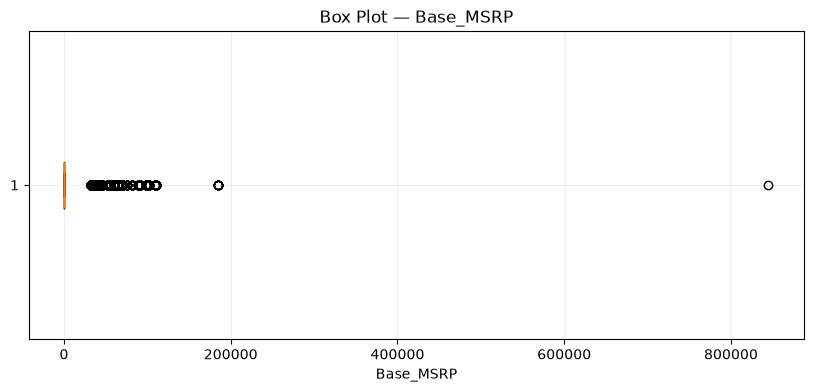

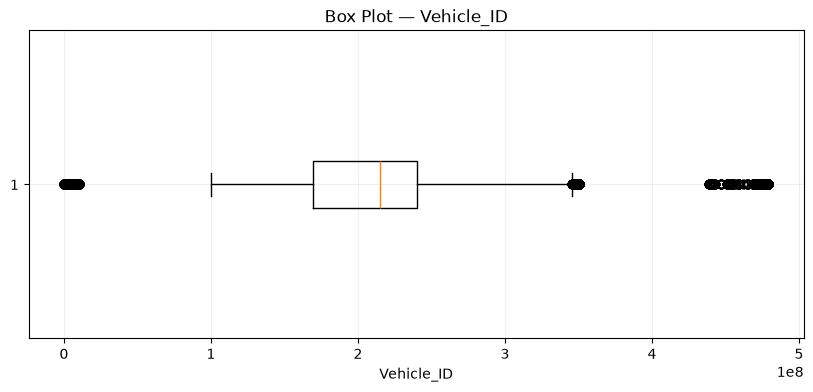

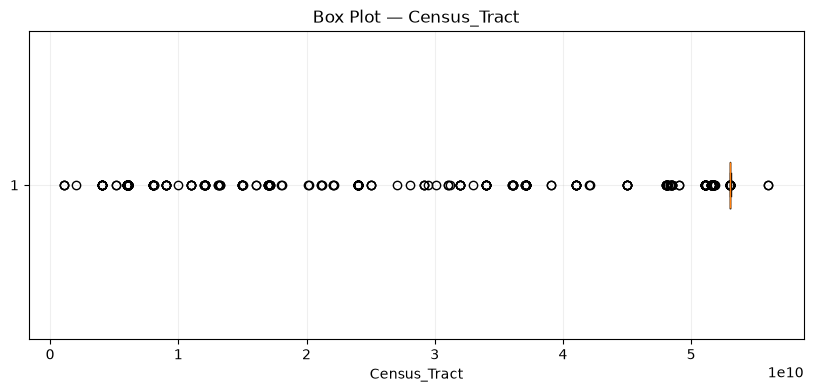

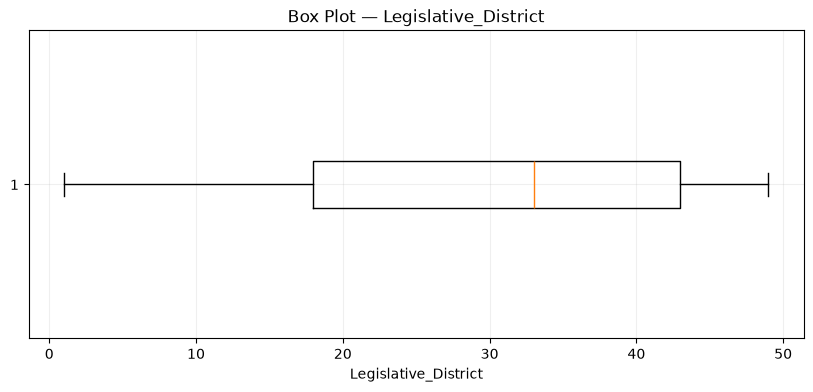

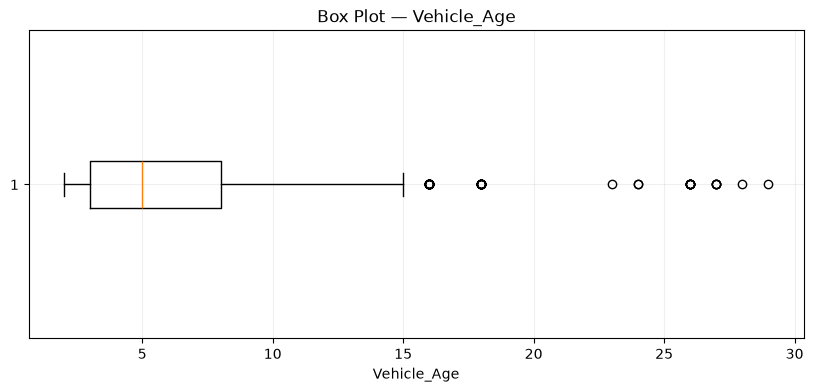

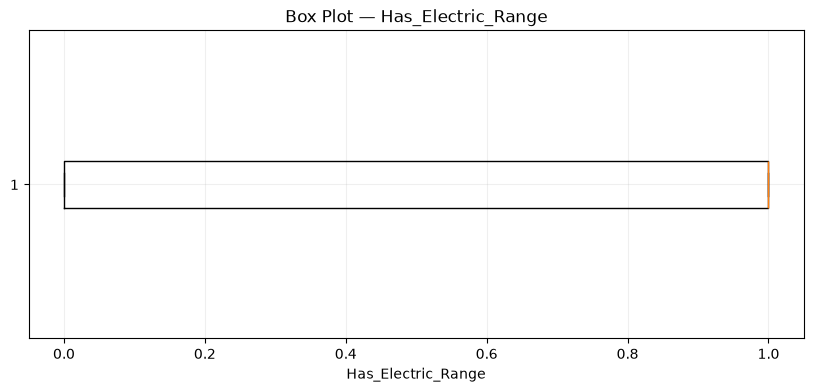

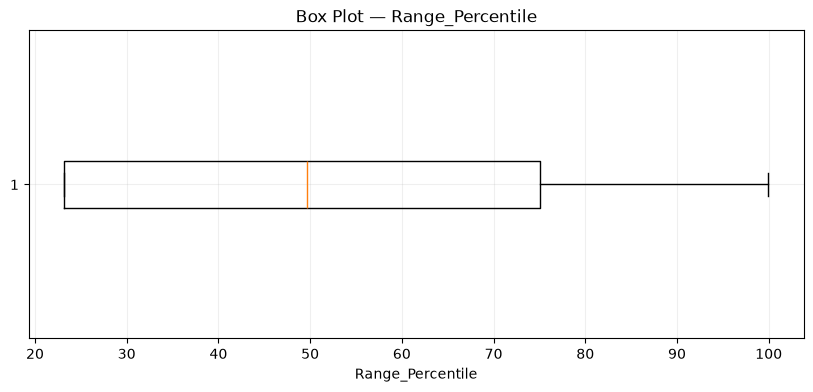

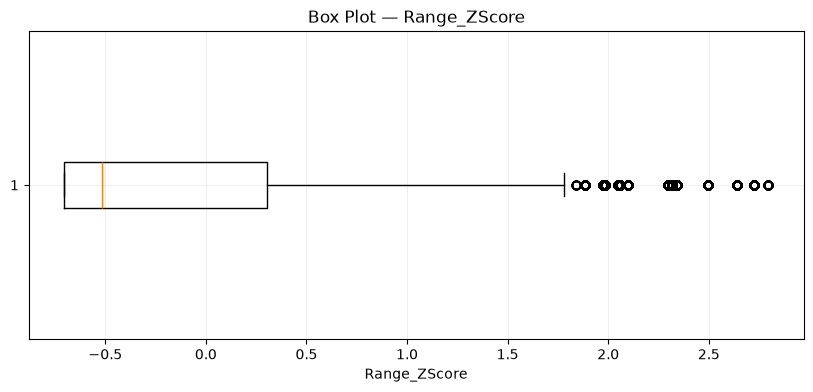

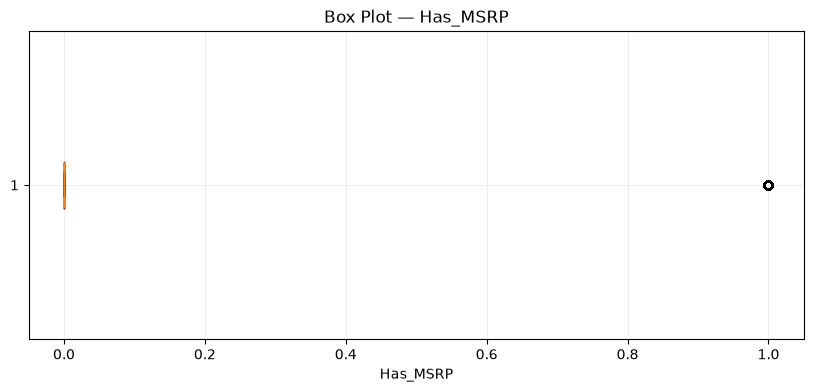

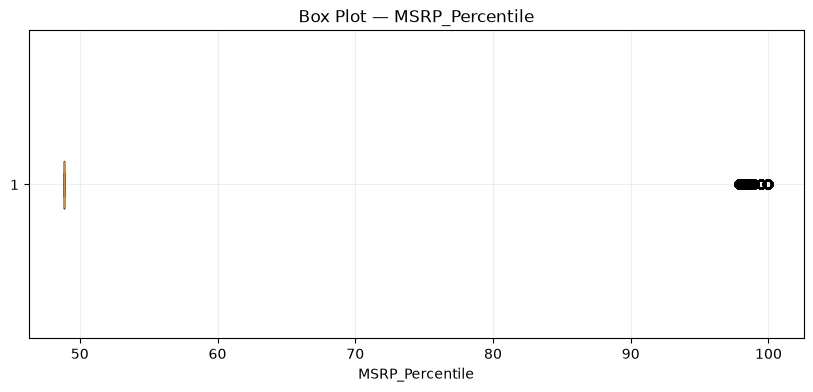

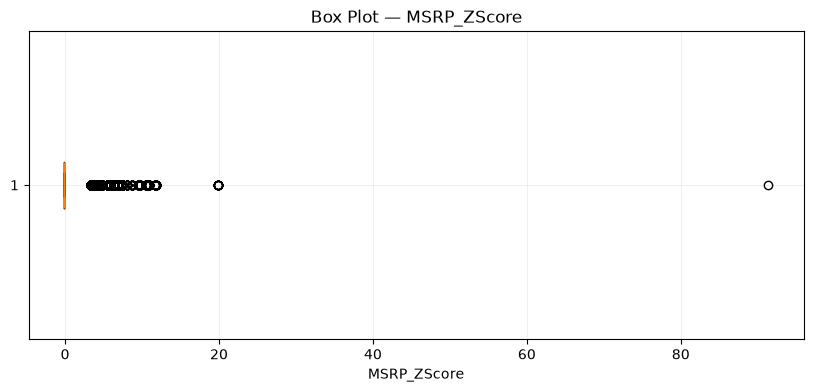

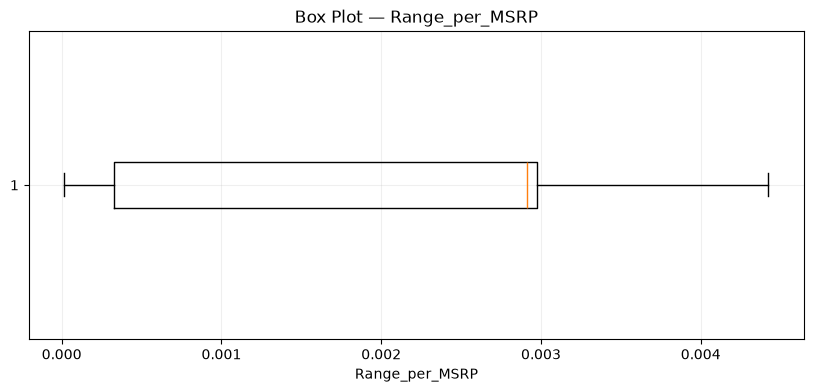

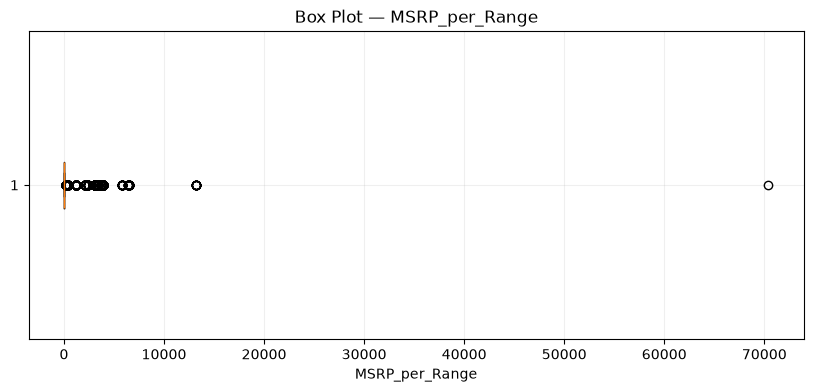

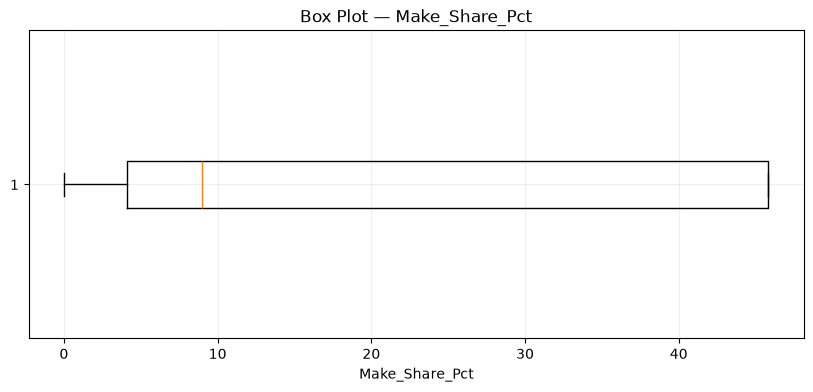

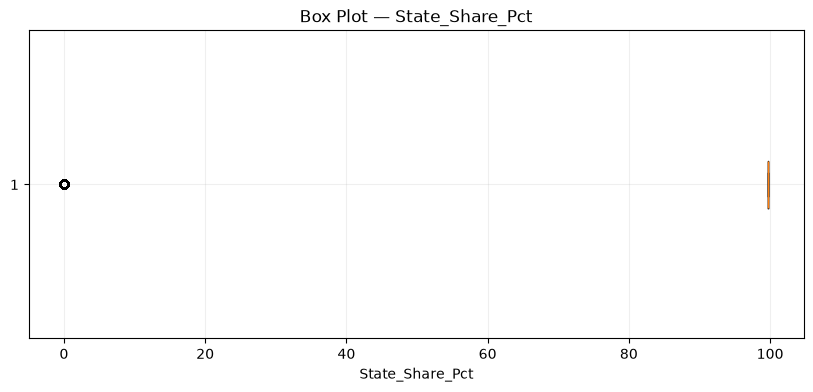

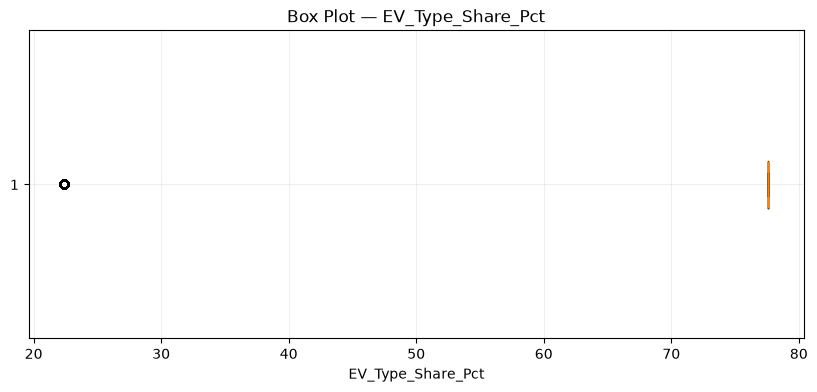

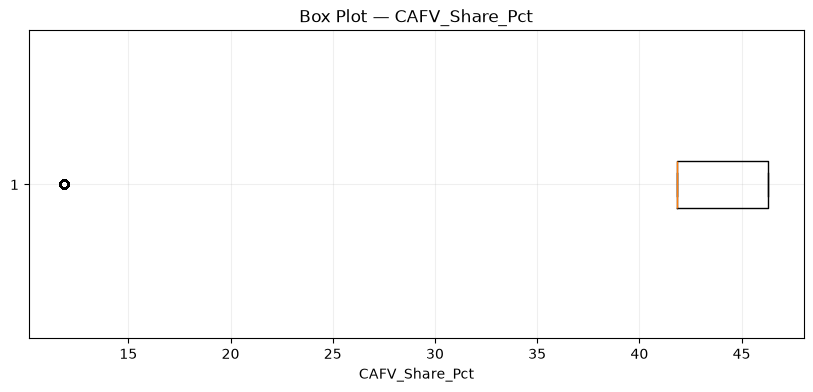

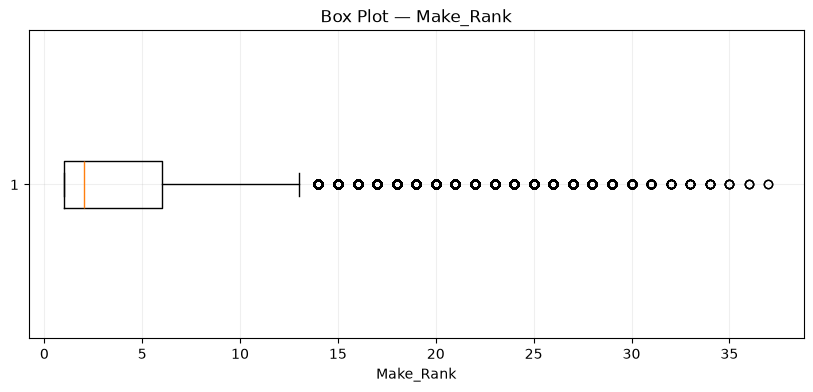

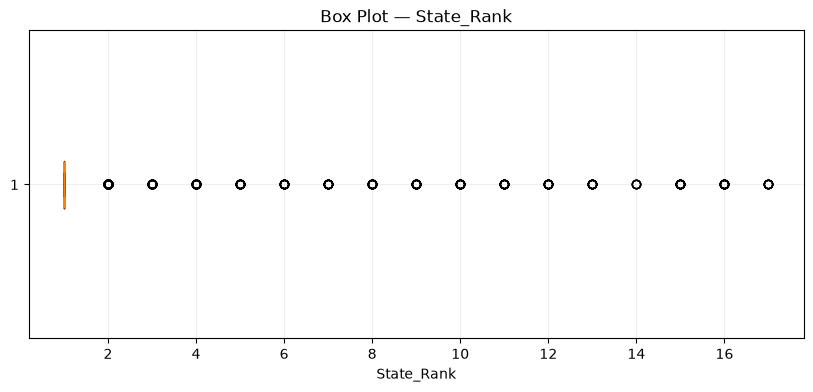

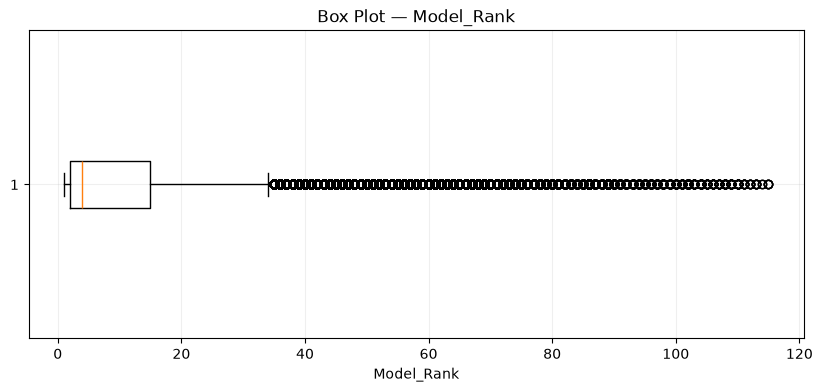

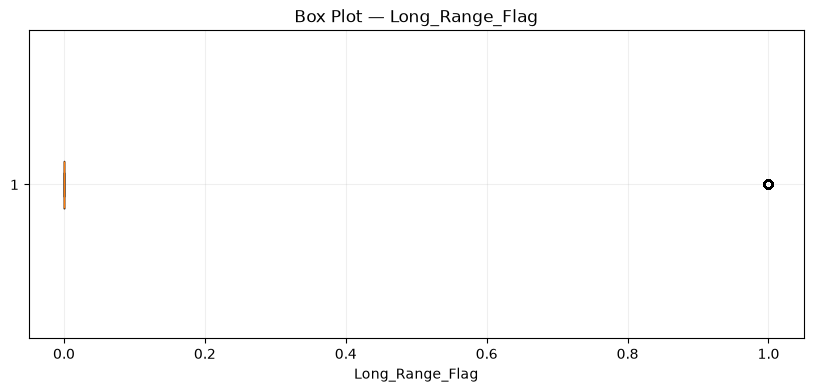

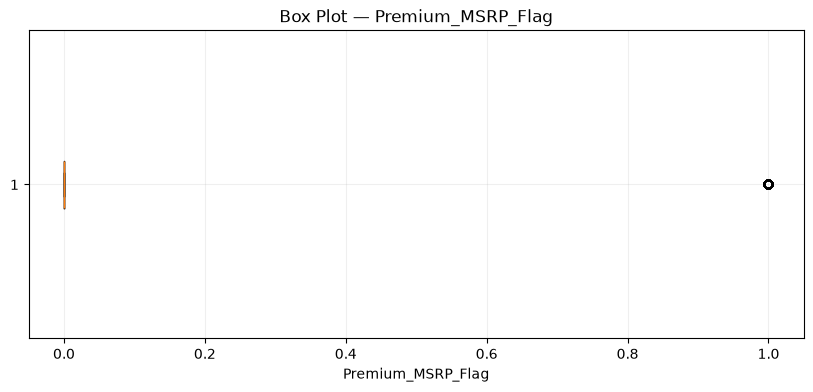

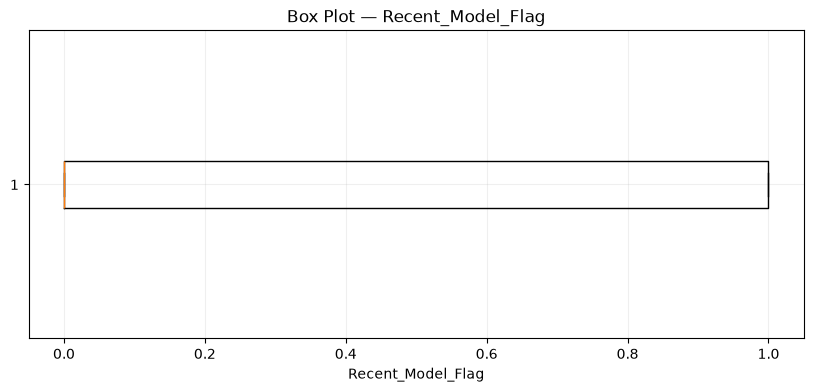

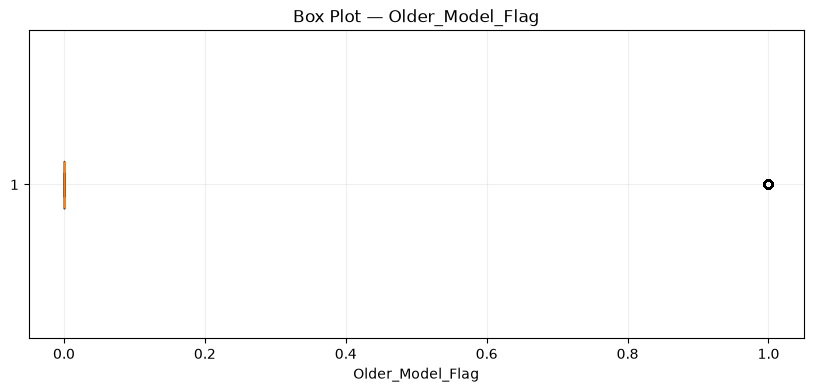

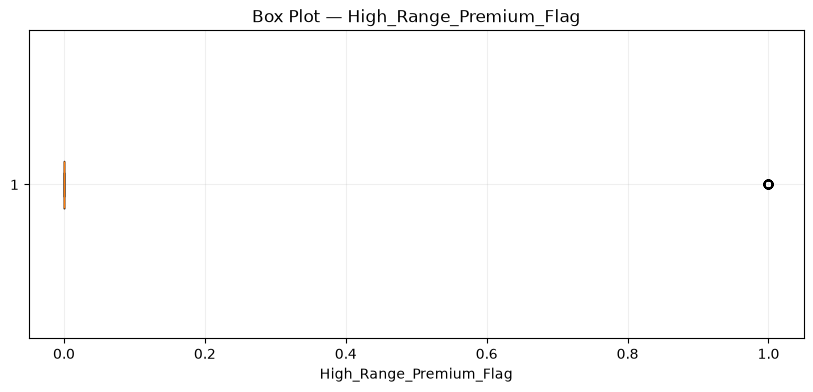

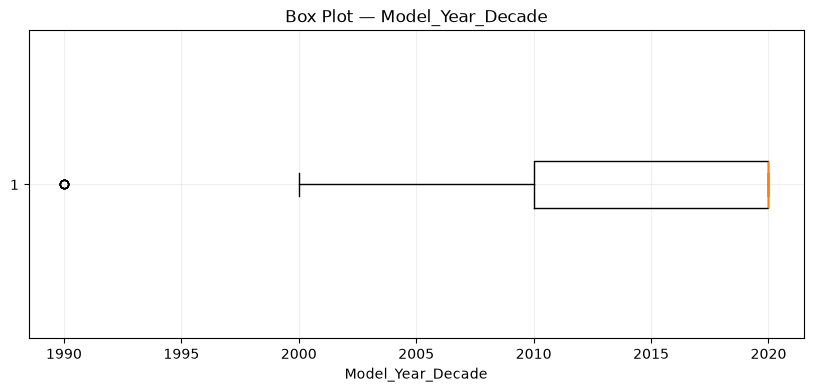

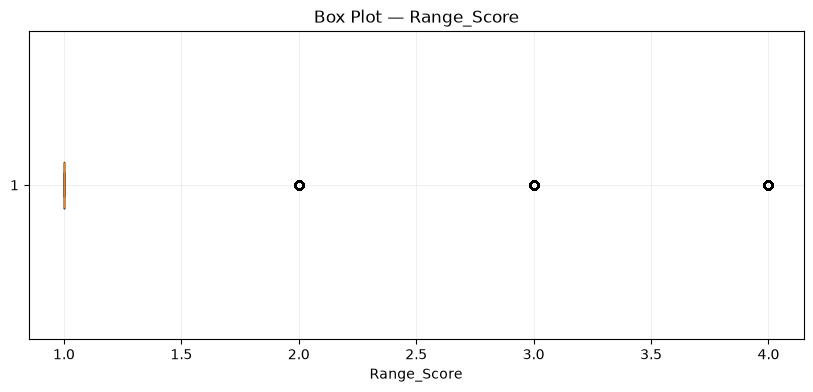

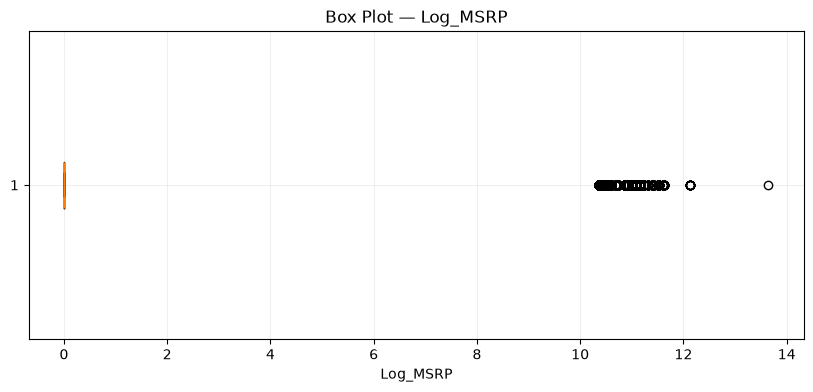

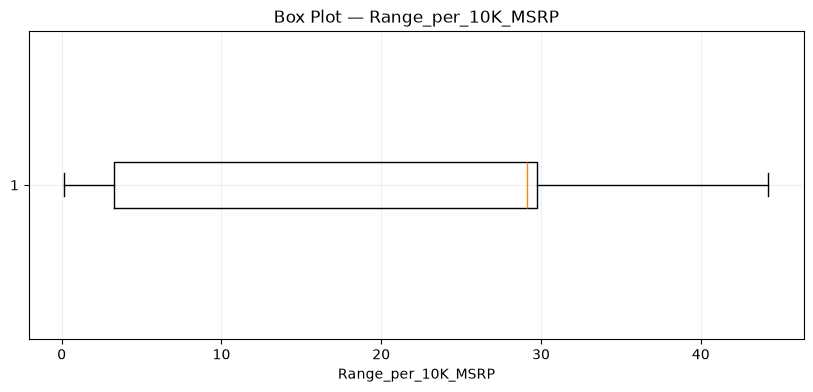

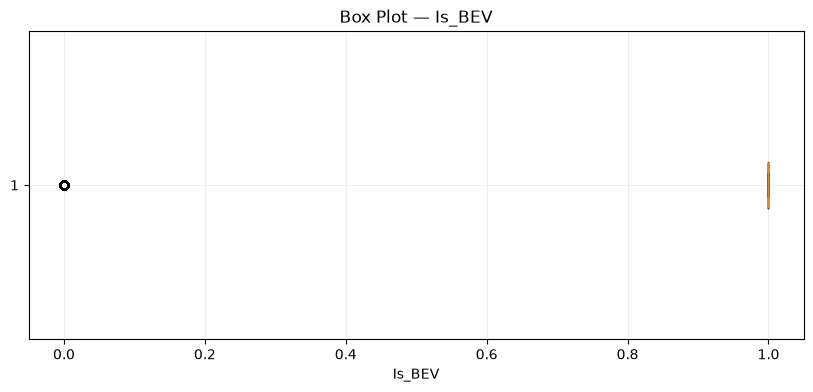

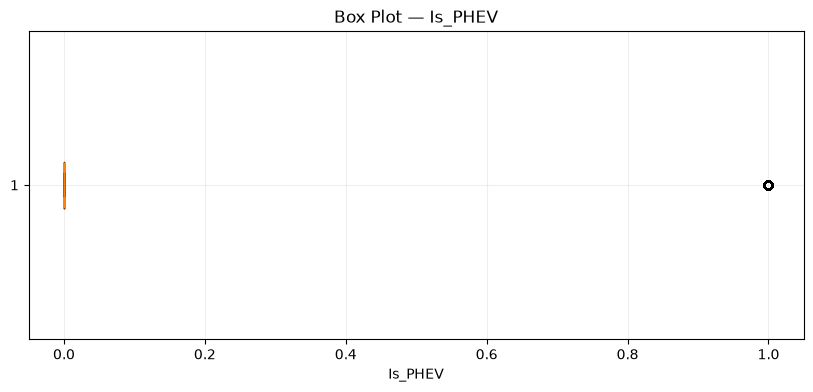

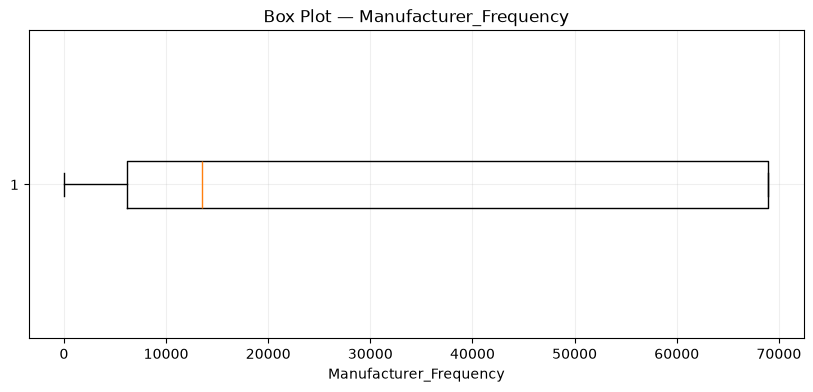

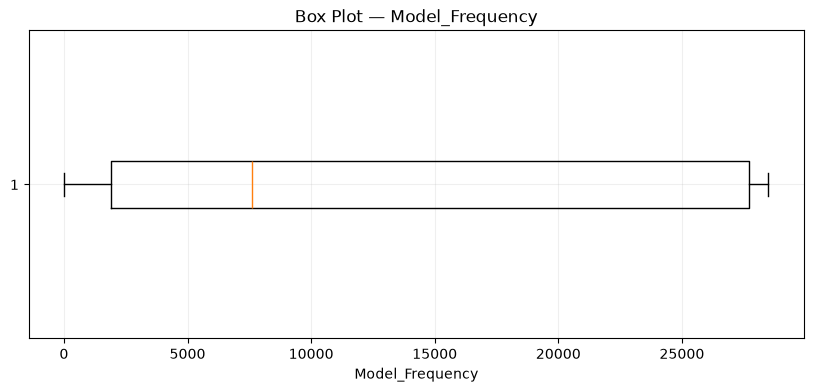

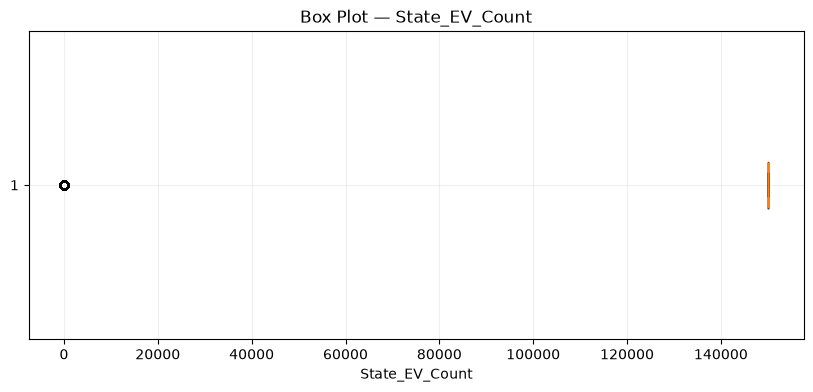

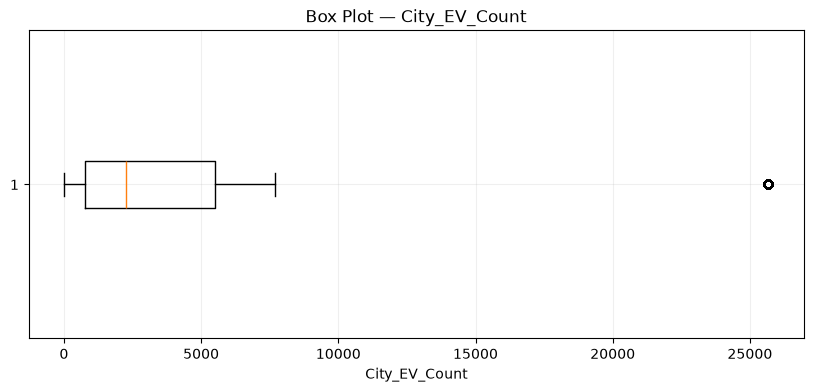

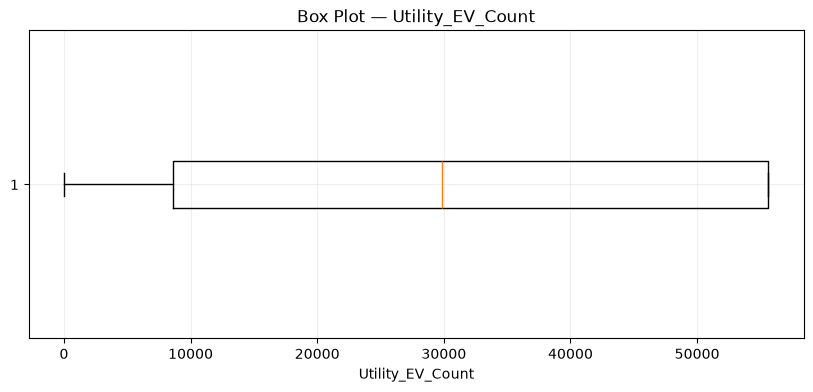

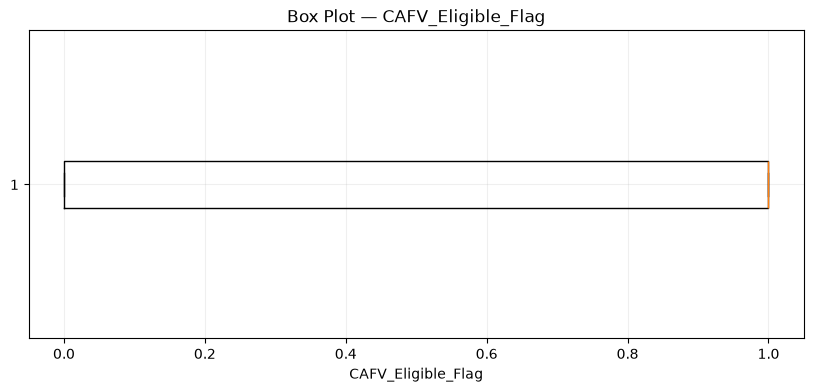

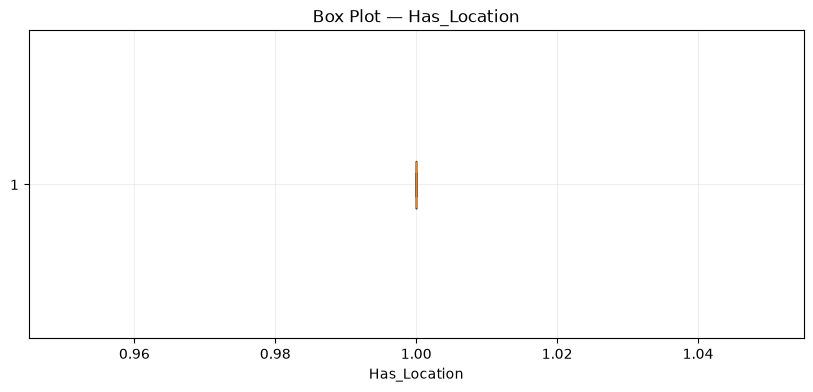

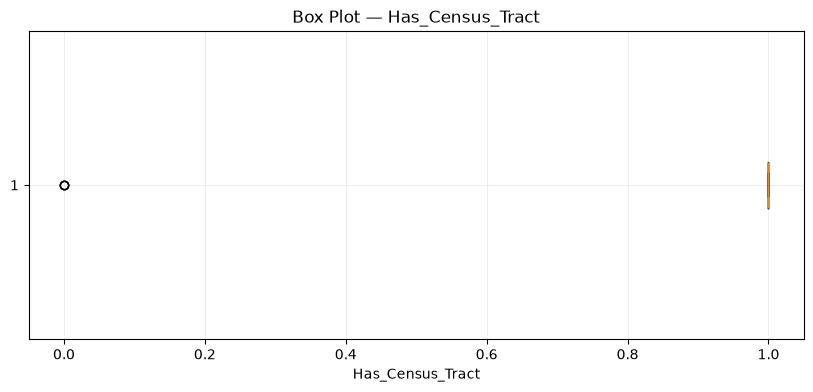

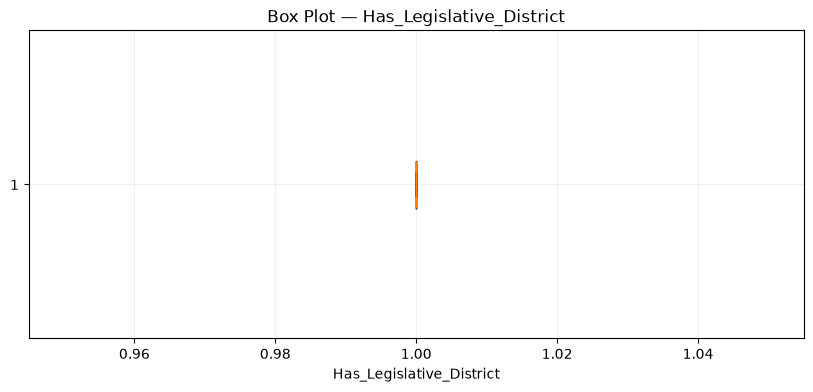

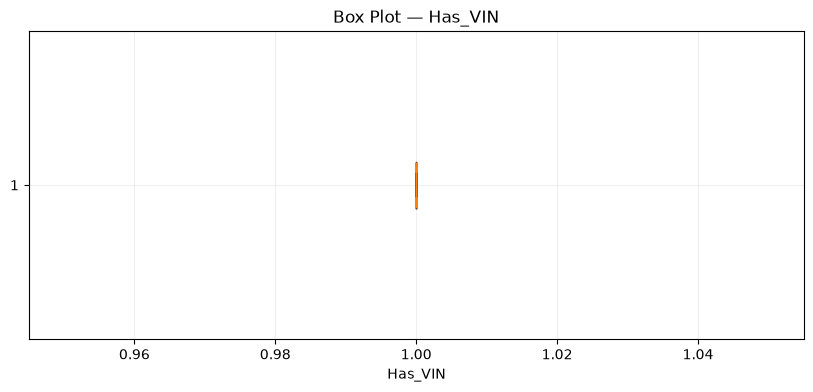

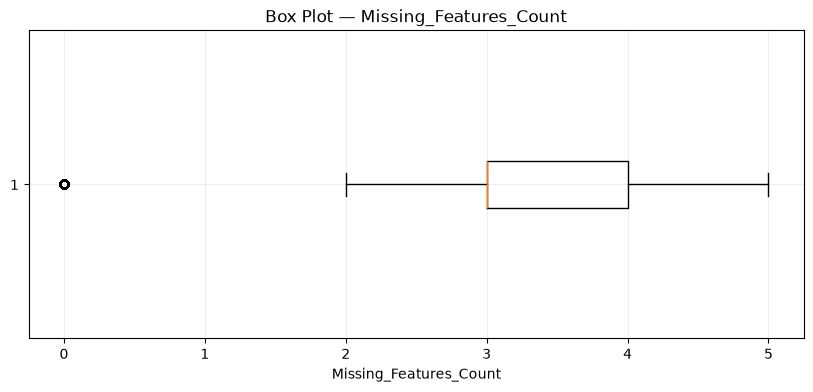

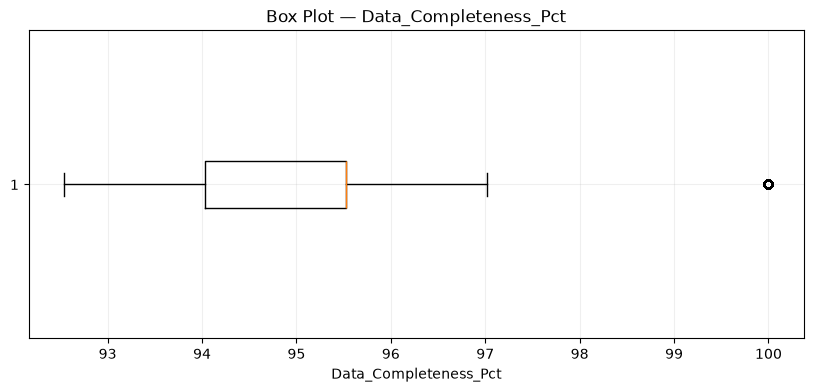

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box Plot — {col}")
    plt.xlabel(col)
    plt.grid(alpha=0.2)
    plt.show()


In [9]:
# IQR-based outlier summary
outlier_summary = []

for col in numeric_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    outlier_summary.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Fence": lower,
        "Upper_Fence": upper,
        "Outliers": int(mask.sum()),
        "Outlier_%": mask.mean() * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.round(3))


,Column,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outliers,Outlier_%
0,Postal_Code,9.805200e+04,9.837000e+04,3.180000e+02,9.757500e+04,9.884700e+04,9010,5.988
1,Model_Year,2.018000e+03,2.023000e+03,5.000000e+00,2.010500e+03,2.030500e+03,60,0.040
2,Electric_Range,0.000000e+00,9.700000e+01,9.700000e+01,-1.455000e+02,2.425000e+02,10073,6.694
3,Base_MSRP,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3455,2.296
4,Vehicle_ID,1.693473e+08,2.399119e+08,7.056459e+07,6.350042e+07,3.457588e+08,13268,8.817
5,Census_Tract,5.303301e+10,5.305307e+10,2.006301e+07,5.300291e+10,5.308317e+10,379,0.252
6,Legislative_District,1.800000e+01,4.300000e+01,2.500000e+01,-1.950000e+01,8.050000e+01,0,0.000
7,Vehicle_Age,3.000000e+00,8.000000e+00,5.000000e+00,-4.500000e+00,1.550000e+01,60,0.040
8,Has_Electric_Range,0.000000e+00,1.000000e+00,1.000000e+00,-1.500000e+00,2.500000e+00,0,0.000
9,Range_Percentile,2.315900e+01,7.506000e+01,5.190200e+01,-5.469400e+01,1.529130e+02,0,0.000


# 8. Skewness & Kurtosis

### Skewness

Measures asymmetry.

- Near 0 → approximately symmetric
- Positive → right-skewed
- Negative → left-skewed

### Kurtosis

Describes tail/extreme-value behaviour relative to a normal distribution.

Visualization should always be considered alongside these numerical measures.


In [10]:
shape_stats = pd.DataFrame({
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})

display(shape_stats.round(3))


,Skewness,Kurtosis
Postal_Code,-29.862,937.830
Model_Year,-0.978,0.235
Electric_Range,1.219,-0.032
Base_MSRP,11.931,518.692
Vehicle_ID,0.897,3.290
Census_Tract,-25.965,696.140
Legislative_District,-0.486,-1.062
Vehicle_Age,0.978,0.235
Has_Electric_Range,-0.148,-1.978
Range_Percentile,0.324,-1.465


# 9. Coefficient of Variation

When the mean is meaningful and non-zero:

\[
CV = \frac{Standard\ Deviation}{Mean}\times100
\]

CV helps compare relative variability between variables with different scales.


In [11]:
cv = (df[numeric_cols].std() / df[numeric_cols].mean().replace(0, np.nan)) * 100
display(cv.sort_values(ascending=False).to_frame("CV_%").round(3))


,CV_%
Range_ZScore,1.696992e+18
High_Range_Premium_Flag,5.657531e+03
Premium_MSRP_Flag,3.277009e+03
MSRP_per_Range,8.457950e+02
Base_MSRP,7.032600e+02
Log_MSRP,6.526560e+02
Has_MSRP,6.523430e+02
Older_Model_Flag,2.465940e+02
Long_Range_Flag,1.924400e+02
Is_PHEV,1.862440e+02


# 10. Frequency & Percentage Analysis

Categorical variables are analyzed using counts and percentages.

\[
Percentage = \frac{Category\ Count}{Total\ Valid\ Count}\times100
\]


In [12]:
for col in categorical_cols:
    summary = (
        df[col]
        .value_counts(dropna=False)
        .rename("Count")
        .to_frame()
    )
    summary["Percentage"] = summary["Count"] / summary["Count"].sum() * 100

    print(f"### {col}")
    display(summary.head(20).round(2))


### VIN


,Count,Percentage
VIN,,
7SAYGDEE7P,807,0.54
7SAYGDEE6P,802,0.53
7SAYGDEE8P,775,0.52
7SAYGDEE2P,775,0.52
7SAYGDEEXP,772,0.51
7SAYGDEE0P,763,0.51
7SAYGDEE5P,762,0.51
7SAYGDEE9P,756,0.50
7SAYGDEE4P,744,0.49


### County


,Count,Percentage
County,,
King,79078,52.55
Snohomish,17307,11.50
Pierce,11542,7.67
Clark,8855,5.88
Thurston,5403,3.59
Kitsap,4923,3.27
Spokane,3690,2.45
Whatcom,3668,2.44
Benton,1801,1.20


### City


...

,Count,Percentage
Model_Popularity,,
Highly Popular,126023,83.75
Popular,22826,15.17
Moderate,1591,1.06
Rare,42,0.03


### Location_Key


,Count,Percentage
Location_Key,,
WA_King,79075,52.55
WA_Snohomish,17307,11.50
WA_Pierce,11542,7.67
WA_Clark,8849,5.88
WA_Thurston,5403,3.59
WA_Kitsap,4923,3.27
WA_Spokane,3690,2.45
WA_Whatcom,3668,2.44
WA_Benton,1800,1.20


### CAFV_Status


,Count,Percentage
CAFV_Status,,
Eligibility unknown as battery range has not been researched,69698,46.32
Clean Alternative Fuel Vehicle Eligible,62951,41.83
Not eligible due to low battery range,17833,11.85


# 11. Categorical Distribution Visualization

The charts below show the most frequent categories. This avoids unreadable charts when a column has hundreds of unique values.


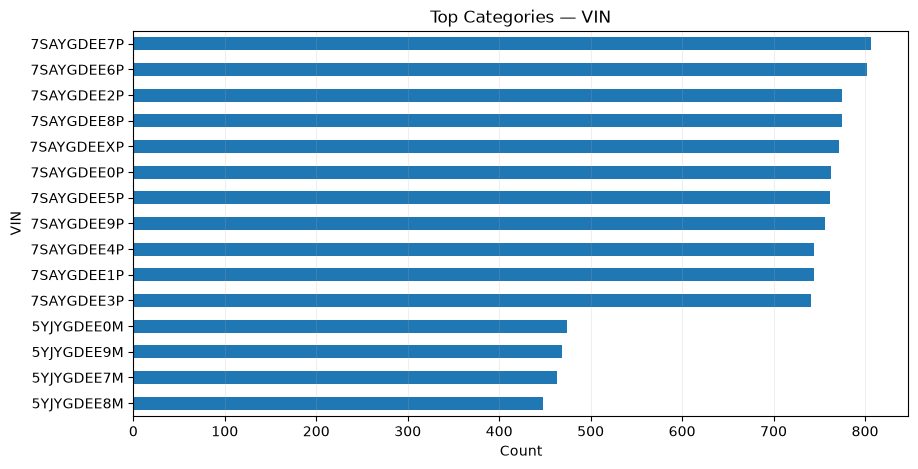

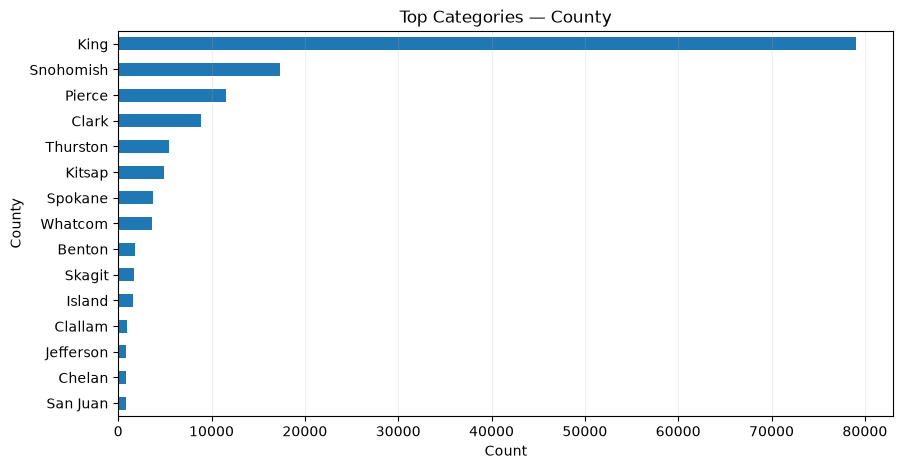

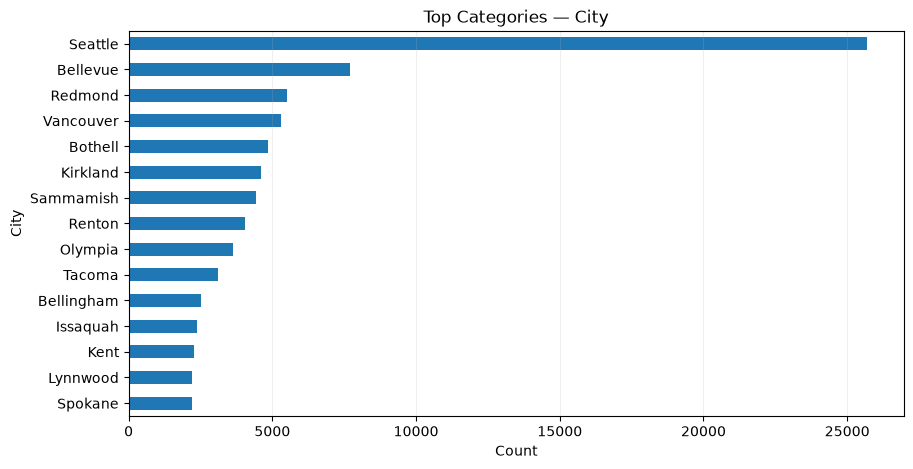

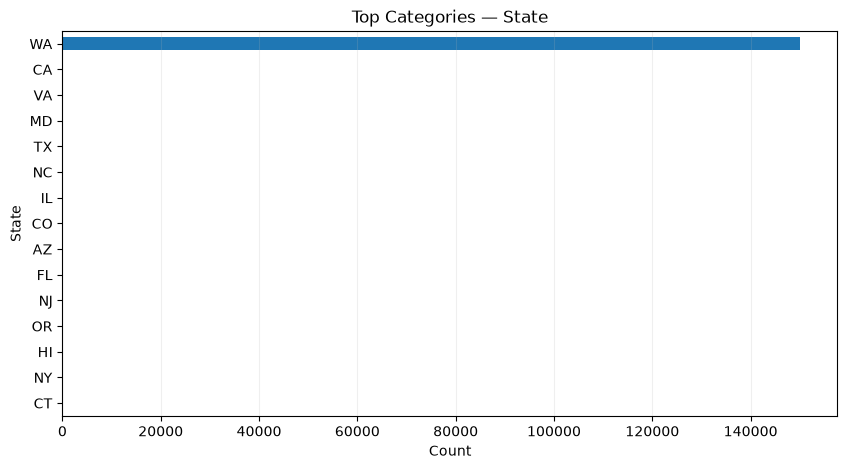

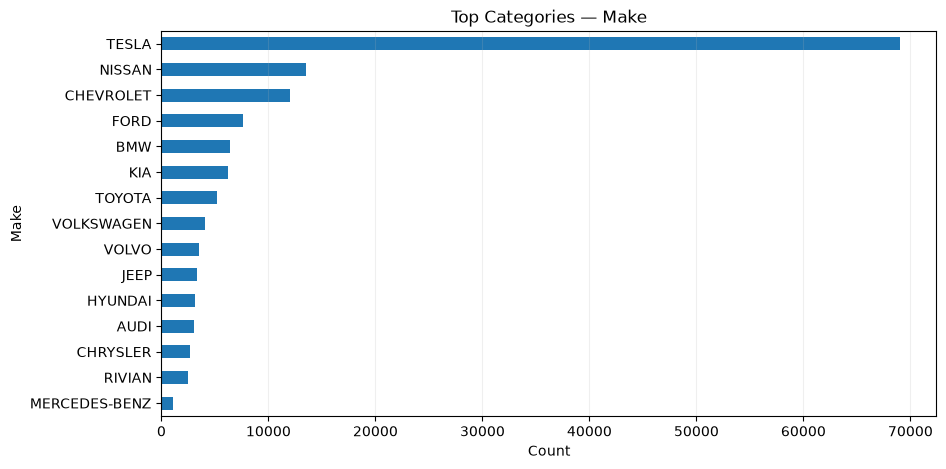

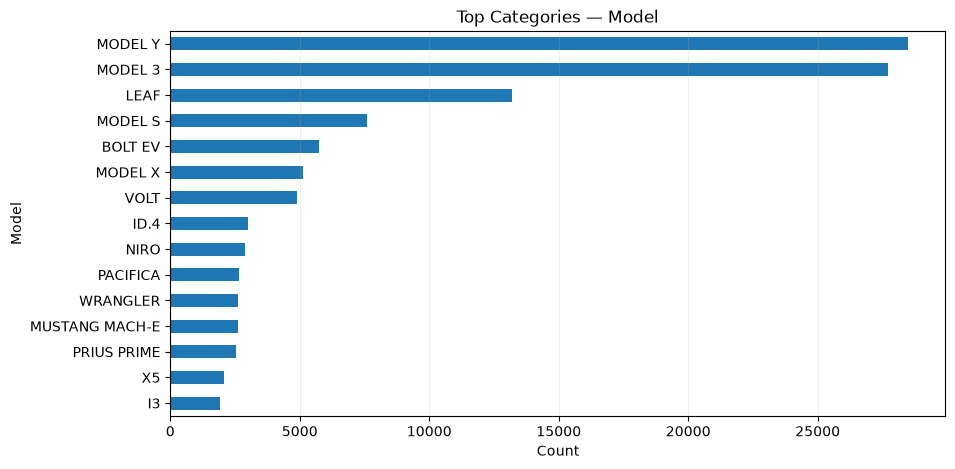

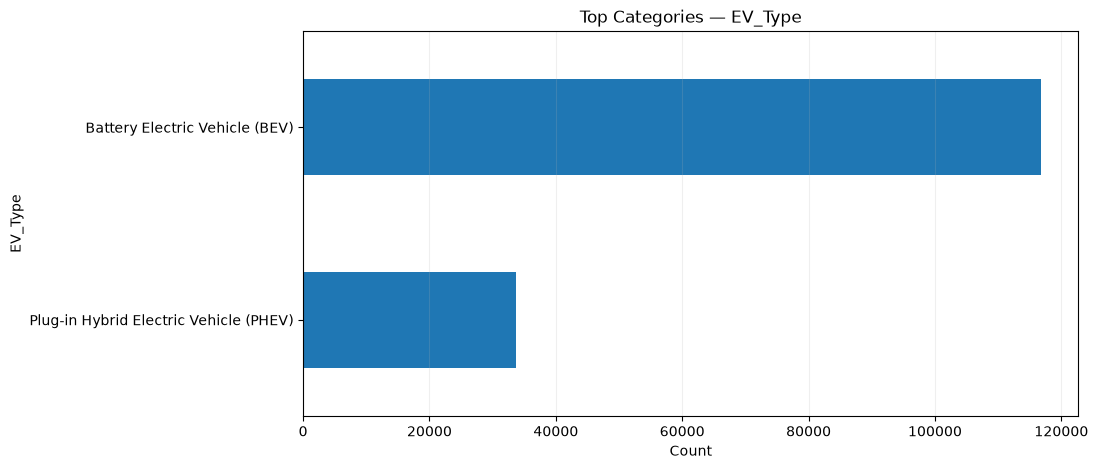

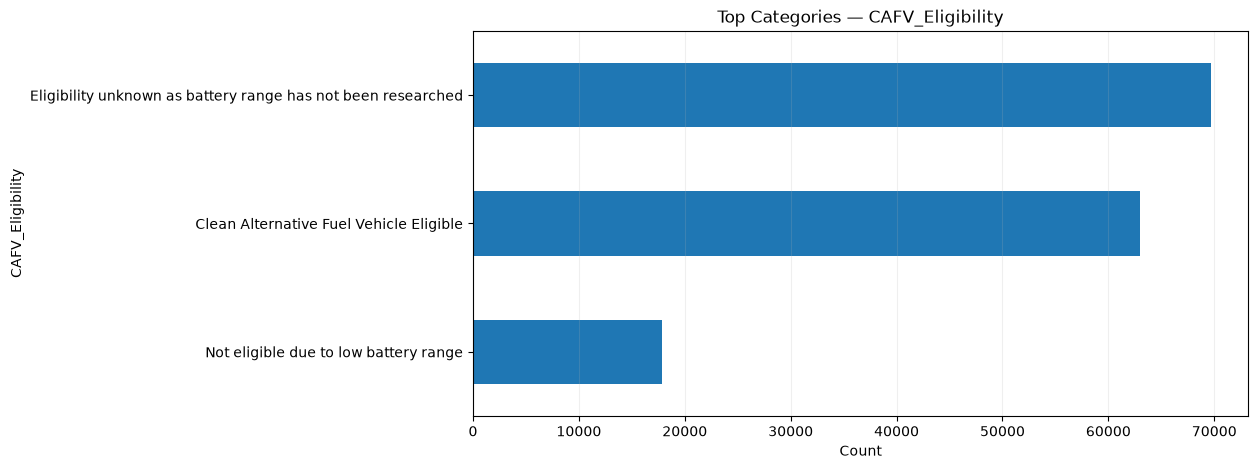

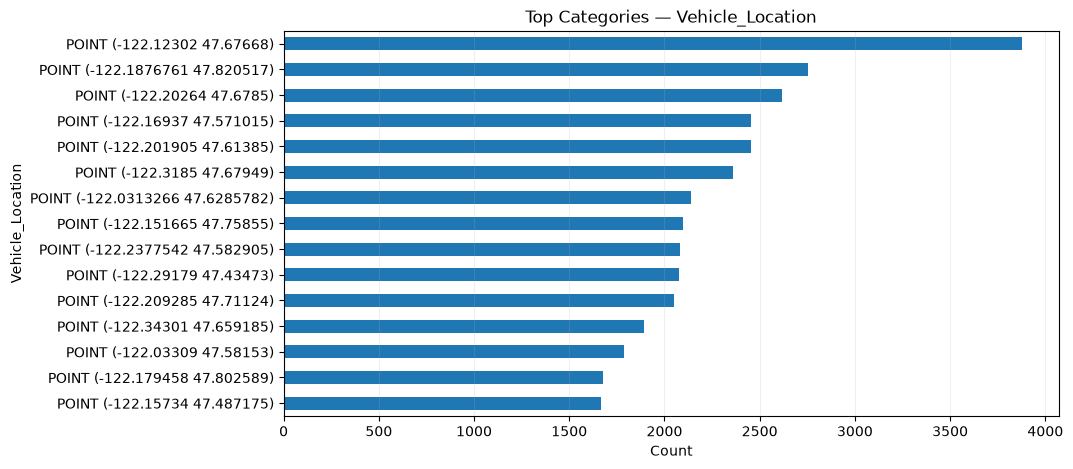

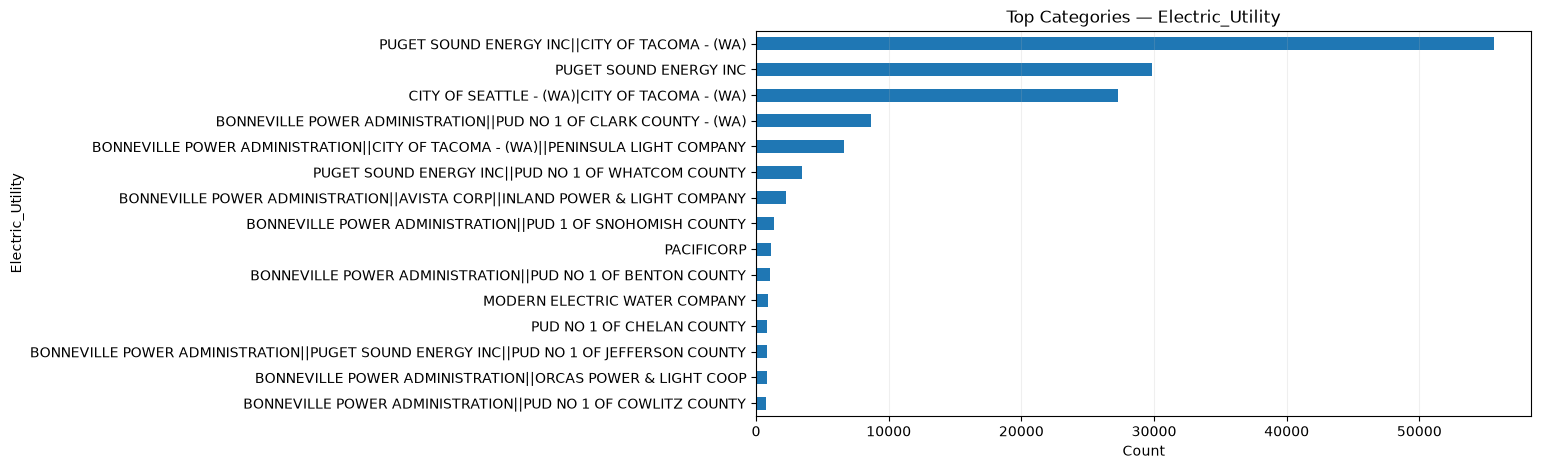

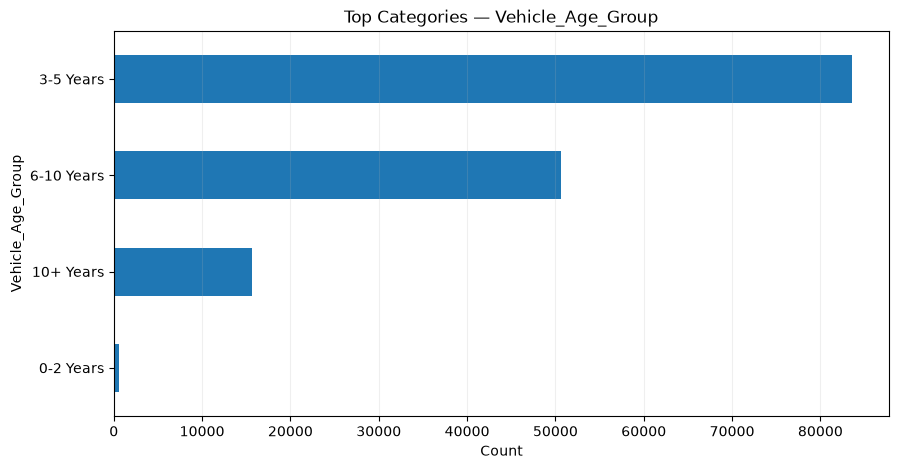

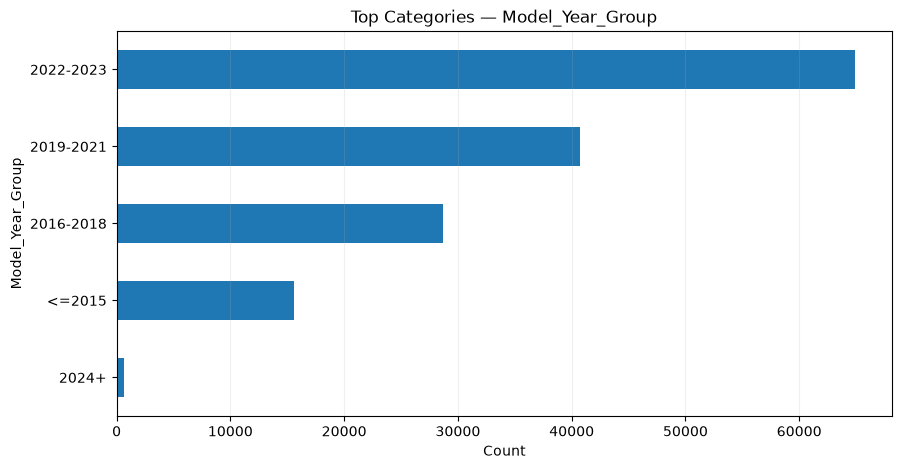

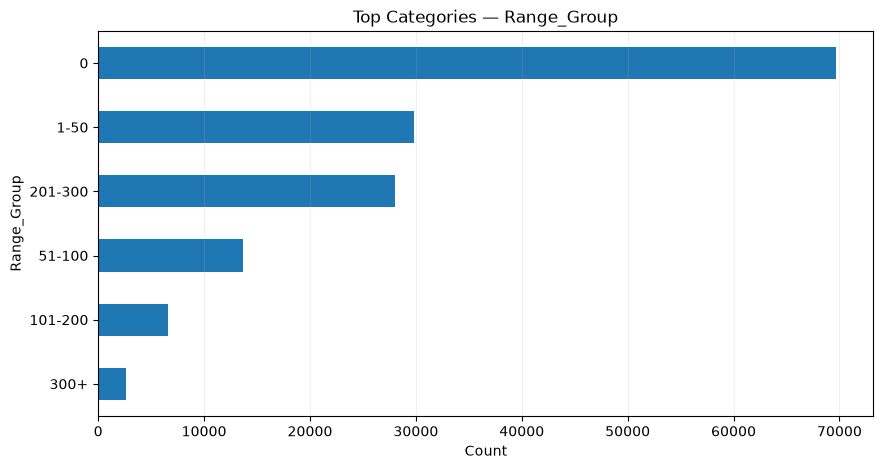

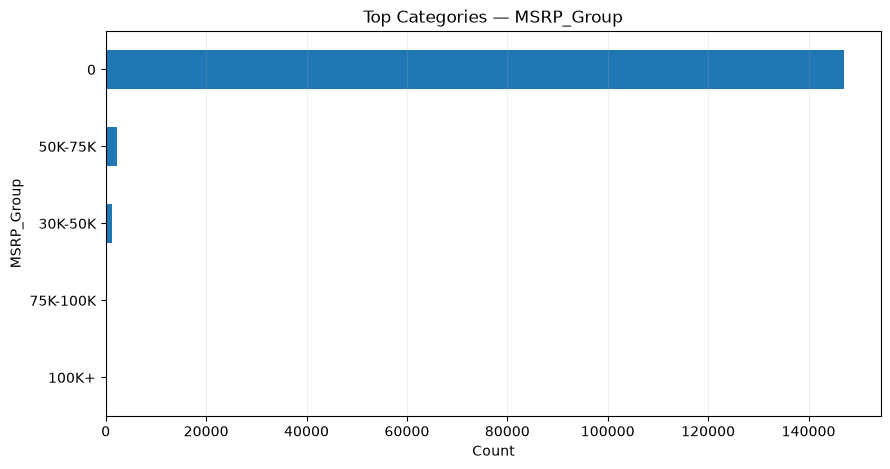

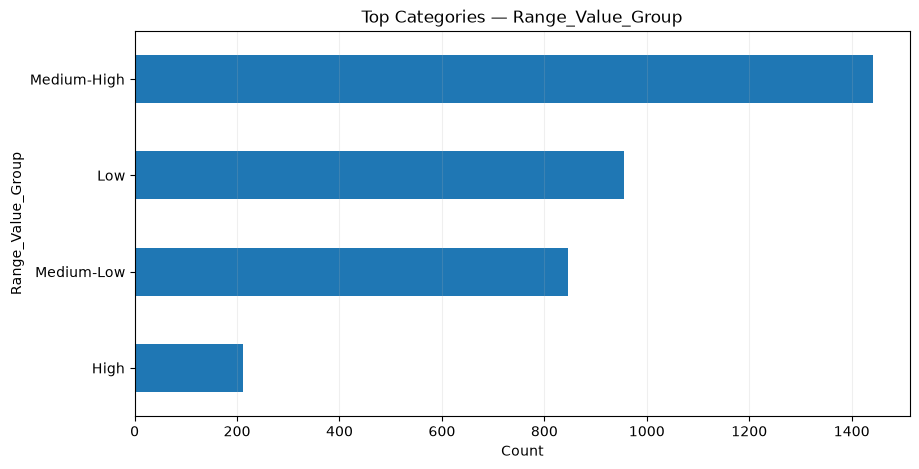

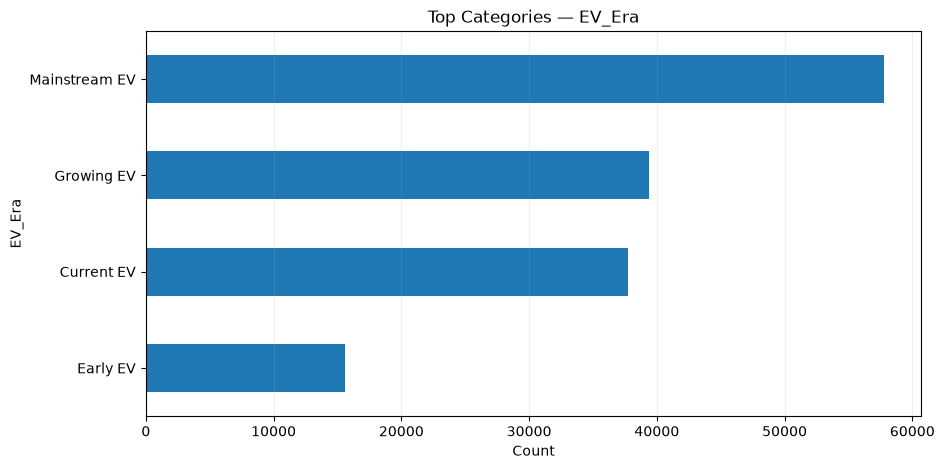

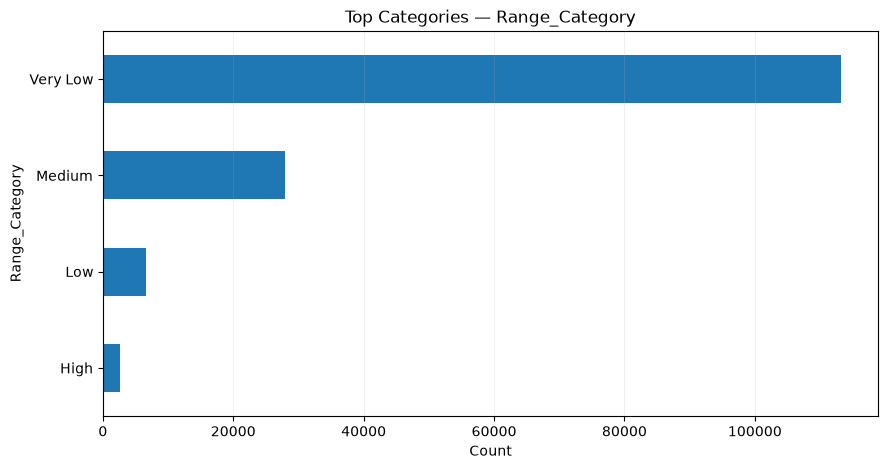

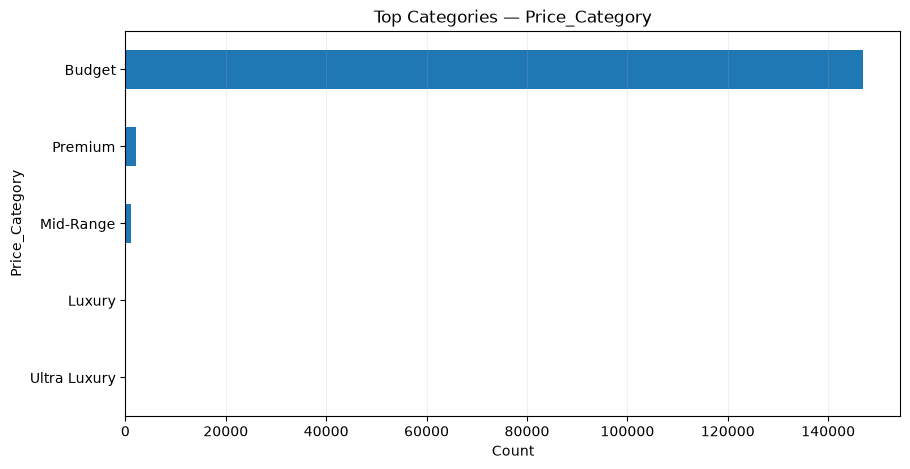

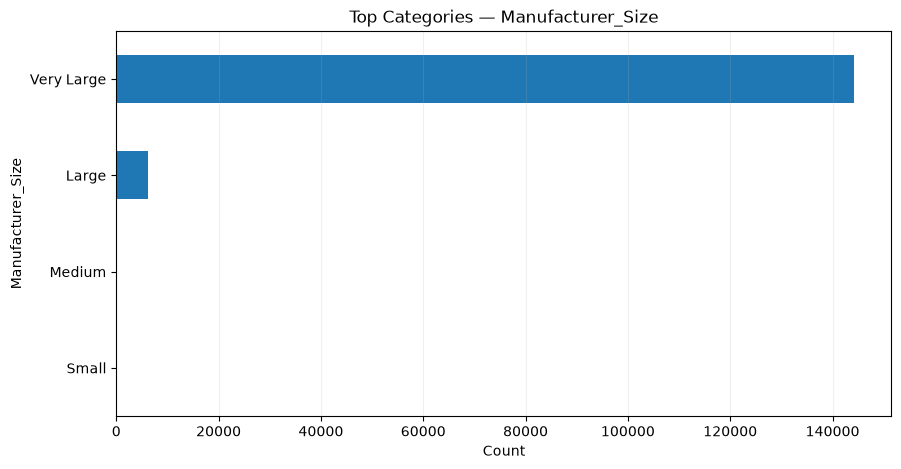

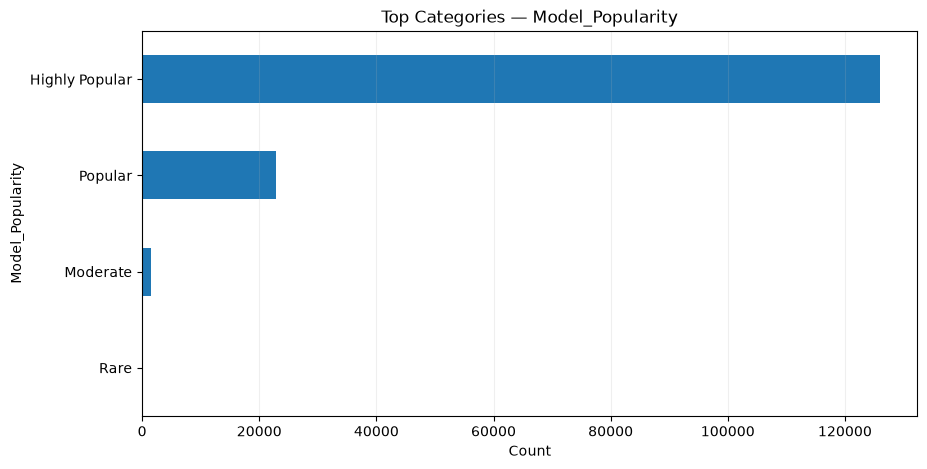

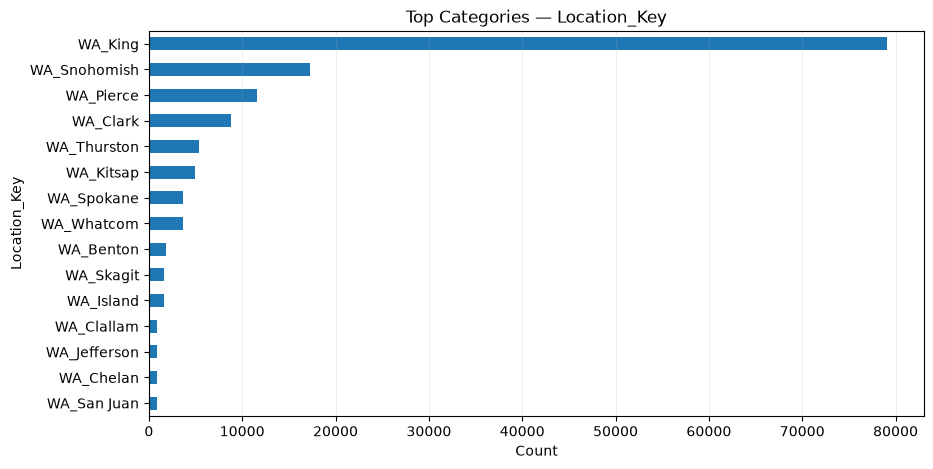

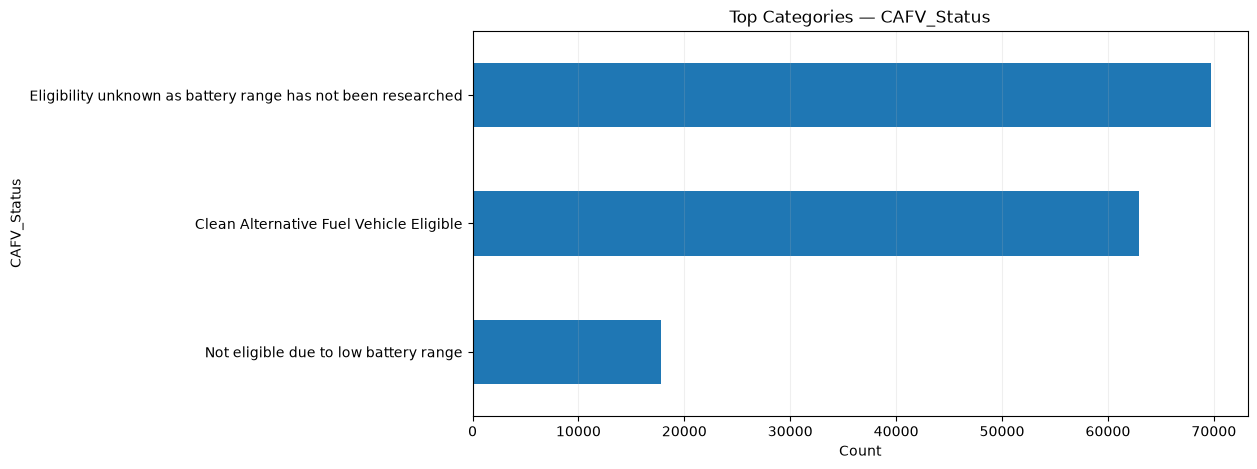

In [13]:
for col in categorical_cols:
    counts = df[col].value_counts().head(15).sort_values()

    plt.figure(figsize=(10, 5))
    counts.plot(kind="barh")
    plt.title(f"Top Categories — {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.grid(axis="x", alpha=0.2)
    plt.show()


# 12. Correlation Analysis

## Pearson correlation

Measures linear association.

\[
r = \frac{Cov(X,Y)}{\sigma_X\sigma_Y}
\]

Range:

\[
-1 \le r \le 1
\]

## Spearman correlation

Measures monotonic association using ranks and is less dependent on normality.


In [14]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

display(pearson_corr.round(3))
display(spearman_corr.round(3))


,Postal_Code,Model_Year,Electric_Range,Base_MSRP,Vehicle_ID,Census_Tract,Legislative_District,Vehicle_Age,Has_Electric_Range,Range_Percentile,...,State_EV_Count,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
Postal_Code,1.000,0.000,-0.002,-0.001,0.006,0.513,-0.059,-0.000,-0.000,-0.001,...,0.763,-0.008,-0.026,-0.000,NaN,NaN,NaN,NaN,0.001,-0.001
Model_Year,0.000,1.000,-0.431,-0.232,0.055,0.008,-0.010,-1.000,-0.691,-0.628,...,0.011,-0.004,0.101,-0.691,NaN,0.010,NaN,NaN,0.622,-0.622
Electric_Range,-0.002,-0.431,1.000,0.104,-0.051,-0.003,0.023,0.431,0.655,0.899,...,-0.003,0.017,-0.008,0.655,NaN,-0.005,NaN,NaN,-0.511,0.511
Base_MSRP,-0.001,-0.232,0.104,1.000,-0.016,-0.001,0.013,0.232,0.132,0.109,...,-0.003,-0.005,0.000,0.132,NaN,-0.015,NaN,NaN,-0.673,0.673
Vehicle_ID,0.006,0.055,-0.051,-0.016,1.000,0.004,-0.008,-0.055,-0.020,-0.036,...,0.007,-0.009,0.022,-0.020,NaN,-0.002,NaN,NaN,0.019,-0.019
Census_Tract,0.513,0.008,-0.003,-0.001,0.004,1.000,-0.011,-0.008,-0.009,-0.006,...,0.871,0.027,0.064,-0.009,NaN,NaN,NaN,NaN,0.007,-0.007
Legislative_District,-0.059,-0.010,0.023,0.013,-0.008,-0.011,1.000,0.010,-0.018,0.003,...,-0.012,0.333,0.267,-0.018,NaN,-0.001,NaN,NaN,0.006,-0.006
Vehicle_Age,-0.000,-1.000,0.431,0.232,-0.055,-0.008,0.010,1.000,0.691,0.628,...,-0.011,0.004,-0.101,0.691,NaN,-0.010,NaN,NaN,-0.622,0.622
Has_Electric_Range,-0.000,-0.691,0.655,0.132,-0.020,-0.009,-0.018,0.691,1.000,0.910,...,-0.011,0.003,-0.084,1.000,NaN,-0.004,NaN,NaN,-0.784,0.784
Range_Percentile,-0.001,-0.628,0.899,0.109,-0.036,-0.006,0.003,0.628,0.910,1.000,...,-0.007,0.011,-0.056,0.910,NaN,-0.005,NaN,NaN,-0.702,0.702


,Postal_Code,Model_Year,Electric_Range,Base_MSRP,Vehicle_ID,Census_Tract,Legislative_District,Vehicle_Age,Has_Electric_Range,Range_Percentile,...,State_EV_Count,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
Postal_Code,1.000,-0.067,0.045,-0.003,-0.011,0.052,-0.338,0.067,0.083,0.045,...,0.082,-0.385,-0.702,0.083,NaN,NaN,NaN,NaN,-0.079,0.079
Model_Year,-0.067,1.000,-0.696,-0.194,0.285,0.006,-0.010,-1.000,-0.727,-0.696,...,0.015,0.034,0.101,-0.727,NaN,0.006,NaN,NaN,0.732,-0.732
Electric_Range,0.045,-0.696,1.000,0.110,-0.150,-0.014,-0.000,0.696,0.910,1.000,...,-0.007,-0.017,-0.058,0.910,NaN,-0.005,NaN,NaN,-0.896,0.896
Base_MSRP,-0.003,-0.194,0.110,1.000,-0.026,0.000,0.011,0.194,0.142,0.110,...,-0.002,-0.006,-0.003,0.142,NaN,-0.009,NaN,NaN,-0.297,0.297
Vehicle_ID,-0.011,0.285,-0.150,-0.026,1.000,0.008,-0.016,-0.285,-0.127,-0.150,...,0.013,0.002,0.036,-0.127,NaN,0.002,NaN,NaN,0.127,-0.127
Census_Tract,0.052,0.006,-0.014,0.000,0.008,1.000,-0.186,-0.006,-0.013,-0.014,...,0.081,-0.371,0.098,-0.013,NaN,NaN,NaN,NaN,0.012,-0.012
Legislative_District,-0.338,-0.010,-0.000,0.011,-0.016,-0.186,1.000,0.010,-0.023,-0.000,...,0.001,0.396,0.257,-0.023,NaN,0.000,NaN,NaN,0.020,-0.020
Vehicle_Age,0.067,-1.000,0.696,0.194,-0.285,-0.006,0.010,1.000,0.727,0.696,...,-0.015,-0.034,-0.101,0.727,NaN,-0.006,NaN,NaN,-0.732,0.732
Has_Electric_Range,0.083,-0.727,0.910,0.142,-0.127,-0.013,-0.023,0.727,1.000,0.910,...,-0.011,-0.037,-0.085,1.000,NaN,-0.004,NaN,NaN,-0.987,0.987
Range_Percentile,0.045,-0.696,1.000,0.110,-0.150,-0.014,-0.000,0.696,0.910,1.000,...,-0.007,-0.017,-0.058,0.910,NaN,-0.005,NaN,NaN,-0.896,0.896


# 13. Correlation Heatmap

A heatmap makes relationships easier to identify visually.

Strong correlation does **not** imply causation.


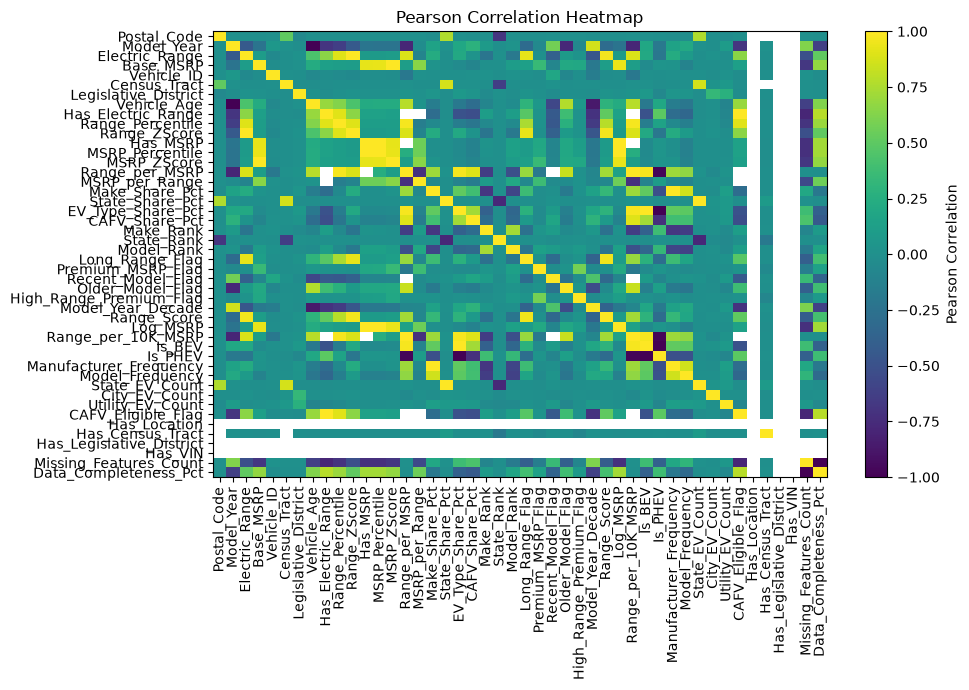

In [15]:
plt.figure(figsize=(10, 7))
plt.imshow(pearson_corr, aspect="auto")
plt.colorbar(label="Pearson Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


# 14. Pairwise Scatter Analysis

Scatter plots help inspect:
- direction
- strength
- non-linearity
- clusters
- influential observations


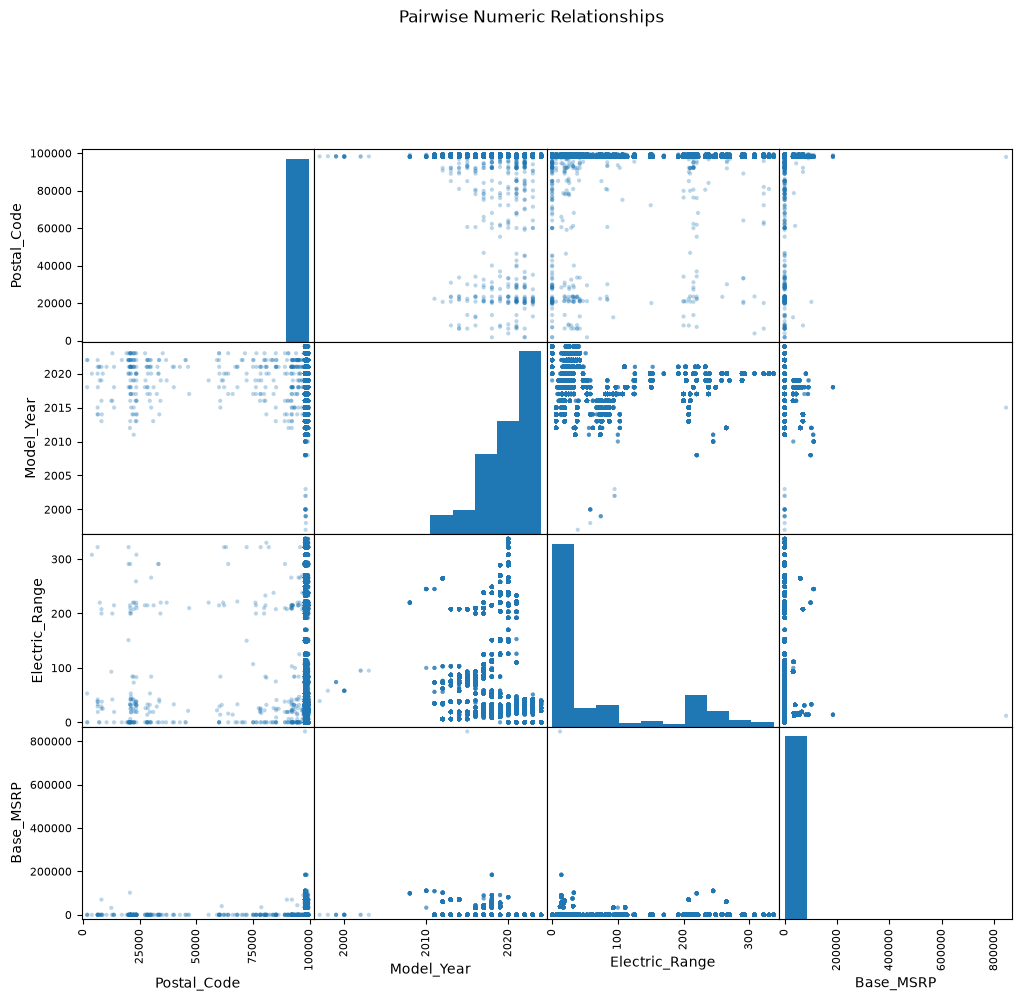

In [16]:
if len(numeric_cols) >= 2:
    base = numeric_cols[:min(4, len(numeric_cols))]
    pd.plotting.scatter_matrix(
        df[base].dropna(),
        figsize=(12, 10),
        diagonal="hist",
        alpha=0.3
    )
    plt.suptitle("Pairwise Numeric Relationships", y=1.02)
    plt.show()


# 15. Inferential Statistics — Introduction

Inferential statistics tests whether observed patterns are likely to be due to sampling variation.

### Hypothesis framework

**H₀:** Null hypothesis — no meaningful difference/association.

**H₁:** Alternative hypothesis — a difference/association exists.

### Significance level

Common choice:

\[
\alpha = 0.05
\]

If:

\[
p < \alpha
\]

we reject H₀.

> A statistically significant result is not automatically a practically important result.


# 16. Confidence Intervals

For a mean with unknown population standard deviation:

\[
CI = \bar{x} \pm t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}
\]

The interval gives a plausible range for the population mean under the model assumptions.


In [17]:
confidence_level = 0.95
alpha = 1 - confidence_level

ci_rows = []

for col in numeric_cols:
    x = df[col].dropna()
    n = len(x)
    mean = x.mean()
    se = stats.sem(x)
    margin = stats.t.ppf(1 - alpha/2, n-1) * se

    ci_rows.append({
        "Column": col,
        "N": n,
        "Mean": mean,
        "SE": se,
        "CI_Lower": mean - margin,
        "CI_Upper": mean + margin
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df.round(3))


,Column,N,Mean,SE,CI_Lower,CI_Upper
0,Postal_Code,150479,9.816834e+04,6.377,9.815585e+04,9.818084e+04
1,Model_Year,150482,2.020005e+03,0.008,2.019990e+03,2.020021e+03
2,Electric_Range,150482,6.787800e+01,0.248,6.739200e+01,6.836400e+01
3,Base_MSRP,150482,1.312645e+03,23.797,1.266003e+03,1.359286e+03
4,Vehicle_ID,150482,2.111122e+08,211290.626,2.106981e+08,2.115264e+08
5,Census_Tract,150479,5.297195e+10,4224730.025,5.296367e+10,5.298024e+10
6,Legislative_District,150482,2.935200e+01,0.038,2.927700e+01,2.942700e+01
7,Vehicle_Age,150482,5.995000e+00,0.008,5.979000e+00,6.010000e+00
8,Has_Electric_Range,150482,5.370000e-01,0.001,5.340000e-01,5.390000e-01
9,Range_Percentile,150482,5.000000e+01,0.071,4.986200e+01,5.013900e+01


# 17. One-Sample t-Test

Tests whether a sample mean differs from a hypothesized value.

\[
t = \frac{\bar{x}-\mu_0}{s/\sqrt{n}}
\]

The reference value is selected from the data/business context rather than invented as a business claim.


In [18]:
# Example: test whether a numeric variable differs from its sample median.
# This is a demonstration of the method; replace reference_value with a
# business-defined benchmark when one exists.

if numeric_cols:
    col = numeric_cols[0]
    x = df[col].dropna()
    reference_value = x.median()

    t_stat, p_value = ttest_1samp(x, reference_value)

    print("Column:", col)
    print("Reference value:", reference_value)
    print("t-statistic:", t_stat)
    print("p-value:", p_value)


Column: Postal_Code
Reference value: 98122.0
t-statistic: 7.267772068523655
p-value: 3.6722621332666087e-13


# 18. Two-Group Comparison — Welch's t-Test

Welch's t-test compares two independent group means without assuming equal variance.

Use when a categorical column contains at least two groups and a numeric outcome is available.

Effect size can be summarized with Cohen's d.


In [19]:
def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_sd if pooled_sd != 0 else np.nan

# Automatically find a useful two-group categorical variable
two_group_cols = [
    c for c in categorical_cols
    if 2 <= df[c].nunique(dropna=True) <= 10
]

if numeric_cols and two_group_cols:
    group_col = two_group_cols[0]
    target_col = numeric_cols[0]

    groups = df[[group_col, target_col]].dropna()
    levels = groups[group_col].value_counts().head(2).index.tolist()

    if len(levels) == 2:
        x = groups.loc[groups[group_col] == levels[0], target_col]
        y = groups.loc[groups[group_col] == levels[1], target_col]

        result = ttest_ind(x, y, equal_var=False)

        print("Grouping column:", group_col)
        print("Numeric variable:", target_col)
        print("Groups:", levels)
        print("Welch t-statistic:", result.statistic)
        print("p-value:", result.pvalue)
        print("Cohen's d:", cohens_d(x, y))


Grouping column: EV_Type
Numeric variable: Postal_Code
Groups: ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']
Welch t-statistic: 0.23850120804689964
p-value: 0.811493516914356
Cohen's d: 0.0018173215033055606


# 19. Group Mean Visualization

Before interpreting a group comparison, visualize the distribution and group-level central tendency.


,count,mean,median,std
EV_Type,,,,
Battery Electric Vehicle (BEV),116804,98169.350,98117.0,2199.030
Plug-in Hybrid Electric Vehicle (PHEV),33675,98164.855,98188.0,3251.042


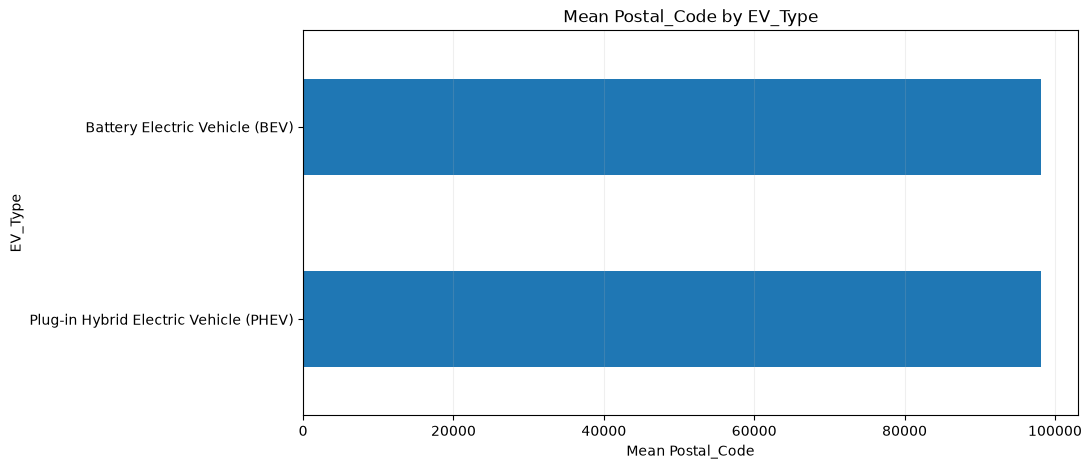

In [20]:
if numeric_cols and two_group_cols:
    group_col = two_group_cols[0]
    target_col = numeric_cols[0]

    summary = (
        df.groupby(group_col, dropna=False)[target_col]
        .agg(["count", "mean", "median", "std"])
        .sort_values("count", ascending=False)
        .head(10)
    )

    display(summary.round(3))

    summary["mean"].sort_values().plot(kind="barh", figsize=(10, 5))
    plt.title(f"Mean {target_col} by {group_col}")
    plt.xlabel(f"Mean {target_col}")
    plt.ylabel(group_col)
    plt.grid(axis="x", alpha=0.2)
    plt.show()


# 20. ANOVA

One-way ANOVA tests whether three or more independent groups have equal means.

\[
F = \frac{Between\ Group\ Variance}{Within\ Group\ Variance}
\]

H₀:

\[
\mu_1=\mu_2=...=\mu_k
\]

If ANOVA is significant, post-hoc analysis is required to identify which groups differ.


In [21]:
# Run ANOVA when there are at least 3 groups with sufficient observations
if numeric_cols:
    candidate_groups = [
        c for c in categorical_cols
        if 3 <= df[c].nunique(dropna=True) <= 15
    ]

    if candidate_groups:
        group_col = candidate_groups[0]
        target_col = numeric_cols[0]

        temp = df[[group_col, target_col]].dropna()
        grouped = [
            g[target_col].values
            for _, g in temp.groupby(group_col)
            if len(g) >= 2
        ]

        if len(grouped) >= 3:
            result = f_oneway(*grouped)
            print("Grouping:", group_col)
            print("Target:", target_col)
            print("F-statistic:", result.statistic)
            print("p-value:", result.pvalue)


Grouping: CAFV_Eligibility
Target: Postal_Code
F-statistic: 0.3934505618667054
p-value: 0.6747253680068384


# 21. Chi-Square Test of Independence

Used for two categorical variables.

Observed frequencies are compared with expected frequencies.

\[
\chi^2 = \sum\frac{(O-E)^2}{E}
\]

H₀: variables are independent.

H₁: variables are associated.

Effect size: **Cramér's V**.


In [22]:
from scipy.stats import chi2_contingency

for cat1 in categorical_cols:
    for cat2 in categorical_cols:

        if cat1 == cat2:
            continue

        # Contingency table
        table = pd.crosstab(df[cat1], df[cat2])

        # Keep manageable dimensions
        table = table.iloc[:10, :10]

        # Remove rows and columns having zero total frequency
        table = table.loc[
            table.sum(axis=1) > 0,
            table.sum(axis=0) > 0
        ]

        # Need at least 2 rows and 2 columns
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue

        try:
            chi2, p, dof, expected = chi2_contingency(table)

            print("=" * 60)
            print(f"Variables: {cat1} × {cat2}")
            print(f"Chi-square: {chi2:.4f}")
            print(f"P-value: {p:.6f}")
            print(f"Degrees of Freedom: {dof}")

        except ValueError as e:
            print(f"Skipped: {cat1} × {cat2}")
            print("Reason:", e)

Variables: VIN × Electric_Utility
Chi-square: 10.0000
P-value: 0.265026
Degrees of Freedom: 8
Variables: VIN × Range_Value_Group
Chi-square: 17.0000
P-value: 0.048716
Degrees of Freedom: 9
Variables: County × City
Chi-square: 0.4444
P-value: 0.504985
Degrees of Freedom: 1
Variables: County × State
Chi-square: 16.0000
P-value: 0.013754
Degrees of Freedom: 6
Variables: County × Make
Chi-square: 18.4821
P-value: 0.296429
Degrees of Freedom: 16
Variables: County × Model
Chi-square: 0.0000
P-value: 1.000000
Degrees of Freedom: 1
Variables: County × EV_Type
Chi-square: 5.3453
P-value: 0.803232
Degrees of Freedom: 9
Variables: County × CAFV_Eligibility
Chi-square: 15.3652
P-value: 0.636754
Degrees of Freedom: 18
Variables: County × Vehicle_Location
Chi-square: 0.1875
P-value: 0.665006
Degrees of Freedom: 1
Variables: County × Electric_Utility
Chi-square: 101.0000
P-value: 0.000000
Degrees of Freedom: 2
Variables: County × Vehicle_Age_Group
Chi-square: 14.3207
P-value: 0.977923
Degrees of Free

In [23]:
from scipy.stats import chi2_contingency

def chi_square_test(df, cat1, cat2, top_n=10):

    # Select top categories
    top_cat1 = df[cat1].value_counts().head(top_n).index
    top_cat2 = df[cat2].value_counts().head(top_n).index

    temp = df[
        df[cat1].isin(top_cat1) &
        df[cat2].isin(top_cat2)
    ]

    # Build contingency table
    table = pd.crosstab(
        temp[cat1],
        temp[cat2]
    )

    # Remove zero-frequency margins
    table = table.loc[
        table.sum(axis=1) > 0,
        table.sum(axis=0) > 0
    ]

    if table.shape[0] < 2 or table.shape[1] < 2:
        return None

    chi2, p, dof, expected = chi2_contingency(table)

    return {
        "variable_1": cat1,
        "variable_2": cat2,
        "chi_square": chi2,
        "p_value": p,
        "degrees_of_freedom": dof,
        "table": table,
        "expected": expected
    }

In [24]:
result = chi_square_test(
    df,
    "Make",
    "EV_Type"
)

if result:

    print("Variable 1:", result["variable_1"])
    print("Variable 2:", result["variable_2"])
    print("Chi-square:", round(result["chi_square"], 4))
    print("P-value:", round(result["p_value"], 6))
    print("Degrees of Freedom:", result["degrees_of_freedom"])

    display(result["table"])

Variable 1: Make
Variable 2: EV_Type
Chi-square: 77820.402
P-value: 0.0
Degrees of Freedom: 9


EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Make,,
BMW,1796,4643
CHEVROLET,7136,4890
FORD,3908,3706
JEEP,0,3292
KIA,4148,2050
NISSAN,13497,0
TESLA,68983,0
TOYOTA,189,5034
VOLKSWAGEN,4074,0


# 22. Chi-Square Visualization

A contingency-table heatmap helps reveal where category combinations are concentrated.


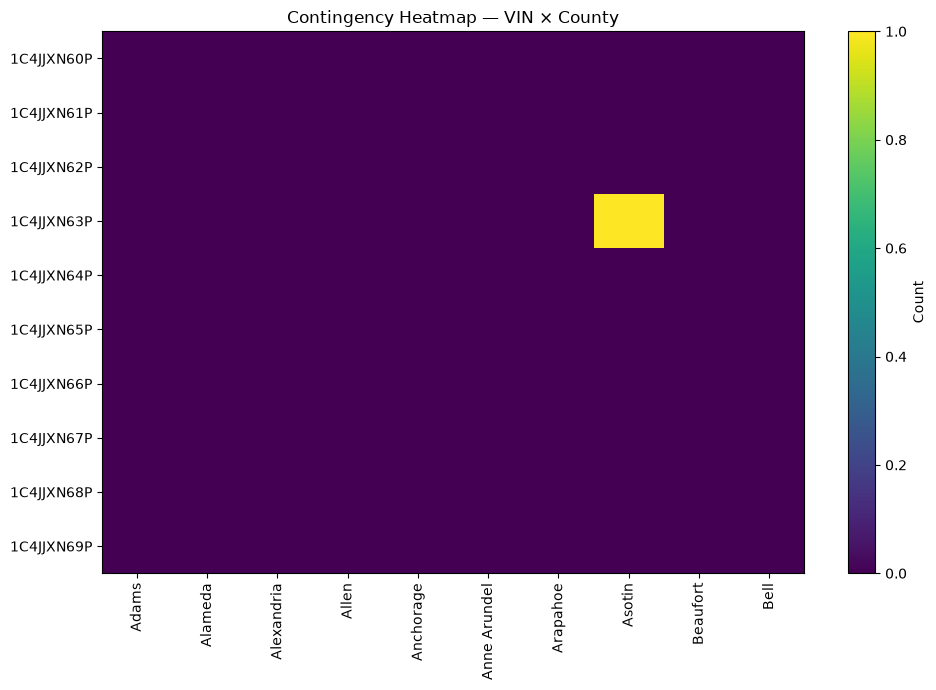

In [25]:
if len(categorical_cols) >= 2:
    cat1, cat2 = categorical_cols[:2]
    table = pd.crosstab(df[cat1], df[cat2]).iloc[:10, :10]

    plt.figure(figsize=(10, 7))
    plt.imshow(table.values, aspect="auto")
    plt.colorbar(label="Count")
    plt.xticks(range(len(table.columns)), table.columns, rotation=90)
    plt.yticks(range(len(table.index)), table.index)
    plt.title(f"Contingency Heatmap — {cat1} × {cat2}")
    plt.tight_layout()
    plt.show()


# 23. Pearson Significance Tests

Correlation magnitude alone is not enough. We can test:

\[
H_0: \rho=0
\]

using Pearson's correlation test.


In [26]:
pearson_results = []

for i, c1 in enumerate(numeric_cols):
    for c2 in numeric_cols[i+1:]:
        pair = df[[c1, c2]].dropna()
        if len(pair) >= 3 and pair[c1].nunique() > 1 and pair[c2].nunique() > 1:
            r, p = pearsonr(pair[c1], pair[c2])
            pearson_results.append({
                "Variable_1": c1,
                "Variable_2": c2,
                "Pearson_r": r,
                "p_value": p,
                "Significant_0.05": p < 0.05
            })

pearson_results_df = pd.DataFrame(pearson_results)
display(pearson_results_df.sort_values("p_value").round(5))


,Variable_1,Variable_2,Pearson_r,p_value,Significant_0.05
16,Postal_Code,State_Share_Pct,0.76309,0.00000,True
73,Model_Year,Manufacturer_Frequency,0.15593,0.00000,True
72,Model_Year,Is_PHEV,-0.19026,0.00000,True
71,Model_Year,Is_BEV,0.19026,0.00000,True
70,Model_Year,Range_per_10K_MSRP,-0.78742,0.00000,True
...,...,...,...,...,...
14,Postal_Code,MSRP_per_Range,0.00016,0.96387,False
252,Legislative_District,Premium_MSRP_Flag,0.00011,0.96499,False
879,City_EV_Count,Missing_Features_Count,-0.00008,0.97451,False
880,City_EV_Count,Data_Completeness_Pct,0.00008,0.97451,False


# 24. Spearman Rank Correlation

Spearman's rho tests monotonic association using ranks.

Useful when:
- variables are not normally distributed
- relationships are monotonic but not linear
- outliers make Pearson less robust


In [27]:
spearman_results = []

for i, c1 in enumerate(numeric_cols):
    for c2 in numeric_cols[i+1:]:
        pair = df[[c1, c2]].dropna()
        if len(pair) >= 3 and pair[c1].nunique() > 1 and pair[c2].nunique() > 1:
            rho, p = spearmanr(pair[c1], pair[c2])
            spearman_results.append({
                "Variable_1": c1,
                "Variable_2": c2,
                "Spearman_rho": rho,
                "p_value": p,
                "Significant_0.05": p < 0.05
            })

spearman_results_df = pd.DataFrame(spearman_results)
display(spearman_results_df.sort_values("p_value").round(5))


,Variable_1,Variable_2,Spearman_rho,p_value,Significant_0.05
57,Model_Year,EV_Type_Share_Pct,0.17959,0.00000,True
36,Postal_Code,City_EV_Count,-0.38512,0.00000,True
34,Postal_Code,Model_Frequency,-0.11607,0.00000,True
49,Model_Year,Range_ZScore,-0.69644,0.00000,True
50,Model_Year,Has_MSRP,-0.19379,0.00000,True
...,...,...,...,...,...
85,Electric_Range,Legislative_District,-0.00008,0.97527,False
238,Legislative_District,Range_ZScore,-0.00008,0.97527,False
237,Legislative_District,Range_Percentile,-0.00008,0.97527,False
268,Legislative_District,Has_Census_Tract,0.00008,0.97543,False


# 25. Normality Assessment

Normality matters for some parametric methods.

### Shapiro-Wilk

\[
H_0: Data\ are\ normally\ distributed
\]

For very large datasets, Shapiro-Wilk can become extremely sensitive. Therefore, combine the test with histograms, Q-Q plots and domain reasoning.


In [28]:
normality_rows = []

for col in numeric_cols:
    x = df[col].dropna()

    # Shapiro is commonly limited to a manageable sample here
    sample = x.sample(min(len(x), 5000), random_state=42) if len(x) > 5000 else x

    if len(sample) >= 3:
        stat, p = shapiro(sample)
        normality_rows.append({
            "Column": col,
            "N_tested": len(sample),
            "W": stat,
            "p_value": p,
            "Reject_normality_0.05": p < 0.05
        })

normality_df = pd.DataFrame(normality_rows)
display(normality_df.round(5))


,Column,N_tested,W,p_value,Reject_normality_0.05
0,Postal_Code,5000,0.05155,0.0,True
1,Model_Year,5000,0.87731,0.0,True
2,Electric_Range,5000,0.72412,0.0,True
3,Base_MSRP,5000,0.12540,0.0,True
4,Vehicle_ID,5000,0.87726,0.0,True
5,Census_Tract,5000,0.02195,0.0,True
6,Legislative_District,5000,0.91341,0.0,True
7,Vehicle_Age,5000,0.87731,0.0,True
8,Has_Electric_Range,5000,0.63403,0.0,True
9,Range_Percentile,5000,0.81899,0.0,True


# 26. Q-Q Plots

A Q-Q plot compares observed quantiles against theoretical normal quantiles.

Points close to the diagonal indicate approximate normality.


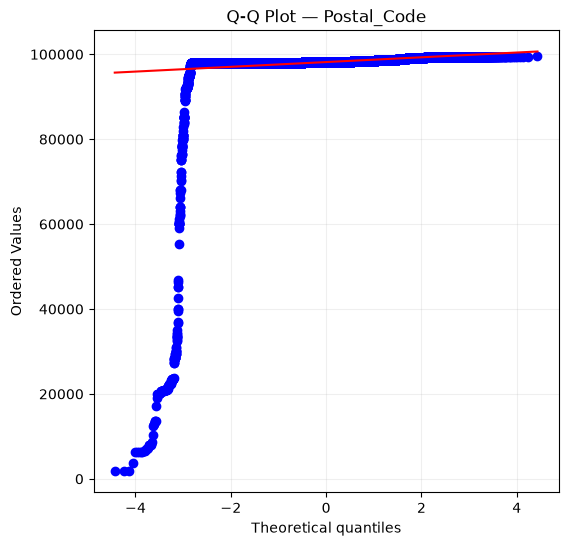

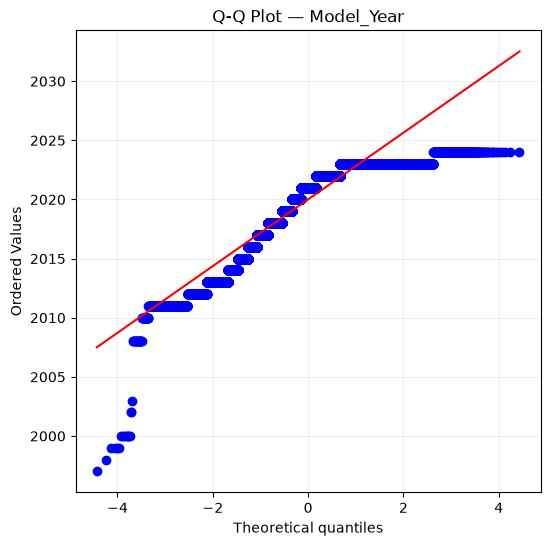

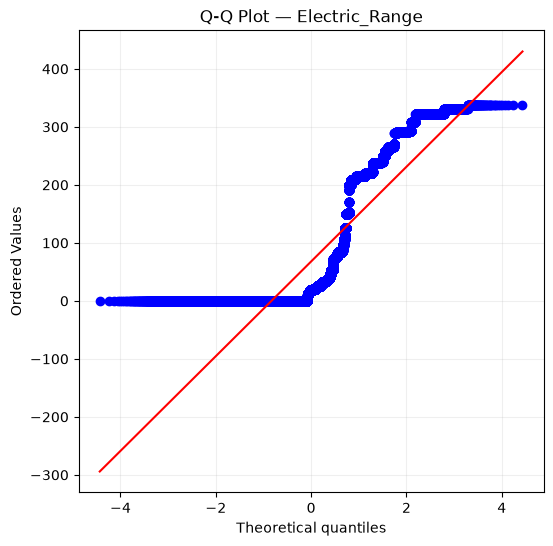

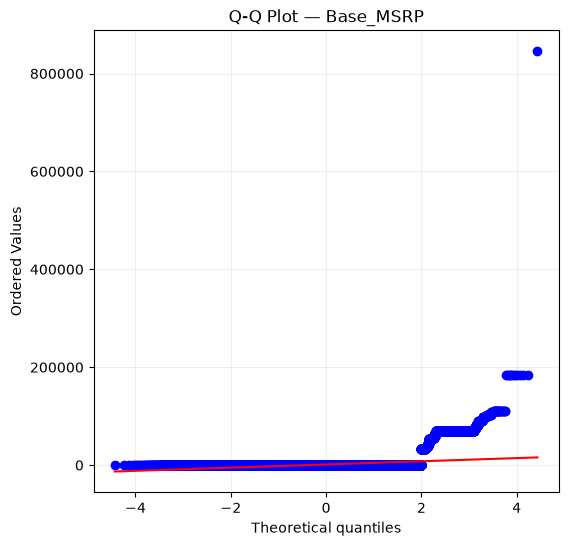

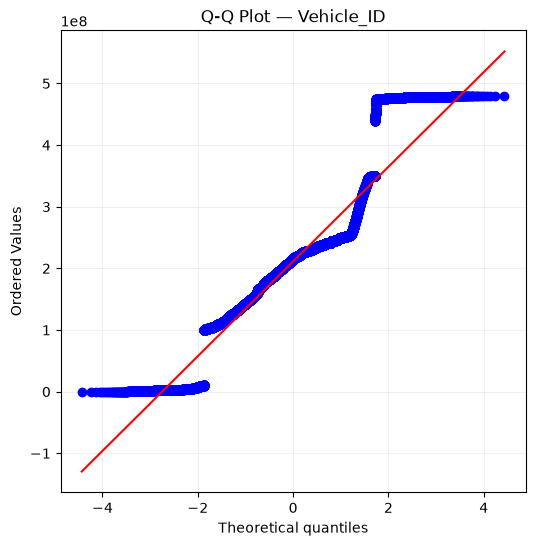

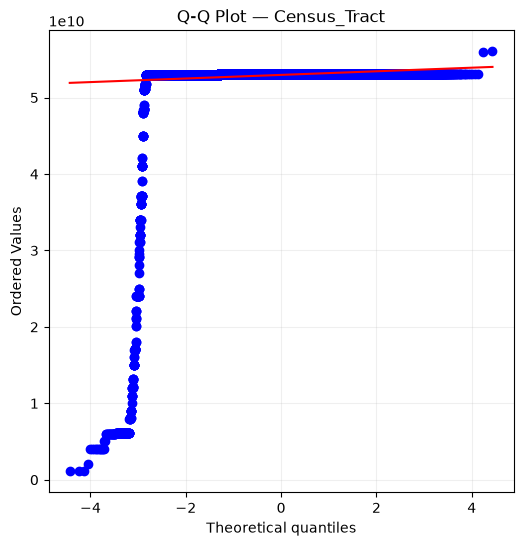

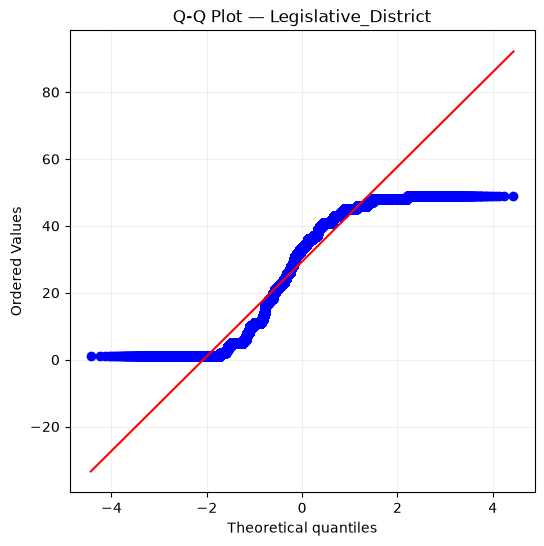

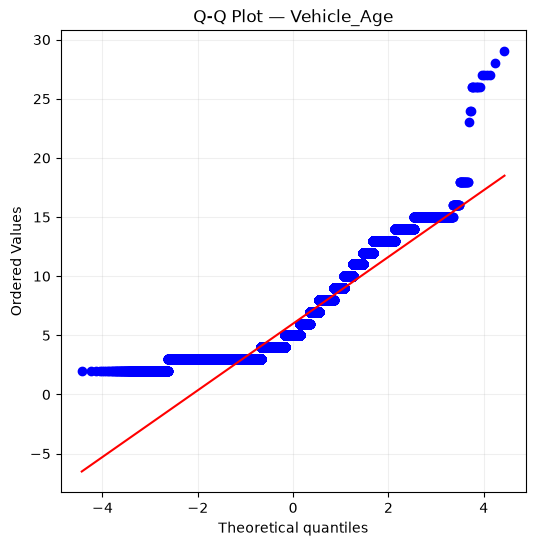

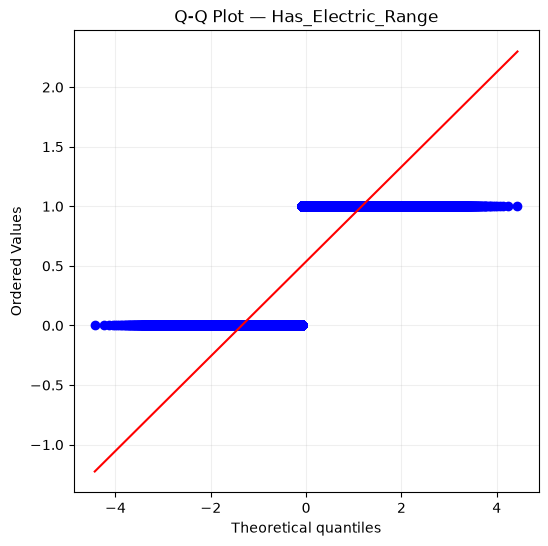

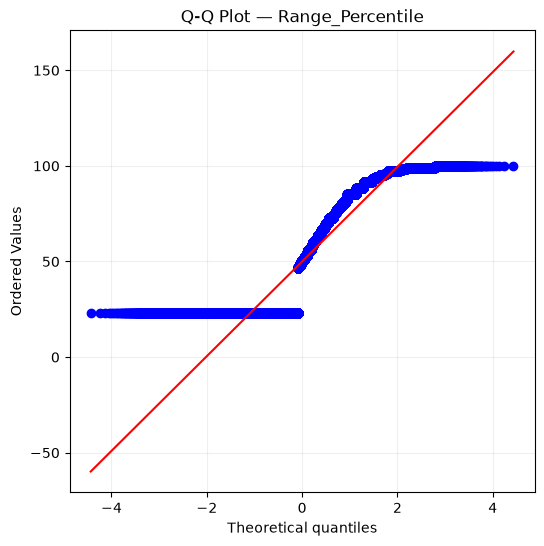

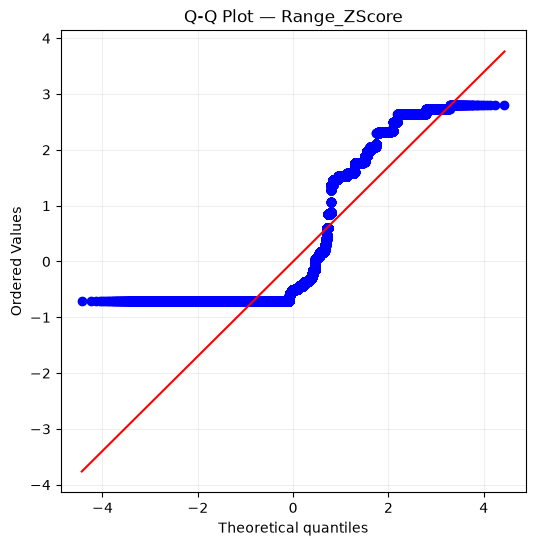

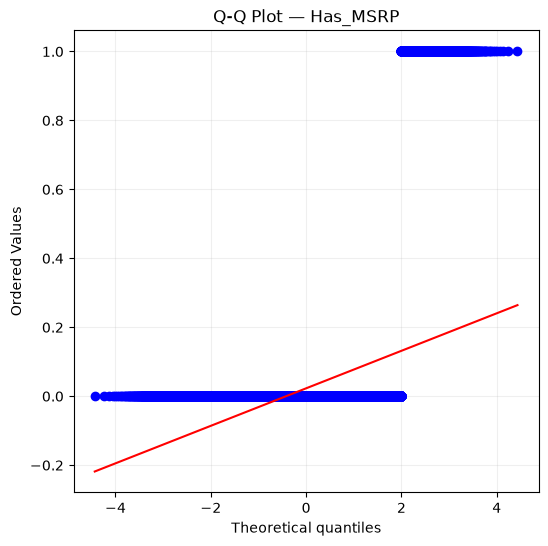

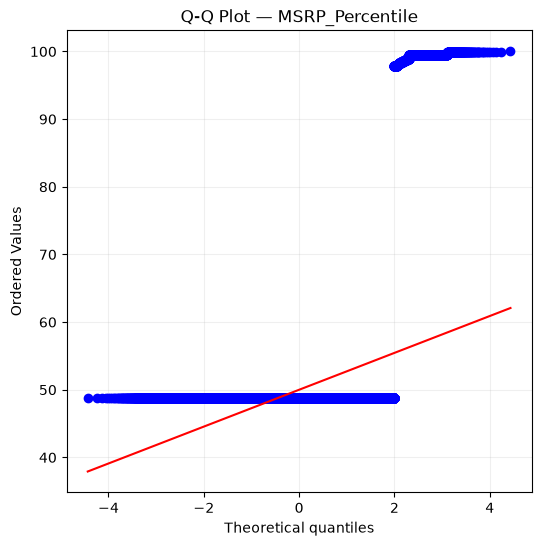

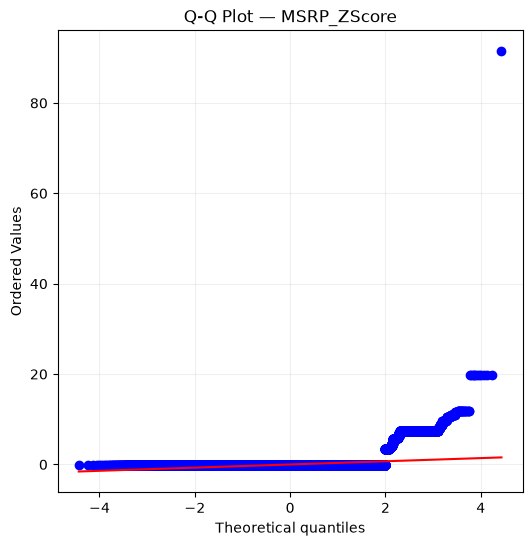

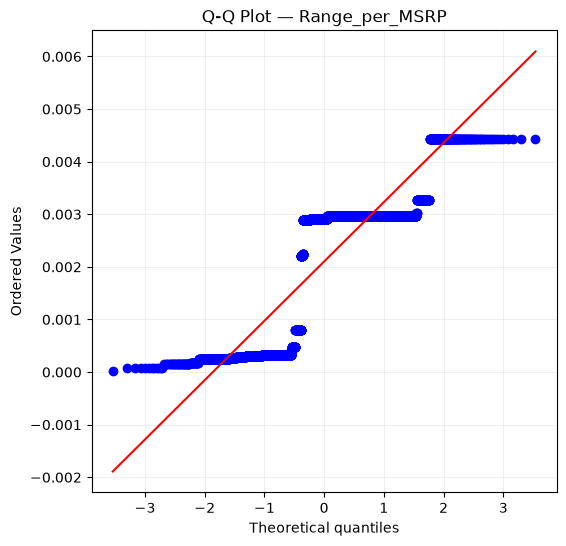

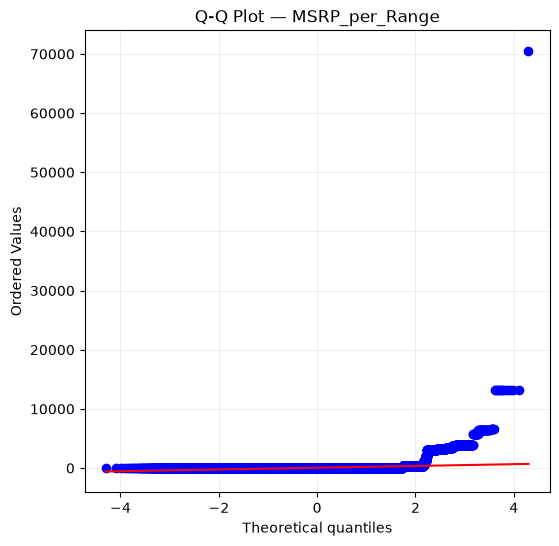

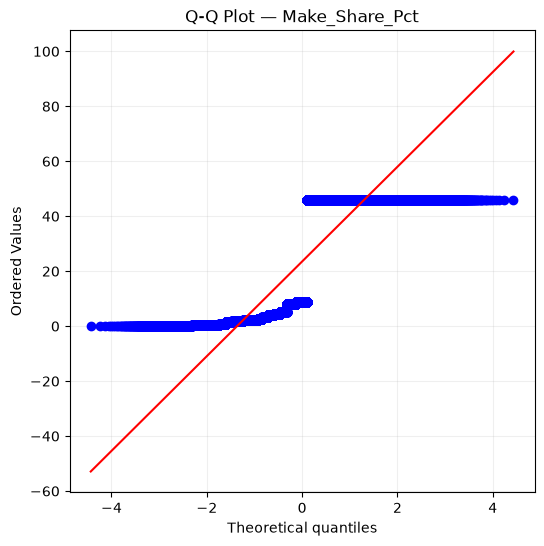

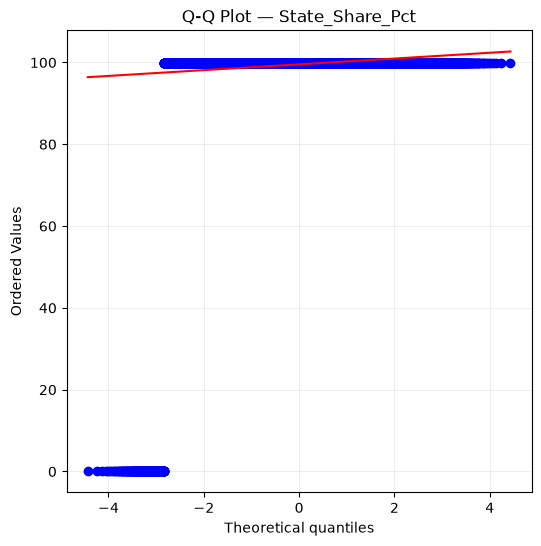

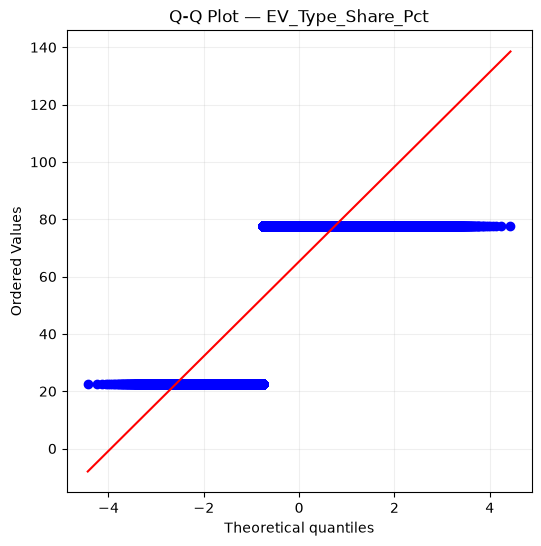

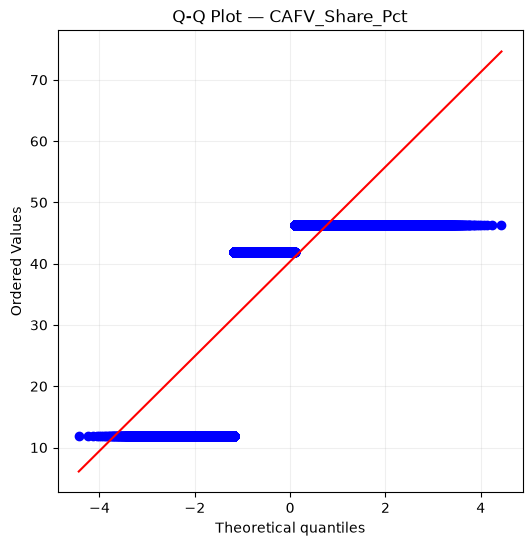

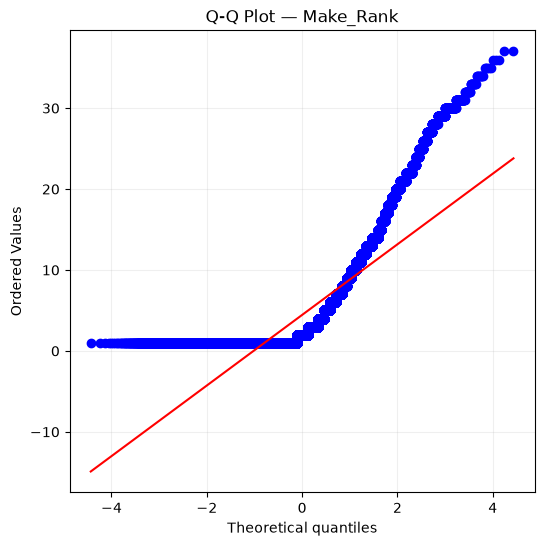

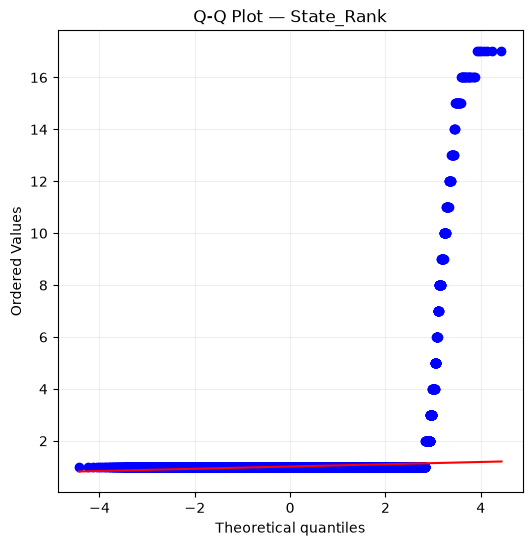

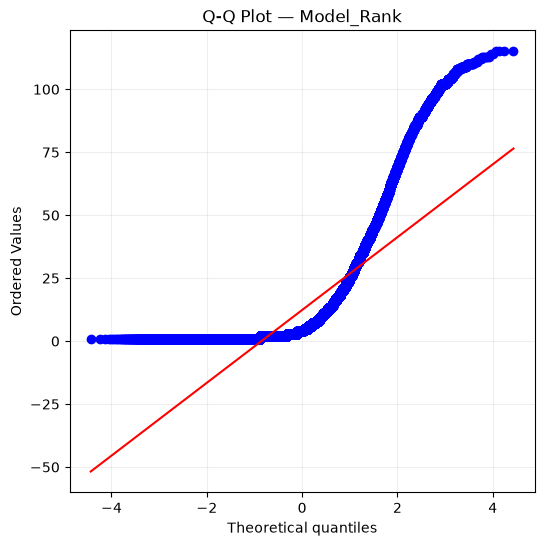

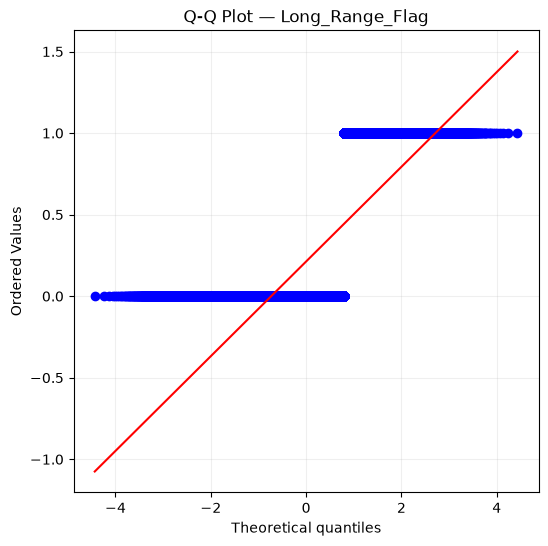

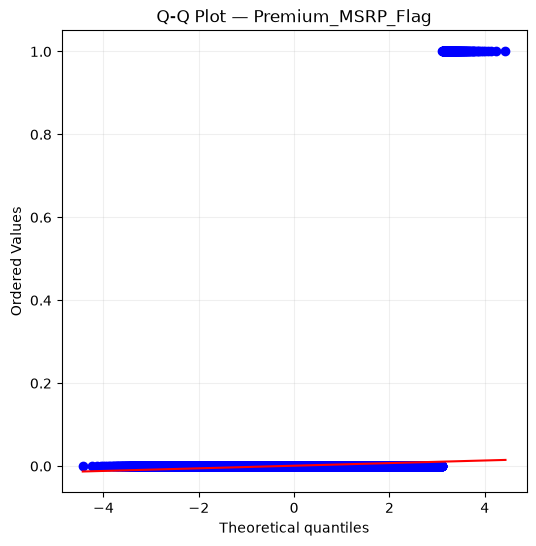

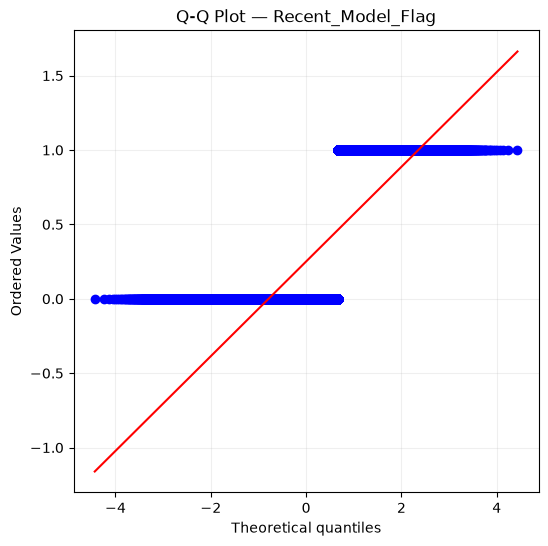

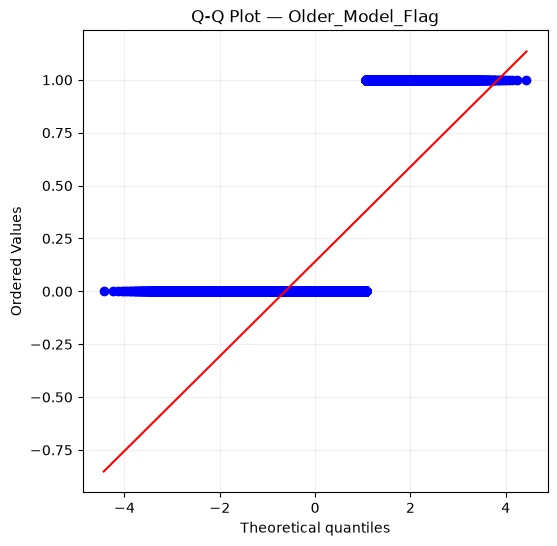

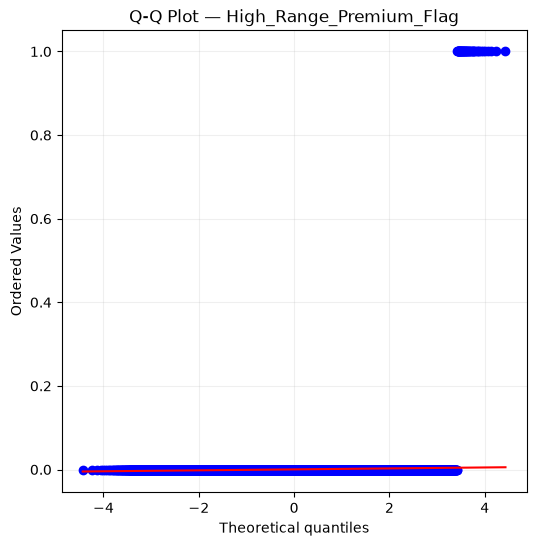

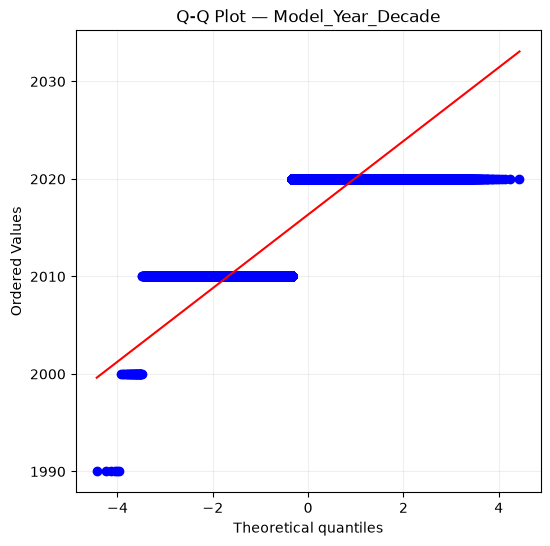

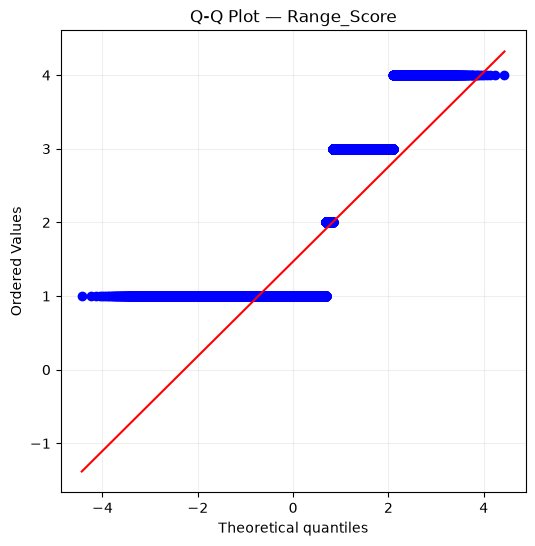

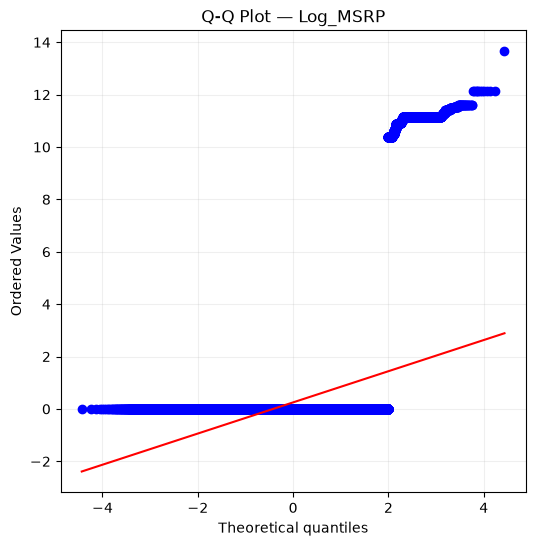

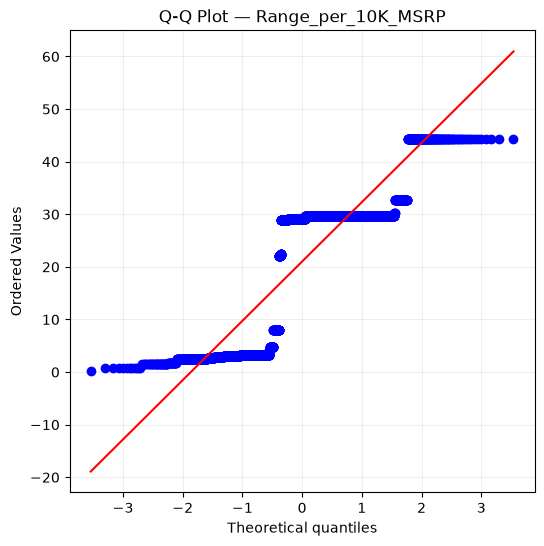

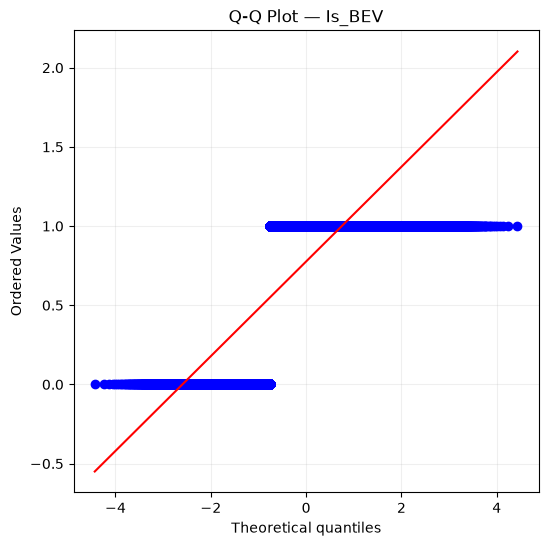

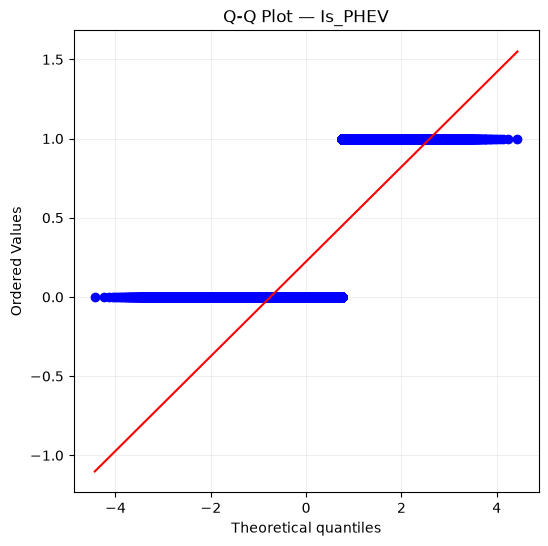

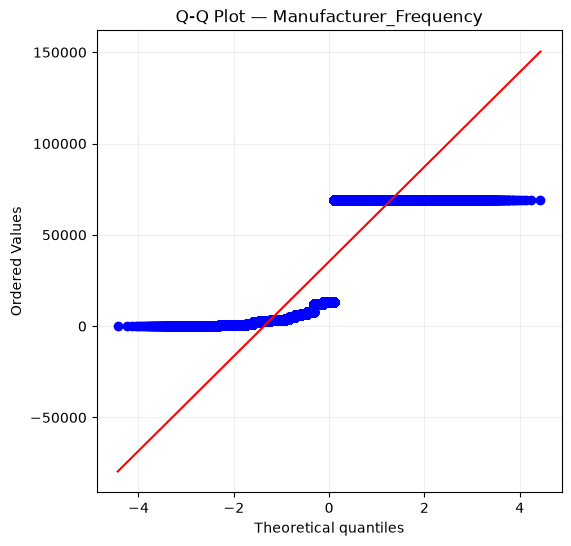

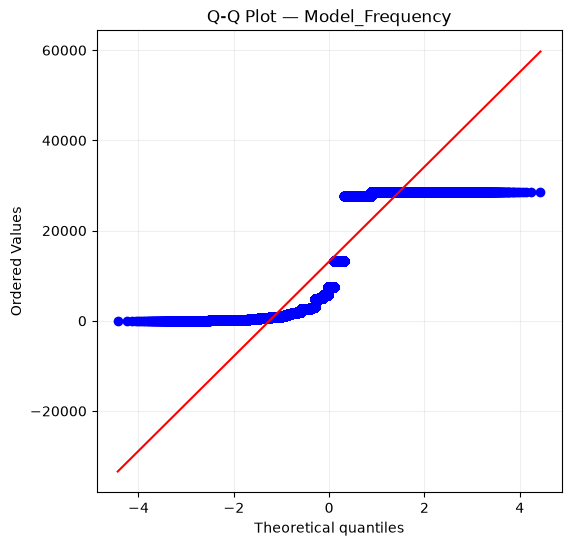

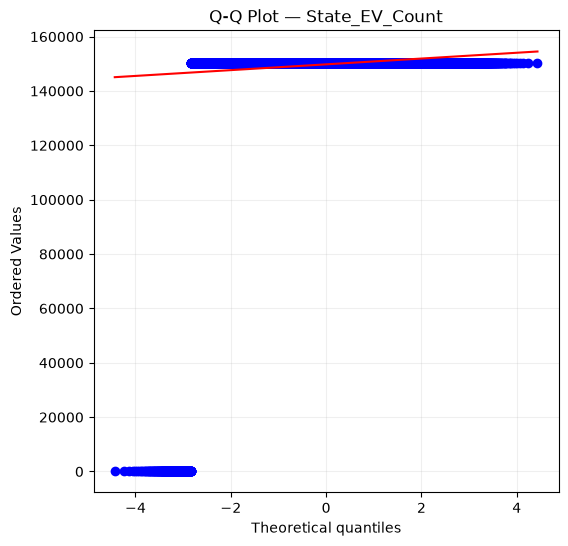

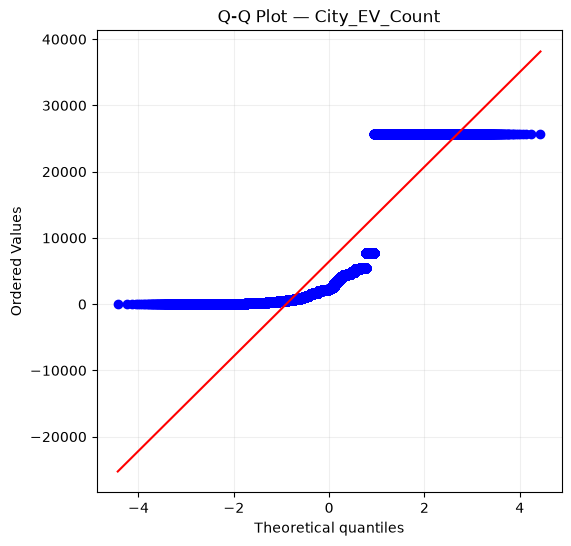

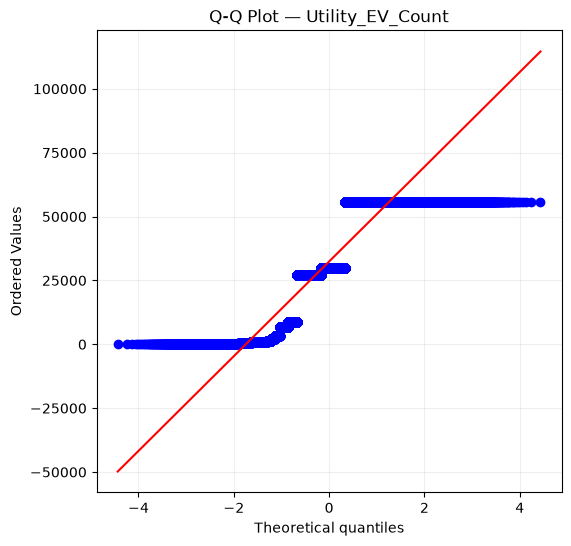

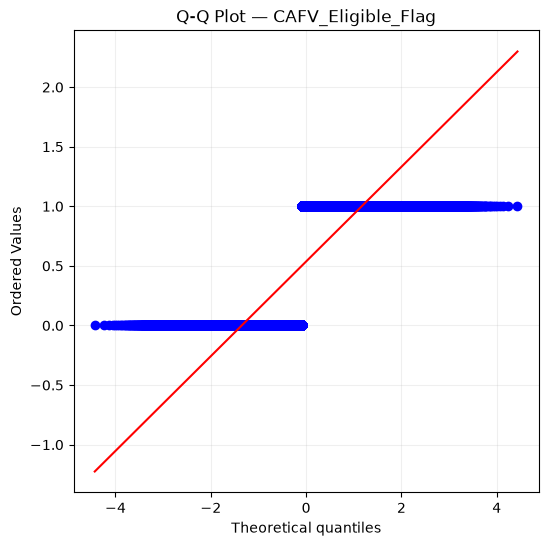

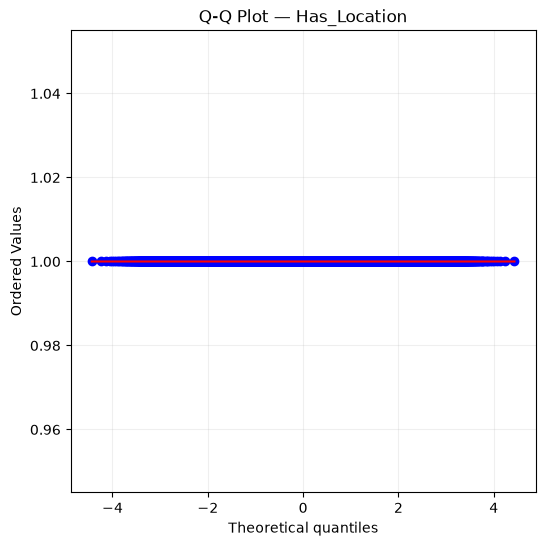

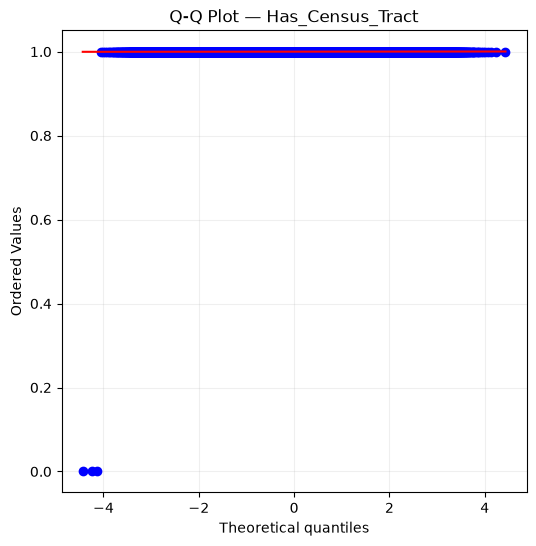

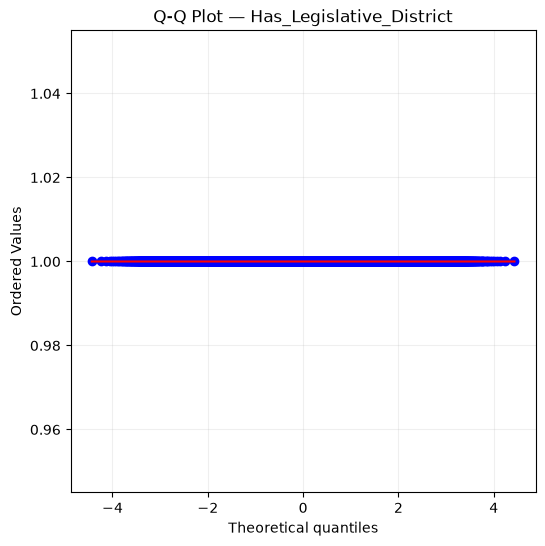

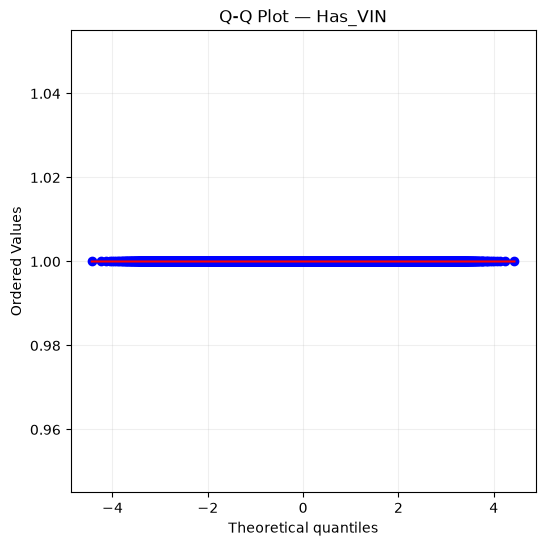

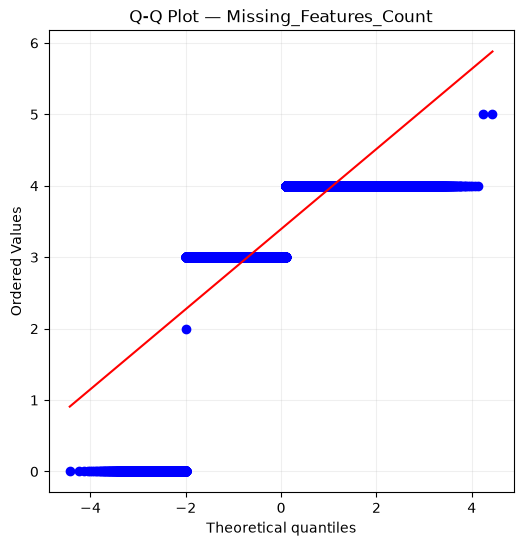

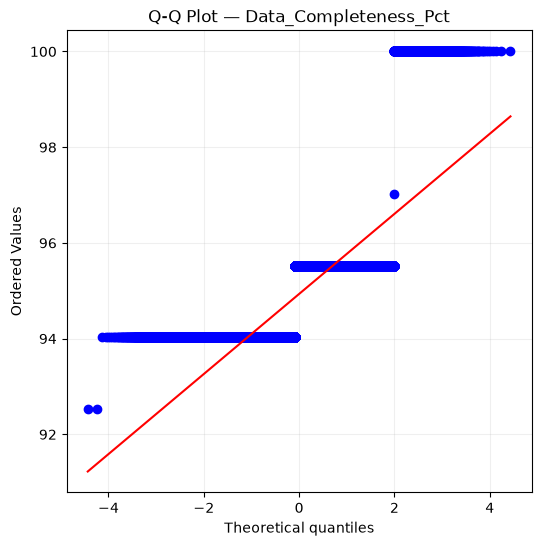

In [29]:
for col in numeric_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6, 6))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — {col}")
    plt.grid(alpha=0.2)
    plt.show()


# 27. Levene's Test

Tests equality of variances across groups.

\[
H_0: \sigma_1^2=\sigma_2^2=...=\sigma_k^2
\]

This is useful before interpreting group-comparison assumptions.


In [30]:
if numeric_cols:
    candidate_groups = [
        c for c in categorical_cols
        if 2 <= df[c].nunique(dropna=True) <= 10
    ]

    if candidate_groups:
        group_col = candidate_groups[0]
        target_col = numeric_cols[0]

        temp = df[[group_col, target_col]].dropna()
        grouped = [
            g[target_col].values
            for _, g in temp.groupby(group_col)
            if len(g) >= 2
        ]

        if len(grouped) >= 2:
            lev = levene(*grouped, center="median")
            print("Levene statistic:", lev.statistic)
            print("p-value:", lev.pvalue)


Levene statistic: 61.91928135024661
p-value: 3.601880504704404e-15


# 28. Mann–Whitney U Test

A non-parametric alternative for comparing two independent groups.

It does not require normally distributed outcomes.

H₀ concerns the distributions/ranks of the two groups.


In [31]:
if numeric_cols and two_group_cols:
    group_col = two_group_cols[0]
    target_col = numeric_cols[0]

    temp = df[[group_col, target_col]].dropna()
    levels = temp[group_col].value_counts().head(2).index.tolist()

    if len(levels) == 2:
        x = temp.loc[temp[group_col] == levels[0], target_col]
        y = temp.loc[temp[group_col] == levels[1], target_col]

        result = mannwhitneyu(x, y, alternative="two-sided")

        print("Groups:", levels)
        print("U statistic:", result.statistic)
        print("p-value:", result.pvalue)


Groups: ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']
U statistic: 1663698849.5
p-value: 0.0


# 29. Kruskal–Wallis Test

Non-parametric alternative to one-way ANOVA.

Used when comparing three or more independent groups without relying on normality.


In [32]:
if numeric_cols:
    candidate_groups = [
        c for c in categorical_cols
        if 3 <= df[c].nunique(dropna=True) <= 15
    ]

    if candidate_groups:
        group_col = candidate_groups[0]
        target_col = numeric_cols[0]

        temp = df[[group_col, target_col]].dropna()
        grouped = [
            g[target_col].values
            for _, g in temp.groupby(group_col)
            if len(g) >= 2
        ]

        if len(grouped) >= 3:
            result = kruskal(*grouped)
            print("Kruskal-Wallis H:", result.statistic)
            print("p-value:", result.pvalue)


Kruskal-Wallis H: 1404.2702389544356
p-value: 1.1657141295615026e-305


# 30. Bootstrap Confidence Interval

Bootstrap repeatedly samples the observed data with replacement.

For a statistic θ:

```text
Original sample
      ↓
Resample with replacement
      ↓
Calculate statistic
      ↓
Repeat many times
      ↓
Bootstrap distribution
      ↓
Confidence interval
```

This is useful when theoretical assumptions are questionable.


In [33]:
def bootstrap_mean_ci(series, n_boot=3000, confidence=0.95, random_state=42):
    x = pd.Series(series).dropna().to_numpy()
    rng = np.random.default_rng(random_state)

    boot_means = np.array([
        rng.choice(x, size=len(x), replace=True).mean()
        for _ in range(n_boot)
    ])

    lower = np.quantile(boot_means, (1-confidence)/2)
    upper = np.quantile(boot_means, 1-(1-confidence)/2)

    return boot_means, lower, upper

if numeric_cols:
    col = numeric_cols[0]
    boot, lower, upper = bootstrap_mean_ci(df[col])

    print("Column:", col)
    print("Bootstrap mean:", boot.mean())
    print("95% CI:", (lower, upper))


Column: Postal_Code
Bootstrap mean: 98168.1382639438
95% CI: (np.float64(98155.16170346028), np.float64(98180.39308690914))


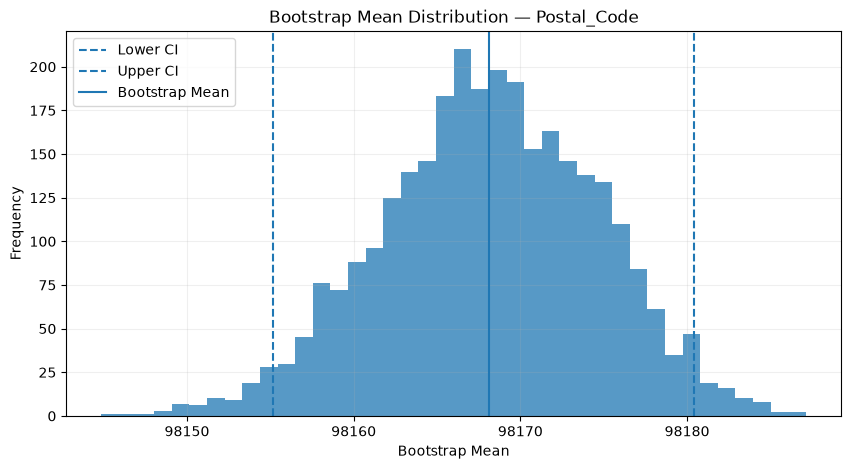

In [34]:
if numeric_cols:
    plt.figure(figsize=(10, 5))
    plt.hist(boot, bins=40, alpha=0.75)
    plt.axvline(lower, linestyle="--", label="Lower CI")
    plt.axvline(upper, linestyle="--", label="Upper CI")
    plt.axvline(boot.mean(), linestyle="-", label="Bootstrap Mean")
    plt.title(f"Bootstrap Mean Distribution — {numeric_cols[0]}")
    plt.xlabel("Bootstrap Mean")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# 31. Z-Score Analysis

The standardized score is:

\[
z = \frac{x-\mu}{\sigma}
\]

It expresses how many standard deviations an observation lies from the mean.


In [35]:
zscore_summary = {}

for col in numeric_cols:
    x = df[col]
    z = (x - x.mean()) / x.std(ddof=0)
    zscore_summary[col] = {
        "|z| > 2": int((z.abs() > 2).sum()),
        "|z| > 3": int((z.abs() > 3).sum()),
        "% |z| > 3": float((z.abs() > 3).mean() * 100)
    }

zscore_df = pd.DataFrame(zscore_summary).T
display(zscore_df.round(3))


,|z| > 2,|z| > 3,% |z| > 3
Postal_Code,278.0,237.0,0.157
Model_Year,7055.0,60.0,0.040
Electric_Range,7928.0,0.0,0.000
Base_MSRP,3455.0,3455.0,2.296
Vehicle_ID,11036.0,6251.0,4.154
Census_Tract,301.0,283.0,0.188
Legislative_District,0.0,0.0,0.000
Vehicle_Age,7055.0,60.0,0.040
Has_Electric_Range,0.0,0.0,0.000
Range_Percentile,0.0,0.0,0.000


# 32. Group-Level Statistical Summary

A professional statistical analysis should compare metrics across important business dimensions such as:
- Make
- Model
- State
- EV Type
- CAFV Eligibility

The code automatically uses columns that exist in the cleaned dataset.


In [36]:
preferred_group_cols = [
    "Make", "Model", "State", "EV_Type", "CAFV_Eligibility",
    "County", "City"
]

available_group_cols = [c for c in preferred_group_cols if c in df.columns]

for group_col in available_group_cols:
    for target_col in numeric_cols:
        summary = (
            df.groupby(group_col)[target_col]
            .agg(["count", "mean", "median", "std", "min", "max"])
            .sort_values("count", ascending=False)
            .head(15)
        )

        print(f"### {target_col} by {group_col}")
        display(summary.round(3))


### Postal_Code by Make


,count,mean,median,std,min,max
Make,,,,,,
TESLA,68981,98134.269,98107.0,2499.327,1731.0,99577.0
NISSAN,13496,98210.845,98133.0,1748.293,20002.0,99403.0
CHEVROLET,12026,98238.042,98229.0,2729.375,1730.0,99403.0
FORD,7614,98233.250,98248.0,2584.565,6443.0,99403.0
BMW,6439,98166.457,98115.0,1985.684,21113.0,99402.0
KIA,6198,98203.265,98188.0,2389.323,12401.0,99403.0
TOYOTA,5223,98135.944,98232.0,3969.115,6385.0,99403.0
VOLKSWAGEN,4074,98160.524,98133.0,2549.200,20603.0,99403.0
VOLVO,3536,98150.021,98115.0,1961.661,21042.0,99403.0


### Model_Year by Make


,count,mean,median,std,min,max
Make,,,,,,
TESLA,68983,2020.641,2021.0,2.353,2008,2023
NISSAN,13497,2016.776,2016.0,3.477,2011,2024
CHEVROLET,12026,2018.188,2018.0,3.304,1997,2023
FORD,7614,2018.901,2021.0,3.670,1998,2023
BMW,6439,2019.702,2021.0,3.120,2014,2024
KIA,6198,2021.022,2022.0,2.194,2015,2023
TOYOTA,5223,2018.551,2019.0,3.344,2002,2023
VOLKSWAGEN,4074,2020.891,2021.0,2.322,2015,2023
VOLVO,3536,2021.275,2022.0,1.890,2016,2024


### Electric_Range by Make


...

,count,mean,median,std,min,max
City,,,,,,
Seattle,25678,1.0,1.0,0.0,1,1
Bellevue,7691,1.0,1.0,0.0,1,1
Redmond,5502,1.0,1.0,0.0,1,1
Vancouver,5310,1.0,1.0,0.0,1,1
Bothell,4861,1.0,1.0,0.0,1,1
Kirkland,4622,1.0,1.0,0.0,1,1
Sammamish,4436,1.0,1.0,0.0,1,1
Renton,4043,1.0,1.0,0.0,1,1
Olympia,3634,1.0,1.0,0.0,1,1


### Missing_Features_Count by City


,count,mean,median,std,min,max
City,,,,,,
Seattle,25678,3.379,3.0,0.709,0,5
Bellevue,7691,3.452,4.0,0.746,0,4
Redmond,5502,3.473,4.0,0.706,0,4
Vancouver,5310,3.359,3.0,0.692,0,4
Bothell,4861,3.534,4.0,0.646,0,4
Kirkland,4622,3.419,3.0,0.750,0,4
Sammamish,4436,3.473,4.0,0.732,0,4
Renton,4043,3.447,4.0,0.701,0,4
Olympia,3634,3.339,3.0,0.685,0,4


### Data_Completeness_Pct by City


,count,mean,median,std,min,max
City,,,,,,
Seattle,25678,94.957,95.522,1.059,92.537,100.0
Bellevue,7691,94.848,94.030,1.114,94.030,100.0
Redmond,5502,94.816,94.030,1.053,94.030,100.0
Vancouver,5310,94.986,95.522,1.033,94.030,100.0
Bothell,4861,94.726,94.030,0.964,94.030,100.0
Kirkland,4622,94.897,95.522,1.120,94.030,100.0
Sammamish,4436,94.816,94.030,1.093,94.030,100.0
Renton,4043,94.855,94.030,1.046,94.030,100.0
Olympia,3634,95.016,95.522,1.022,94.030,100.0


# 33. Confidence Interval by Group

Group means are more informative when accompanied by uncertainty estimates.


In [37]:
def group_mean_ci(data, group_col, target_col, confidence=0.95):
    rows = []

    for group, x in data.groupby(group_col)[target_col]:
        x = x.dropna()
        n = len(x)

        if n < 2:
            continue

        mean = x.mean()
        se = stats.sem(x)
        margin = stats.t.ppf((1 + confidence) / 2, n - 1) * se

        rows.append({
            group_col: group,
            "N": n,
            "Mean": mean,
            "CI_Lower": mean - margin,
            "CI_Upper": mean + margin
        })

    return pd.DataFrame(rows)

if available_group_cols and numeric_cols:
    group_ci = group_mean_ci(df, available_group_cols[0], numeric_cols[0])
    display(group_ci.sort_values("N", ascending=False).head(20).round(3))


,Make,N,Mean,CI_Lower,CI_Upper
31,TESLA,68981,98134.269,98115.618,98152.921
25,NISSAN,13496,98210.845,98181.347,98240.344
6,CHEVROLET,12026,98238.042,98189.256,98286.828
10,FORD,7614,98233.250,98175.188,98291.313
4,BMW,6439,98166.457,98117.947,98214.967
16,KIA,6198,98203.265,98143.770,98262.760
33,TOYOTA,5223,98135.944,98028.277,98243.611
34,VOLKSWAGEN,4074,98160.524,98082.222,98238.825
35,VOLVO,3536,98150.021,98085.342,98214.700
15,JEEP,3292,98270.308,98197.164,98343.453


# 34. Statistical Significance vs Business Significance

A large dataset can produce very small p-values even for tiny differences.

Always report:

```text
Difference
+
Effect Size
+
Confidence Interval
+
p-value
+
Business Context
```

Do not use the p-value alone to claim that one group is "better".


# 35. Multiple Testing

When many statistical tests are performed, the chance of false positives increases.

A common correction is **Benjamini–Hochberg False Discovery Rate (FDR)**.

The adjusted p-value controls the expected proportion of false discoveries among rejected hypotheses.


In [38]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    result = np.empty(n)
    result[order] = adjusted
    return result

if not pearson_results_df.empty:
    pearson_results_df["p_adj_fdr"] = benjamini_hochberg(
        pearson_results_df["p_value"].values
    )
    pearson_results_df["FDR_significant"] = (
        pearson_results_df["p_adj_fdr"] < 0.05
    )

display(pearson_results_df.sort_values("p_adj_fdr").round(5))


,Variable_1,Variable_2,Pearson_r,p_value,Significant_0.05,p_adj_fdr,FDR_significant
16,Postal_Code,State_Share_Pct,0.76309,0.00000,True,0.00000,True
73,Model_Year,Manufacturer_Frequency,0.15593,0.00000,True,0.00000,True
72,Model_Year,Is_PHEV,-0.19026,0.00000,True,0.00000,True
71,Model_Year,Is_BEV,0.19026,0.00000,True,0.00000,True
70,Model_Year,Range_per_10K_MSRP,-0.78742,0.00000,True,0.00000,True
...,...,...,...,...,...,...,...
14,Postal_Code,MSRP_per_Range,0.00016,0.96387,False,0.96822,False
252,Legislative_District,Premium_MSRP_Flag,0.00011,0.96499,False,0.96825,False
880,City_EV_Count,Data_Completeness_Pct,0.00008,0.97451,False,0.97561,False
879,City_EV_Count,Missing_Features_Count,-0.00008,0.97451,False,0.97561,False


# 36. Statistical Summary Dashboard

This section creates a compact statistical scorecard for the dataset.


In [39]:
statistical_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Numeric Columns",
        "Categorical Columns",
        "Missing Cells",
        "Duplicate Rows"
    ],
    "Value": [
        len(df),
        df.shape[1],
        len(numeric_cols),
        len(categorical_cols),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum())
    ]
})

display(statistical_summary)


,Metric,Value
0,Rows,150482
1,Columns,68
2,Numeric Columns,46
3,Categorical Columns,22
4,Missing Cells,510785
5,Duplicate Rows,0


# 37. Automated Statistical Interpretation

The rules below identify broad patterns that should be investigated further. They are **descriptive flags**, not automatic business conclusions.


In [40]:
interpretation_rows = []

for col in numeric_cols:
    s = df[col].dropna()
    skew = s.skew()
    cv_value = (s.std() / s.mean() * 100) if s.mean() != 0 else np.nan

    if abs(skew) < 0.5:
        skew_label = "Approximately symmetric"
    elif skew >= 0.5:
        skew_label = "Right-skewed"
    else:
        skew_label = "Left-skewed"

    interpretation_rows.append({
        "Column": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Std": s.std(),
        "CV_%": cv_value,
        "Skewness": skew,
        "Distribution_Flag": skew_label
    })

interpretation_df = pd.DataFrame(interpretation_rows)
display(interpretation_df.round(3))


,Column,Mean,Median,Std,CV_%,Skewness,Distribution_Flag
0,Postal_Code,9.816834e+04,9.812200e+04,2.473612e+03,2.520000e+00,-29.862,Left-skewed
1,Model_Year,2.020005e+03,2.021000e+03,3.015000e+00,1.490000e-01,-0.978,Left-skewed
2,Electric_Range,6.787800e+01,1.800000e+01,9.623000e+01,1.417690e+02,1.219,Right-skewed
3,Base_MSRP,1.312645e+03,0.000000e+00,9.231310e+03,7.032600e+02,11.931,Right-skewed
4,Vehicle_ID,2.111122e+08,2.150306e+08,8.196388e+07,3.882500e+01,0.897,Right-skewed
5,Census_Tract,5.297195e+10,5.303303e+10,1.638841e+09,3.094000e+00,-25.965,Left-skewed
6,Legislative_District,2.935200e+01,3.300000e+01,1.480900e+01,5.045300e+01,-0.486,Approximately symmetric
7,Vehicle_Age,5.995000e+00,5.000000e+00,3.015000e+00,5.029900e+01,0.978,Right-skewed
8,Has_Electric_Range,5.370000e-01,1.000000e+00,4.990000e-01,9.288600e+01,-0.148,Approximately symmetric
9,Range_Percentile,5.000000e+01,4.965800e+01,2.739300e+01,5.478600e+01,0.324,Approximately symmetric


# 38. Final Statistical Findings Template

Use this section to convert numerical output into portfolio-quality conclusions.

### Descriptive findings
- Identify the variables with the largest spread.
- Compare mean and median.
- Identify strongly skewed variables.
- Review extreme values using box plots.

### Inferential findings
- Report the test used.
- Report statistic and p-value.
- Report confidence interval where appropriate.
- Report effect size where appropriate.

### Business interpretation
Avoid:

> "p < 0.05, therefore this is important."

Prefer:

> "The analysis found evidence of a difference between groups. The estimated effect was X, with a 95% confidence interval of [L, U]. The practical importance should be assessed against the business threshold."

### Limitations
- Observational data does not establish causation.
- Source definitions and measurement practices matter.
- Statistical significance depends strongly on sample size.
- Projection/estimated records must not be interpreted as historical observations.


# 39. Export Statistical Outputs

Save reusable statistical tables for the reporting/dashboard stage.


In [41]:
from pathlib import Path

output_dir = Path("../outputs/tables")
output_dir.mkdir(parents=True, exist_ok=True)

desc.to_csv(output_dir / "descriptive_statistics.csv")
percentiles.to_csv(output_dir / "percentiles.csv")
outlier_df.to_csv(output_dir / "outlier_summary.csv", index=False)
shape_stats.to_csv(output_dir / "distribution_shape_statistics.csv")
ci_df.to_csv(output_dir / "confidence_intervals.csv", index=False)
interpretation_df.to_csv(output_dir / "statistical_interpretation.csv", index=False)

if not pearson_results_df.empty:
    pearson_results_df.to_csv(output_dir / "pearson_tests.csv", index=False)

if not spearman_results_df.empty:
    spearman_results_df.to_csv(output_dir / "spearman_tests.csv", index=False)

print(f"✅ Statistical outputs saved to: {output_dir}")


✅ Statistical outputs saved to: ..\outputs\tables


# 40. Final Checklist

## Descriptive Statistics
- [x] Mean
- [x] Median
- [x] Mode
- [x] Variance
- [x] Standard deviation
- [x] Range
- [x] Quartiles
- [x] Percentiles
- [x] IQR
- [x] Skewness
- [x] Kurtosis
- [x] Coefficient of variation

## Visualization
- [x] Histograms
- [x] KDE
- [x] Box plots
- [x] Correlation heatmap
- [x] Scatter matrix
- [x] Category charts
- [x] Q-Q plots
- [x] Group comparison charts
- [x] Bootstrap distribution

## Inferential Statistics
- [x] Confidence intervals
- [x] One-sample t-test
- [x] Welch's t-test
- [x] ANOVA
- [x] Chi-square
- [x] Pearson correlation test
- [x] Spearman correlation test
- [x] Mann–Whitney U
- [x] Kruskal–Wallis
- [x] Levene's test
- [x] Shapiro-Wilk
- [x] Bootstrap CI

## Advanced Interpretation
- [x] Effect size
- [x] Cramér's V
- [x] Cohen's d
- [x] FDR correction
- [x] Business significance
- [x] Statistical limitations

---

# 🏁 Conclusion

This notebook provides the **statistical foundation** for the EV Intelligence Platform.

```text
DESCRIPTIVE
    ↓
DISTRIBUTIONS
    ↓
RELATIONSHIPS
    ↓
INFERENCE
    ↓
HYPOTHESIS TESTING
    ↓
EFFECT SIZE
    ↓
CONFIDENCE
    ↓
VISUAL EVIDENCE
    ↓
BUSINESS INTERPRETATION
```

**Next logical stage:** use these validated statistical findings as inputs for advanced feature engineering and, only where justified by the real data, machine-learning analysis.
